# Visualisasi Tujuan 2 — Pembangunan Sistem QA Berbasis Instruction-Tuned SLM (Bab 4.2)

Notebook ini menghasilkan **seluruh grafik** untuk Tujuan 2, mencakup tiga tahap pipeline:

| Bagian | Cakupan | Sumber |
|---|---|---|
| 1-2 | Persiapan data: korpus, ekstraksi, pembersihan, strukturisasi, chunking | `tujuan2/[1] data preparation/01-04` |
| 3 | Pembentukan & penyaringan dataset QA | `tujuan2/[1] data preparation/05-07` |
| 4 | Modelling: konfigurasi, dinamika training, perilaku generasi | `tujuan2/[2] modelling/08-10` |
| 5-6 | Evaluasi otomatis & evaluasi manusia | `tujuan2/[3] evaluation/11-12` |

**Prinsip penyajian:** penelitian tidak hanya melaporkan hasil akhir yang baik, tetapi juga seluruh proses iterasi — berapa banyak data yang terbuang di tiap tahap, mengapa dibuang, dan bagaimana karakteristik data berubah. Karena itu grafik funnel penyusutan data, distribusi kualitas, dan alasan penyisihan ikut divisualisasikan.

## Sumber data

**(a) Tertanam langsung di notebook ini** — statistik hasil eksekusi notebook 02 dan 04 yang hanya dicetak ke output sel (tidak disimpan sebagai berkas), disalin verbatim ke dalam sel `DATA MENTAH` di bawah agar Bagian 1-2 selalu bisa dijalankan ulang tanpa berkas eksternal.

**(b) Berkas yang perlu diunduh** dari HF dataset repo `Makaareeem/publikasi-rag-finetuning-dataset` dan diletakkan pada direktori yang sama dengan notebook ini:

- `train.csv`, `val.csv`, `test.csv`, `dataset_manifest.json` — Bagian 3
- `training_config.json` — Bagian 4
- `eval_gemma2_predictions.csv`, `eval_llama3.2_predictions.csv` — Bagian 4
- `summary_metrics.csv`, `gemma2_base_scored.csv`, `gemma2_finetuned_scored.csv`, `llama3.2_base_scored.csv`, `llama3.2_finetuned_scored.csv` — Bagian 5
- `human_eval_evaluator1.csv` … `human_eval_evaluator5.csv`, `human_eval_key.csv` — Bagian 6 (hanya bisa dibuat setelah kelima evaluator selesai mengisi)

Setiap grafik yang berkasnya belum tersedia akan dilewati otomatis dengan pesan, bukan error.

## Setup dan konfigurasi global

In [105]:
%matplotlib inline
import os
import io
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy import stats

plt.rcParams.update({"font.family": "serif", "font.size": 10, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.axisbelow": True, "figure.dpi": 150})

# Palet konsisten dengan notebook visualisasi Tujuan 1
C_RAW, C_CLEAN = "#b3b3b3", "#2c6fbb"
C_BASE, C_FT = "#b3b3b3", "#2c6fbb"
C_GEMMA, C_LLAMA = "#e08a1e", "#3a7d44"
C_DROP, C_KEEP = "#c0392b", "#3a7d44"
C_ACCENT, C_MUTED = "#e08a1e", "#7f8c8d"

MODEL_KEYS = ["gemma2", "llama3.2"]
CONDITIONS = ["base", "finetuned"]
METRICS = ["em", "f1", "rouge_l", "indobertscore"]
METRIC_LABELS = {"em": "Exact Match", "f1": "Token F1", "rouge_l": "ROUGE-L", "indobertscore": "IndoBERTScore"}
MODEL_LABELS = {"gemma2": "Gemma-2-2B", "llama3.2": "Llama-3.2-3B"}

def ada(*berkas):
    """True bila semua berkas tersedia di direktori notebook."""
    return all(os.path.exists(f) for f in berkas)

def lewati(pesan):
    print(f"[DILEWATI] {pesan}")

def anotasi_funnel(ax, nilai, keterangan):
    """Tulis keterangan transisi di sela antar-batang, di atas batang tertinggi di sekitarnya."""
    puncak = max(nilai)
    for i, (teks, warna) in enumerate(keterangan):
        y = max(nilai[i], nilai[i + 1]) + puncak * .06
        ax.text(i + .5, y, teks, ha="center", va="bottom", fontsize=8.5, color=warna,
                bbox=dict(boxstyle="round,pad=.28", facecolor="white", edgecolor=warna,
                          alpha=.9, linewidth=.5))

## DATA MENTAH — statistik hasil eksekusi notebook 02 & 04
Angka di bawah disalin **verbatim** dari output sel notebook `02-cleaning-extract.ipynb` dan `04-chunking-and-splitting.ipynb`. Kedua notebook tersebut hanya mencetak statistik ke layar dan menyimpan hasil ke `/kaggle/working/` (tidak di-push ke HF), sehingga angkanya ditanam di sini agar Bagian 1-2 reproducible.

In [106]:
# --- Statistik pembersihan per dokumen (sumber: 02-cleaning-extract.ipynb, sel ringkasan) ---
CLEANING_CSV = """nama_file,halaman,chars_raw,chars_clean,reduction_pct,max_chars_page,min_chars_page,picture_removed,watermark_removed,empty_pages,low_char_pages
analisis-petty-corruption-hasil-spak-2020---2024,194,474091,450612,4.95,11070,0,175,54,17,5
indeks-pembangunan-manusia-2022,180,368491,317355,13.88,7885,0,240,146,17,5
indeks-pembangunan-manusia-2023,196,388742,339296,12.72,6554,0,223,155,21,9
indeks-pembangunan-manusia-2024,224,516932,460572,10.90,6761,0,239,140,19,1
indeks-perilaku-anti-korupsi-2023,184,273314,247489,9.45,3339,0,97,93,1,25
indeks-perilaku-anti-korupsi-2024,226,337414,310390,8.01,5241,0,100,102,5,29
indikator-kesejahteraan-rakyat-2023,230,631540,598289,5.27,6791,0,123,117,26,2
indikator-kesejahteraan-rakyat-2024,224,637873,600460,5.87,11367,0,134,120,24,10
indikator-kesejahteraan-rakyat-2025,140,349425,335189,4.07,6220,0,13,42,21,7
indikator-sdgs-kesejahteraan-rakyat-2024,262,535885,487594,9.01,10796,0,65,280,1,10
indikator-sdgs-kesejahteraan-rakyat-2025,266,466006,433408,7.00,7182,1,76,162,0,21
infografis-statistik-kesejahteraan-rakyat-2025,68,30394,24071,20.80,1503,1,38,15,0,24
kesejahteraan-anak-indonesia--analisis-deprivasi-hak-anak-multidimensi-2022,98,214355,204823,4.45,6649,0,15,40,2,9
kesejahteraan-anak-indonesia--analisis-kemiskinan-anak-moneter-2022,105,219703,204495,6.92,5740,0,17,72,4,4
laporan-indeks-khusus-penanganan-stunting--ikps--2022-2023,115,172834,158644,8.21,6182,0,35,91,11,15
laporan-indeks-khusus-penanganan-stunting-2021-2022,118,196944,185065,6.03,3999,1,14,68,0,17
laporan-indeks-khusus-penanganan-stunting-kabupaten-kota-2021-2022,714,1620429,1299983,19.78,4737,1,8,53,0,96
profil-anak-usia-dini-2023,236,466165,396734,14.89,12012,0,72,148,26,20
profil-anak-usia-dini-2024,244,440893,382479,13.25,8043,0,61,167,22,17
profil-anak-usia-dini-2025,220,385730,342124,11.30,4518,0,60,119,19,22
profil-kesehatan-ibu-dan-anak-2024,742,1344335,1170988,12.89,7225,0,74,664,10,23
profil-statistik-kesehatan-2023,484,882013,734881,16.68,3816,0,446,404,3,9
profil-statistik-kesehatan-2025,516,935912,829313,11.39,5883,0,65,483,3,22
statistik-indonesia-2023,830,2189549,1880088,14.13,5597,0,1943,609,28,6
statistik-indonesia-2024,852,2545219,2188414,14.02,15701,0,288,756,31,4
statistik-indonesia-2025,898,2708689,2317711,14.43,9452,0,279,525,28,2
statistik-kesehatan-2022,264,443473,394482,11.05,4777,1,53,222,0,20
statistik-kesejahteraan-rakyat-2023,420,1371065,1243301,9.32,12031,0,665,454,24,9
statistik-kesejahteraan-rakyat-2024,562,2075249,1880667,9.38,7866,0,957,571,25,7
statistik-kesejahteraan-rakyat-2025,584,2217332,1869069,15.71,8755,0,330,514,25,9
statistik-kriminal-2023,246,352100,306631,12.91,3650,0,163,190,21,13
statistik-kriminal-2024-2025,232,407192,370489,9.01,4326,0,36,126,8,21
statistik-kriminal-2024,244,378881,337430,10.94,4237,0,89,141,9,31
statistik-pemuda-indonesia-2023,466,1012197,867541,14.29,9523,5,93,416,0,40
statistik-pemuda-indonesia-2024,412,827211,719972,12.96,7520,0,76,344,1,40
statistik-pemuda-indonesia-2025,380,769967,639061,17.00,4760,0,309,161,2,39
statistik-pendidikan-2023,278,467946,417385,10.80,4507,0,69,194,17,16
statistik-pendidikan-2024,252,419839,362725,13.60,8181,0,66,192,19,16
statistik-pendidikan-2025,251,479652,424445,11.51,4856,0,49,155,7,25
statistik-penduduk-lanjut-usia-2023,326,610480,502551,17.68,3918,0,84,220,20,16
statistik-penduduk-lanjut-usia-2024,316,709862,560544,21.03,4277,0,285,223,15,14
statistik-penduduk-lanjut-usia-2025,286,581429,473888,18.50,4319,0,53,164,19,17
statistik-penunjang-pendidikan-2024,200,420178,366006,12.89,10325,0,36,127,14,21
statistik-politik-2023,144,217316,194801,10.36,7660,0,54,70,17,6
statistik-politik-2024,294,552677,438561,20.65,6084,0,50,214,18,13
statistik-politik-2025,208,388229,326535,15.89,3158,0,26,37,16,6
statistik-sosial-budaya-2024,228,429672,376777,12.31,5355,0,44,142,14,19
"""

# --- Section -> chunk per dokumen (sumber: 04-chunking-and-splitting.ipynb) ---
CHUNKING_CSV = """nama_file,n_sections,n_chunks,n_toc_chunks
analisis-petty-corruption-hasil-spak-2020---2024,115,372,9
indeks-pembangunan-manusia-2022,230,262,4
indeks-pembangunan-manusia-2023,125,266,20
indeks-pembangunan-manusia-2024,186,336,12
indeks-perilaku-anti-korupsi-2023,94,145,10
indeks-perilaku-anti-korupsi-2024,117,218,9
indikator-kesejahteraan-rakyat-2023,226,421,11
indikator-kesejahteraan-rakyat-2024,175,399,7
indikator-kesejahteraan-rakyat-2025,139,263,6
indikator-sdgs-kesejahteraan-rakyat-2024,162,372,2
indikator-sdgs-kesejahteraan-rakyat-2025,209,322,2
infografis-statistik-kesejahteraan-rakyat-2025,68,43,0
kesejahteraan-anak-indonesia--analisis-deprivasi-hak-anak-multidimensi-2022,87,158,2
kesejahteraan-anak-indonesia--analisis-kemiskinan-anak-moneter-2022,43,137,4
laporan-indeks-khusus-penanganan-stunting--ikps--2022-2023,163,119,0
laporan-indeks-khusus-penanganan-stunting-2021-2022,172,128,0
laporan-indeks-khusus-penanganan-stunting-kabupaten-kota-2021-2022,1977,615,0
profil-anak-usia-dini-2023,94,276,25
profil-anak-usia-dini-2024,97,270,1
profil-anak-usia-dini-2025,104,248,0
profil-kesehatan-ibu-dan-anak-2024,96,817,0
profil-statistik-kesehatan-2023,337,564,2
profil-statistik-kesehatan-2025,527,608,2
statistik-indonesia-2023,824,1466,1
statistik-indonesia-2024,992,1665,1
statistik-indonesia-2025,966,1801,1
statistik-kesehatan-2022,148,268,17
statistik-kesejahteraan-rakyat-2023,287,1216,0
statistik-kesejahteraan-rakyat-2024,300,1705,0
statistik-kesejahteraan-rakyat-2025,226,1602,0
statistik-kriminal-2023,105,218,1
statistik-kriminal-2024-2025,187,196,5
statistik-kriminal-2024,157,146,1
statistik-pemuda-indonesia-2023,155,659,3
statistik-pemuda-indonesia-2024,212,562,4
statistik-pemuda-indonesia-2025,205,541,4
statistik-pendidikan-2023,57,273,2
statistik-pendidikan-2024,109,260,2
statistik-pendidikan-2025,64,292,15
statistik-penduduk-lanjut-usia-2023,124,369,3
statistik-penduduk-lanjut-usia-2024,166,462,2
statistik-penduduk-lanjut-usia-2025,168,403,2
statistik-penunjang-pendidikan-2024,94,279,10
statistik-politik-2023,37,127,0
statistik-politik-2024,195,264,2
statistik-politik-2025,135,181,2
statistik-sosial-budaya-2024,115,289,0
"""

# --- Agregat chunking (sumber: 04-chunking-and-splitting.ipynb) ---
CHUNK_TYPE_DIST = {"text_only": 21295, "figure_rich": 643, "table_rich": 307,
                   "mixed_rich": 152, "toc_table": 121, "toc_figure": 85}
EXCLUSION_DIST = {"garbage_chunk": 2647, "reference": 1399, "front_matter": 228,
                  "front_matter_content": 64, "ocr_broken": 8, "reference_content": 1}
PROVENANCE_FALLBACK = 311
TOTAL_CHUNKS = 22603

# Kandidat tipe QA per chunk_type (sumber: QA_CANDIDATES di notebook 04)
QA_CANDIDATES = {
    "mixed_rich": ["statistical", "comparative", "interpretative"],
    "table_rich": ["statistical", "comparative"],
    "figure_rich": ["interpretative", "comparative", "trend"],
    "text_only": ["definition", "factual", "summary"],
    "toc_table": [], "toc_figure": [],
}

df_clean = pd.read_csv(io.StringIO(CLEANING_CSV))
df_chunk = pd.read_csv(io.StringIO(CHUNKING_CSV))

def tahun_publikasi(nama):
    """Tahun terbit = tahun 4-digit terakhir pada nama berkas."""
    tahun = re.findall(r"(?:19|20)\d{2}", nama)
    return int(tahun[-1]) if tahun else np.nan

def seri_publikasi(nama):
    """Nama seri = slug tanpa penanda tahun di belakang."""
    return re.sub(r"[-]+((?:19|20)\d{2})(-+((?:19|20)\d{2}))*$", "", nama).strip("-")

def label_pendek(nama, n=42):
    return nama if len(nama) <= n else nama[:n - 1] + "…"

for d in (df_clean, df_chunk):
    d["tahun"] = d["nama_file"].map(tahun_publikasi)
    d["seri"] = d["nama_file"].map(seri_publikasi)

df_clean["reduction_pct"] = df_clean["reduction_pct"].astype(float)
df_clean["chars_removed"] = df_clean["chars_raw"] - df_clean["chars_clean"]
df_clean["chars_per_page"] = df_clean["chars_clean"] / df_clean["halaman"]
df_clean["problem_pages"] = df_clean["empty_pages"] + df_clean["low_char_pages"]
df_clean["problem_page_pct"] = 100 * df_clean["problem_pages"] / df_clean["halaman"]

df_korpus = df_clean.merge(df_chunk[["nama_file", "n_sections", "n_chunks", "n_toc_chunks"]], on="nama_file")
df_korpus["chunk_per_section"] = df_korpus["n_chunks"] / df_korpus["n_sections"]

print(f"Dokumen           : {len(df_clean)}")
print(f"Total halaman     : {df_clean['halaman'].sum():,}")
print(f"Karakter mentah   : {df_clean['chars_raw'].sum():,}")
print(f"Karakter bersih   : {df_clean['chars_clean'].sum():,}")
print(f"Reduksi korpus    : {100 * df_clean['chars_removed'].sum() / df_clean['chars_raw'].sum():.2f}%")
print(f"Total section     : {df_chunk['n_sections'].sum():,}")
print(f"Total chunk RAG   : {TOTAL_CHUNKS:,}")

Dokumen           : 47
Total halaman     : 15,159
Karakter mentah   : 34,464,824
Karakter bersih   : 29,973,328
Reduksi korpus    : 13.03%
Total section     : 11,571
Total chunk RAG   : 22,603


---
# Bagian 1 — Korpus, Ekstraksi, dan Pembersihan Teks
Sumber: `01-extract-pdf-pymupdfllm-ocr.ipynb` dan `02-cleaning-extract.ipynb`. Korpus terdiri atas 47 publikasi resmi BPS yang diekstraksi dengan PyMuPDF4LLM + OCR, lalu dibersihkan melalui enam aturan berurutan: normalisasi Unicode (NFKC), perbaikan pemenggalan kata, penghapusan tag `<br>`, penghapusan marker teks gambar, penghapusan watermark URL BPS, dan normalisasi spasi.

### Gambar 1 — Komposisi korpus menurut tahun terbit dan seri publikasi

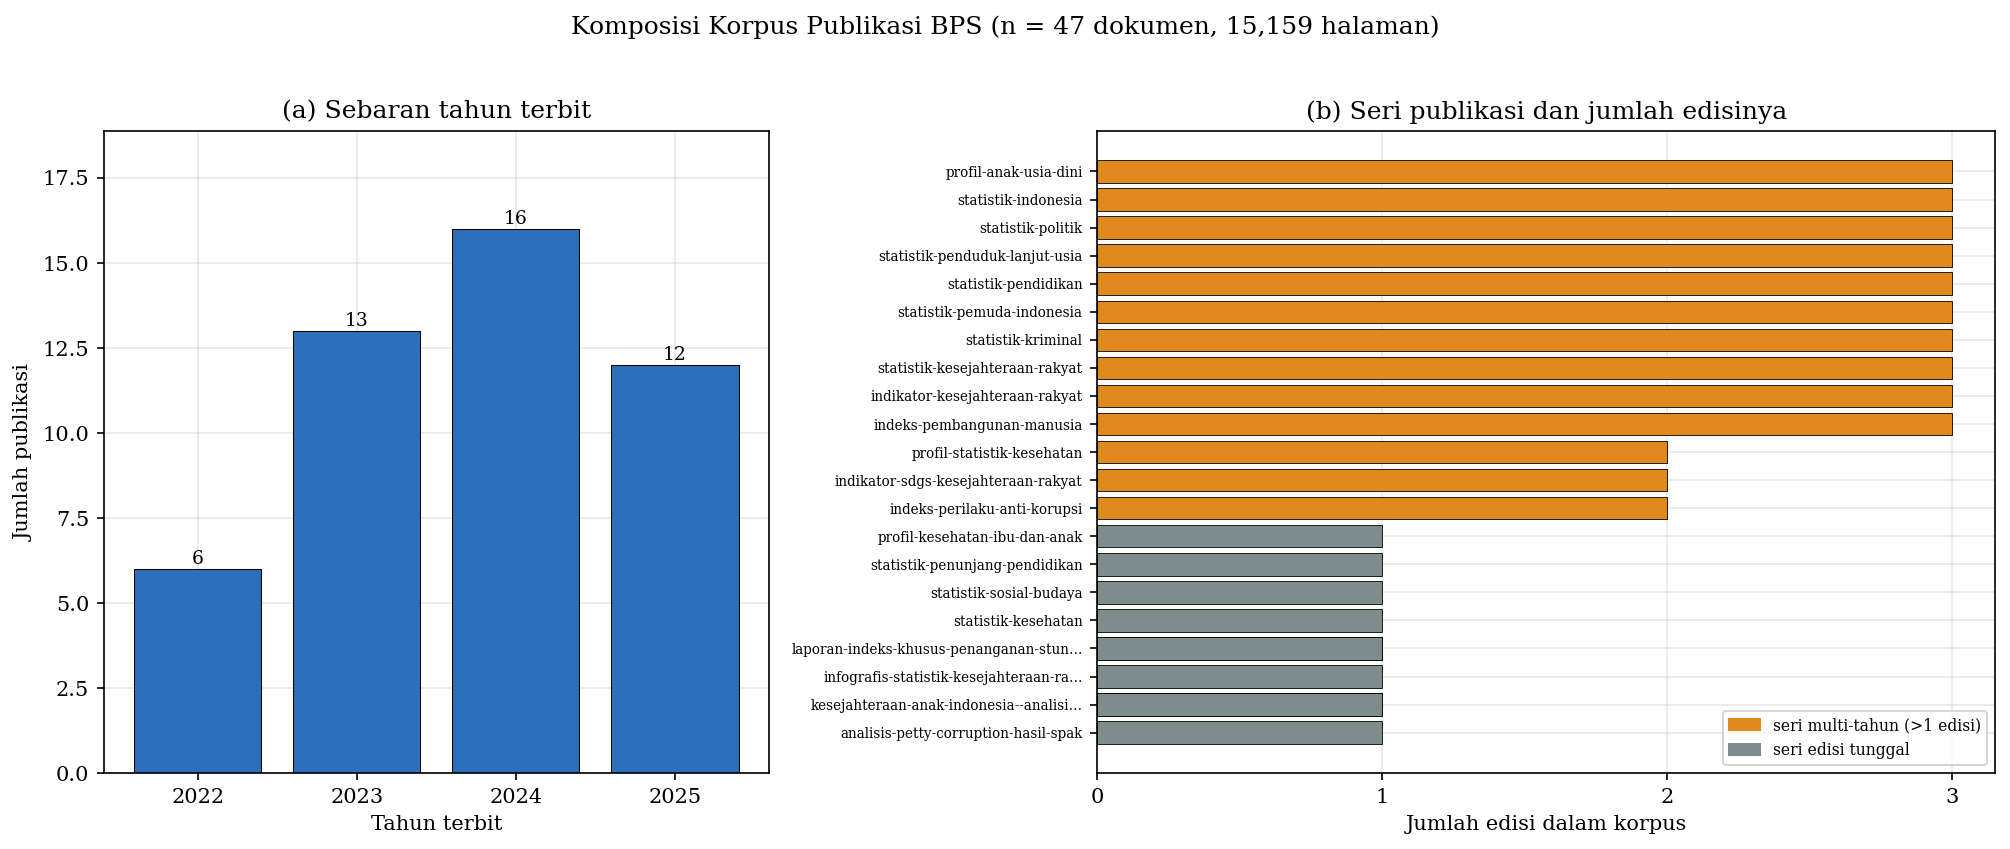

In [55]:
def fig01_komposisi_korpus():
    fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.5),
                             gridspec_kw={"width_ratios": [1, 1.35]})

    per_tahun = df_clean["tahun"].value_counts().sort_index()
    axes[0].bar(per_tahun.index.astype(int).astype(str), per_tahun.values,
                color=C_CLEAN, edgecolor="black", linewidth=.5)
    for i, v in enumerate(per_tahun.values):
        axes[0].text(i, v + .15, str(v), ha="center", fontsize=9)
    axes[0].set_xlabel("Tahun terbit"); axes[0].set_ylabel("Jumlah publikasi")
    axes[0].set_title("(a) Sebaran tahun terbit")
    axes[0].set_ylim(0, per_tahun.max() * 1.18)

    per_seri = df_clean["seri"].value_counts().sort_values()
    warna = [C_ACCENT if v > 1 else C_MUTED for v in per_seri.values]
    axes[1].barh([label_pendek(s, 38) for s in per_seri.index], per_seri.values,
                 color=warna, edgecolor="black", linewidth=.4)
    axes[1].set_xlabel("Jumlah edisi dalam korpus")
    axes[1].set_title("(b) Seri publikasi dan jumlah edisinya")
    axes[1].tick_params(axis="y", labelsize=6.5)
    axes[1].set_xticks(range(0, int(per_seri.max()) + 1))
    axes[1].legend(handles=[Patch(color=C_ACCENT, label="seri multi-tahun (>1 edisi)"),
                            Patch(color=C_MUTED, label="seri edisi tunggal")],
                   fontsize=7.5, loc="lower right")

    fig.suptitle(f"Komposisi Korpus Publikasi BPS (n = {len(df_clean)} dokumen, "
                 f"{df_clean['halaman'].sum():,} halaman)", y=1.02)
    plt.tight_layout(); plt.savefig("fig01_komposisi_korpus.png", bbox_inches="tight"); plt.show()

fig01_komposisi_korpus()

### Gambar 2 — Ukuran tiap dokumen: jumlah halaman

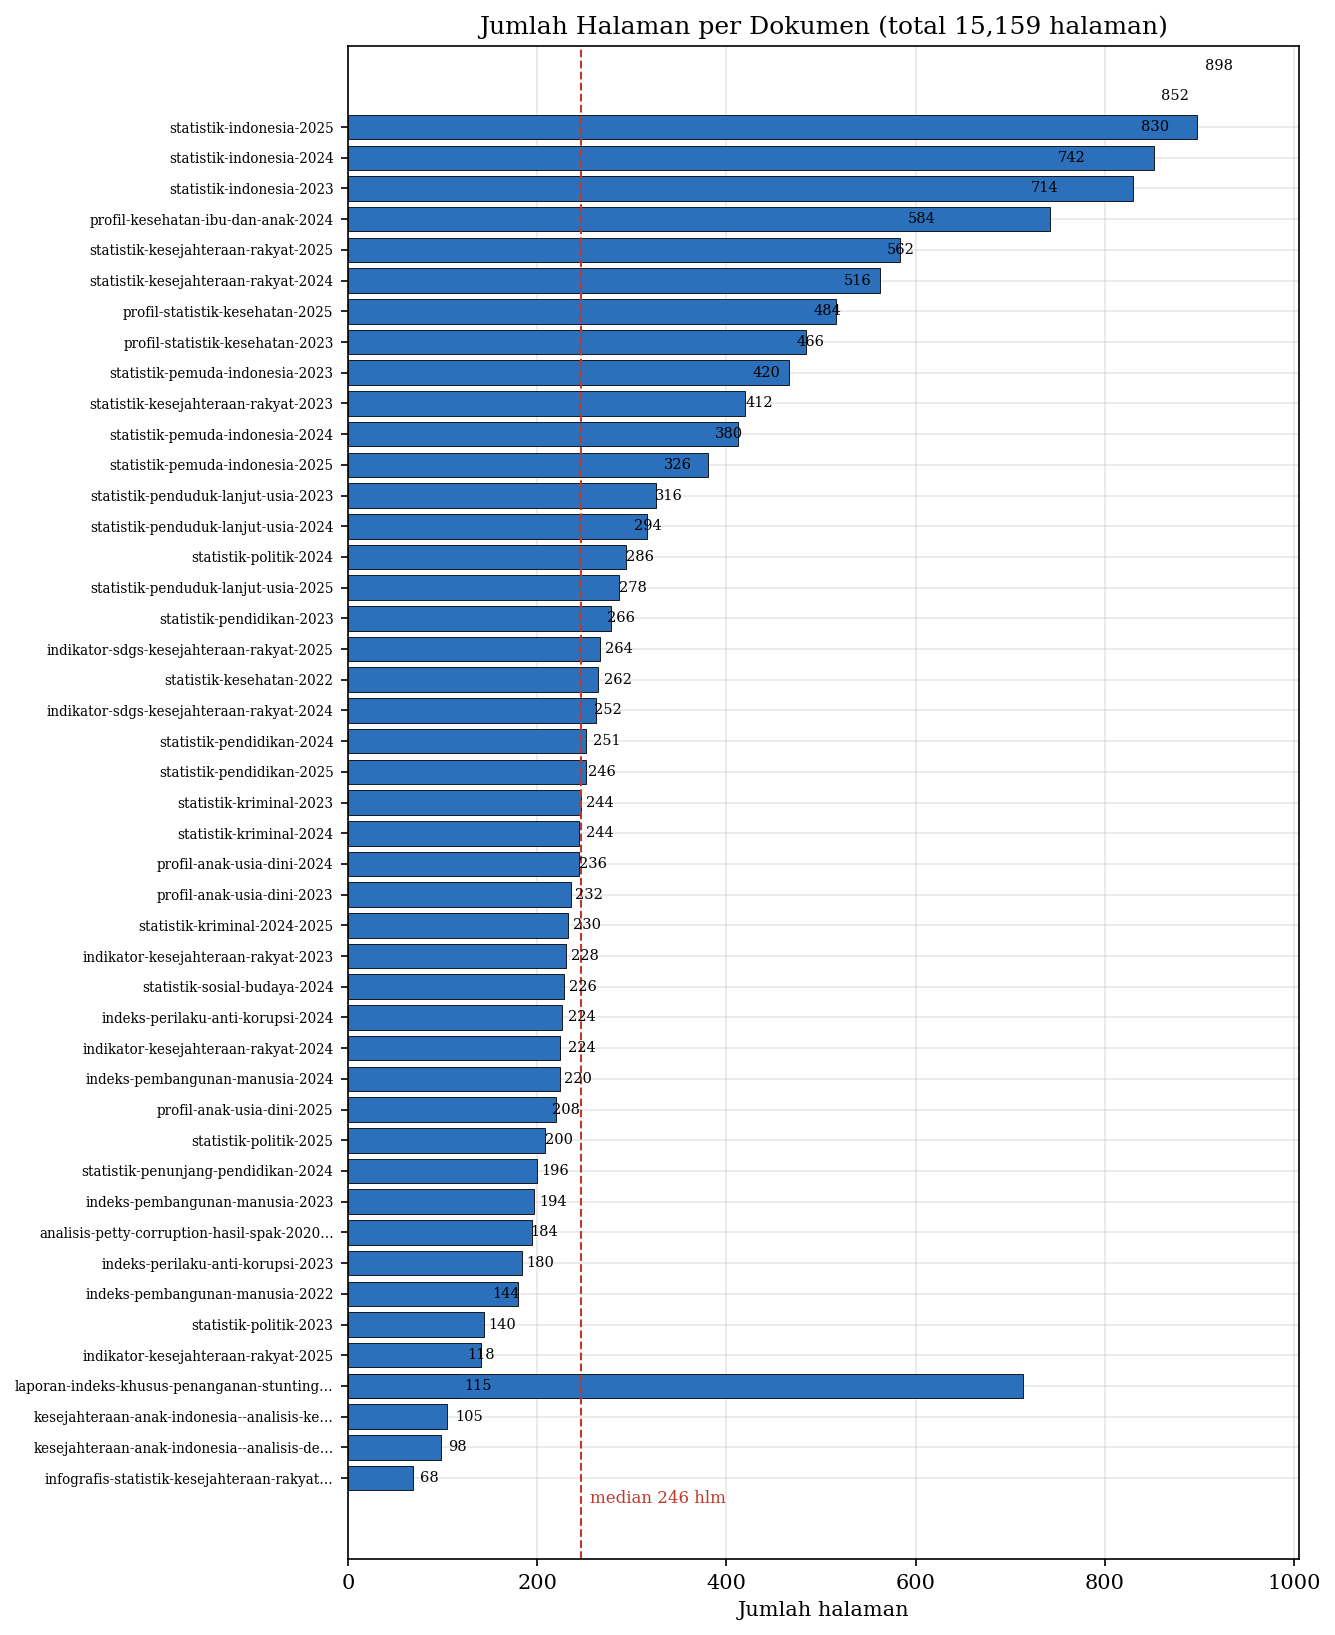

In [56]:
def fig02_halaman_per_dokumen():
    d = df_clean.sort_values("halaman")
    fig, ax = plt.subplots(figsize=(9, 11))
    ax.barh([label_pendek(n) for n in d["nama_file"]], d["halaman"],
            color=C_CLEAN, edgecolor="black", linewidth=.4)
    for y, v in enumerate(d["halaman"]):
        ax.text(v + 8, y, f"{v:,}", va="center", fontsize=7)
    ax.axvline(d["halaman"].median(), ls="--", color=C_DROP, lw=1)
    ax.text(d["halaman"].median() + 10, -0.8, f"median {d['halaman'].median():.0f} hlm",
            color=C_DROP, fontsize=8)
    ax.set_xlabel("Jumlah halaman"); ax.tick_params(axis="y", labelsize=6.5)
    ax.set_xlim(0, d["halaman"].max() * 1.12)
    ax.set_title(f"Jumlah Halaman per Dokumen (total {df_clean['halaman'].sum():,} halaman)")
    plt.tight_layout(); plt.savefig("fig02_halaman_per_dokumen.png", bbox_inches="tight"); plt.show()

fig02_halaman_per_dokumen()

### Gambar 3 — Volume teks sebelum dan sesudah pembersihan

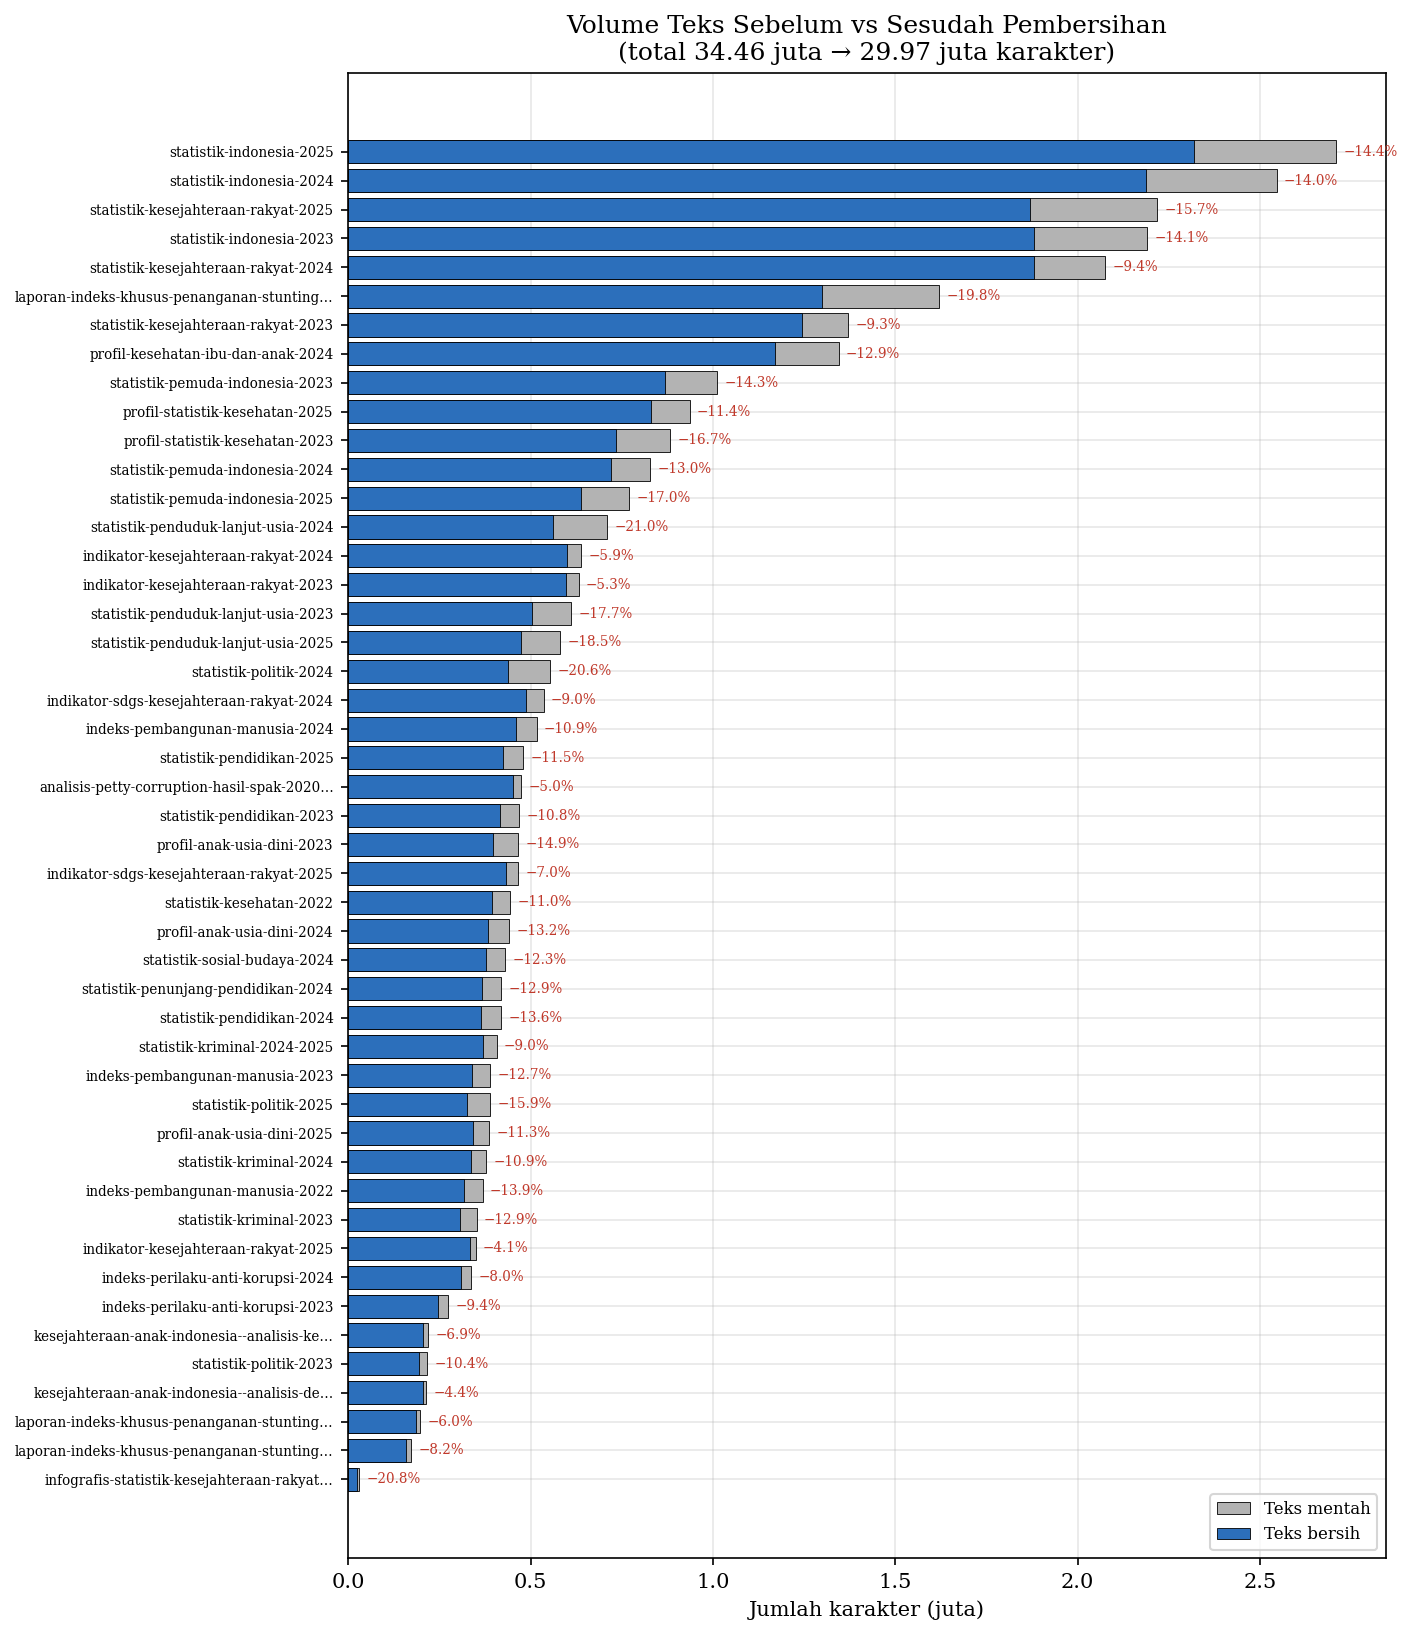

In [57]:
def fig03_volume_teks():
    d = df_clean.sort_values("chars_raw")
    y = np.arange(len(d))
    fig, ax = plt.subplots(figsize=(9.5, 11))
    ax.barh(y, d["chars_raw"] / 1e6, color=C_RAW, edgecolor="black", linewidth=.4, label="Teks mentah")
    ax.barh(y, d["chars_clean"] / 1e6, color=C_CLEAN, edgecolor="black", linewidth=.4, label="Teks bersih")
    ax.set_yticks(y); ax.set_yticklabels([label_pendek(n) for n in d["nama_file"]], fontsize=6.5)
    for yi, (raw, clean) in enumerate(zip(d["chars_raw"], d["chars_clean"])):
        ax.text(raw / 1e6 + .02, yi, f"−{100 * (raw - clean) / raw:.1f}%", va="center", fontsize=6.5, color=C_DROP)
    ax.set_xlabel("Jumlah karakter (juta)")
    ax.set_title(f"Volume Teks Sebelum vs Sesudah Pembersihan\n"
                 f"(total {df_clean['chars_raw'].sum() / 1e6:.2f} juta → "
                 f"{df_clean['chars_clean'].sum() / 1e6:.2f} juta karakter)")
    ax.legend(fontsize=8, loc="lower right")
    plt.tight_layout(); plt.savefig("fig03_volume_teks.png", bbox_inches="tight"); plt.show()

fig03_volume_teks()

### Gambar 4 — Tingkat reduksi pembersihan per dokumen

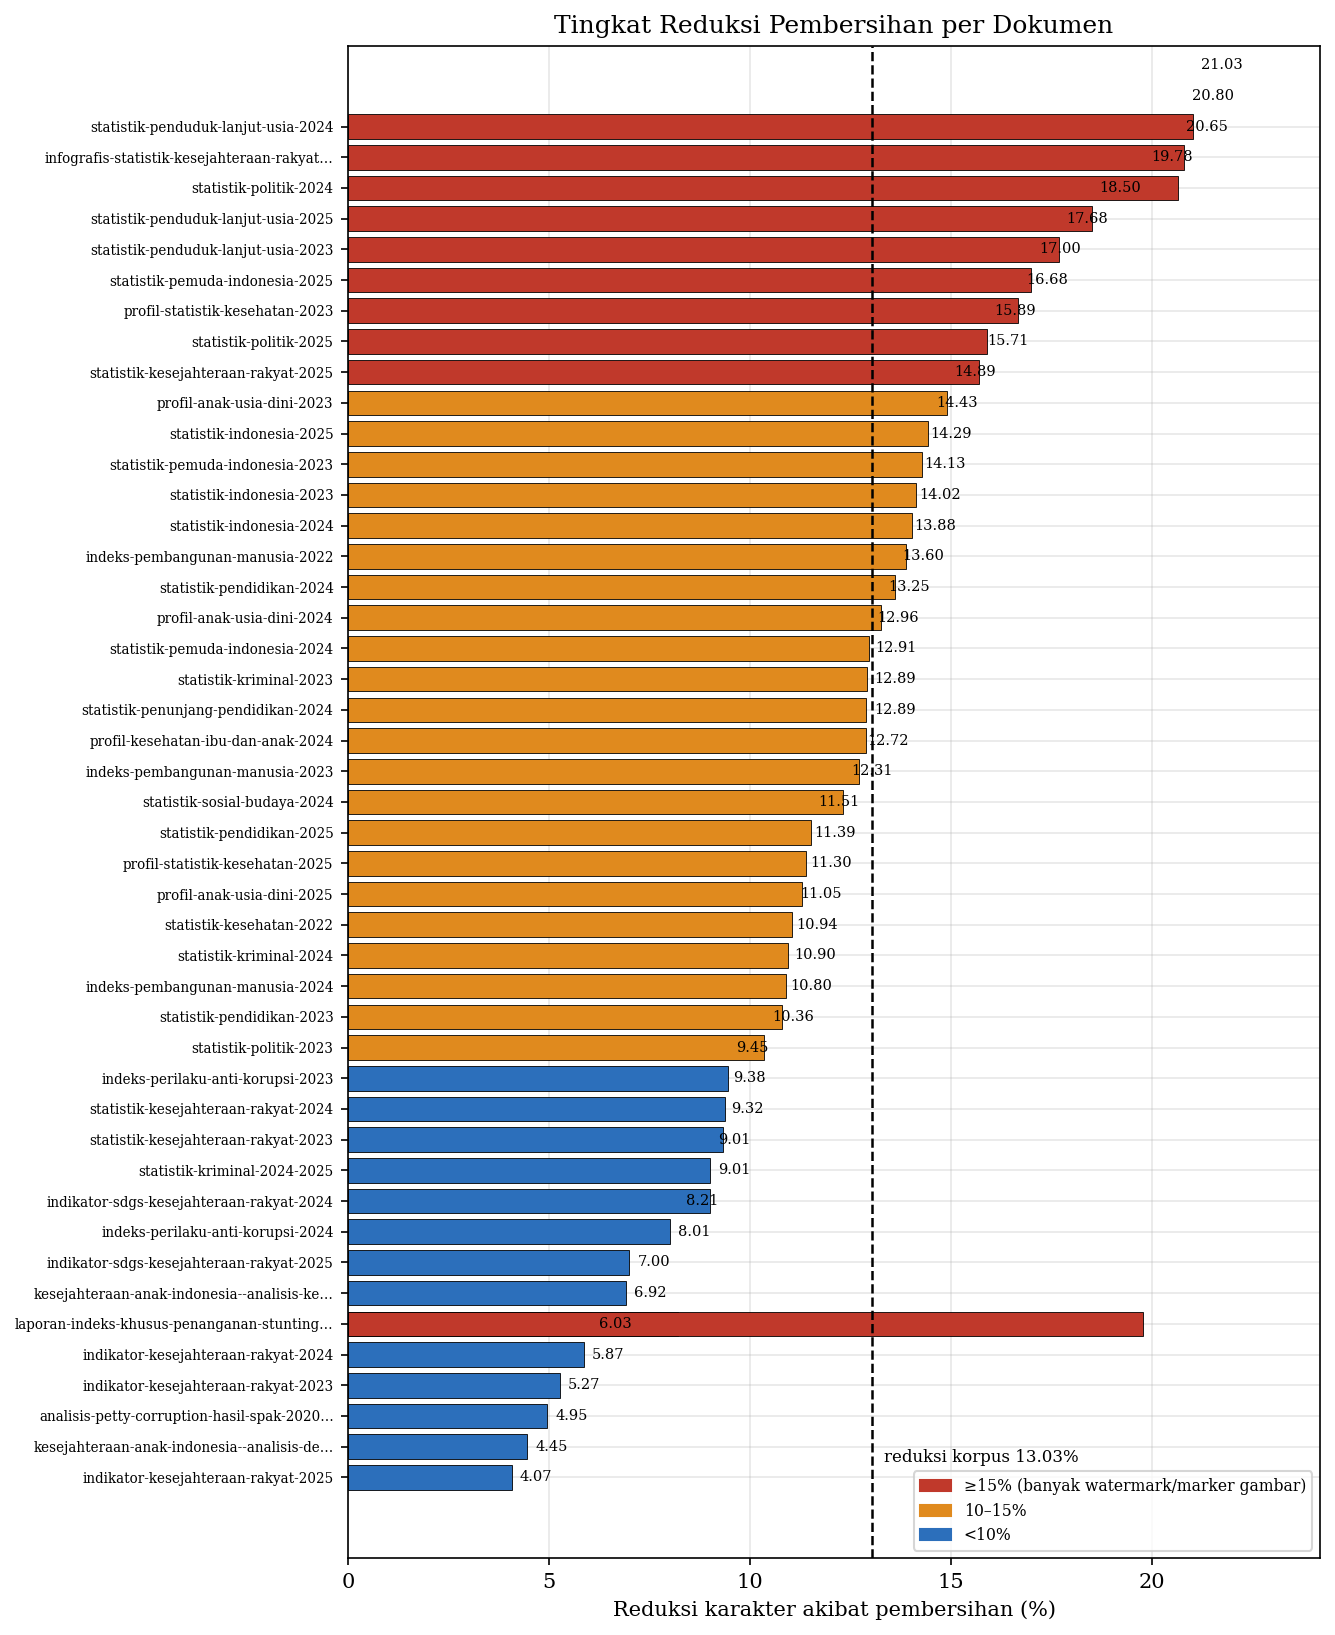

In [58]:
def fig04_reduksi_cleaning():
    d = df_clean.sort_values("reduction_pct")
    reduksi_korpus = 100 * df_clean["chars_removed"].sum() / df_clean["chars_raw"].sum()
    warna = [C_DROP if v >= 15 else (C_ACCENT if v >= 10 else C_CLEAN) for v in d["reduction_pct"]]
    fig, ax = plt.subplots(figsize=(9, 11))
    ax.barh([label_pendek(n) for n in d["nama_file"]], d["reduction_pct"],
            color=warna, edgecolor="black", linewidth=.4)
    for y, v in enumerate(d["reduction_pct"]):
        ax.text(v + .2, y, f"{v:.2f}", va="center", fontsize=7)
    ax.axvline(reduksi_korpus, ls="--", color="black", lw=1.2)
    ax.text(reduksi_korpus + .3, 0.5, f"reduksi korpus {reduksi_korpus:.2f}%", fontsize=8)
    ax.set_xlabel("Reduksi karakter akibat pembersihan (%)")
    ax.tick_params(axis="y", labelsize=6.5); ax.set_xlim(0, d["reduction_pct"].max() * 1.15)
    ax.set_title("Tingkat Reduksi Pembersihan per Dokumen")
    ax.legend(handles=[Patch(color=C_DROP, label="≥15% (banyak watermark/marker gambar)"),
                       Patch(color=C_ACCENT, label="10–15%"),
                       Patch(color=C_CLEAN, label="<10%")], fontsize=7.5, loc="lower right")
    plt.tight_layout(); plt.savefig("fig04_reduksi_cleaning.png", bbox_inches="tight"); plt.show()

fig04_reduksi_cleaning()

### Gambar 5 — Kepadatan teks: hubungan jumlah halaman dan volume karakter

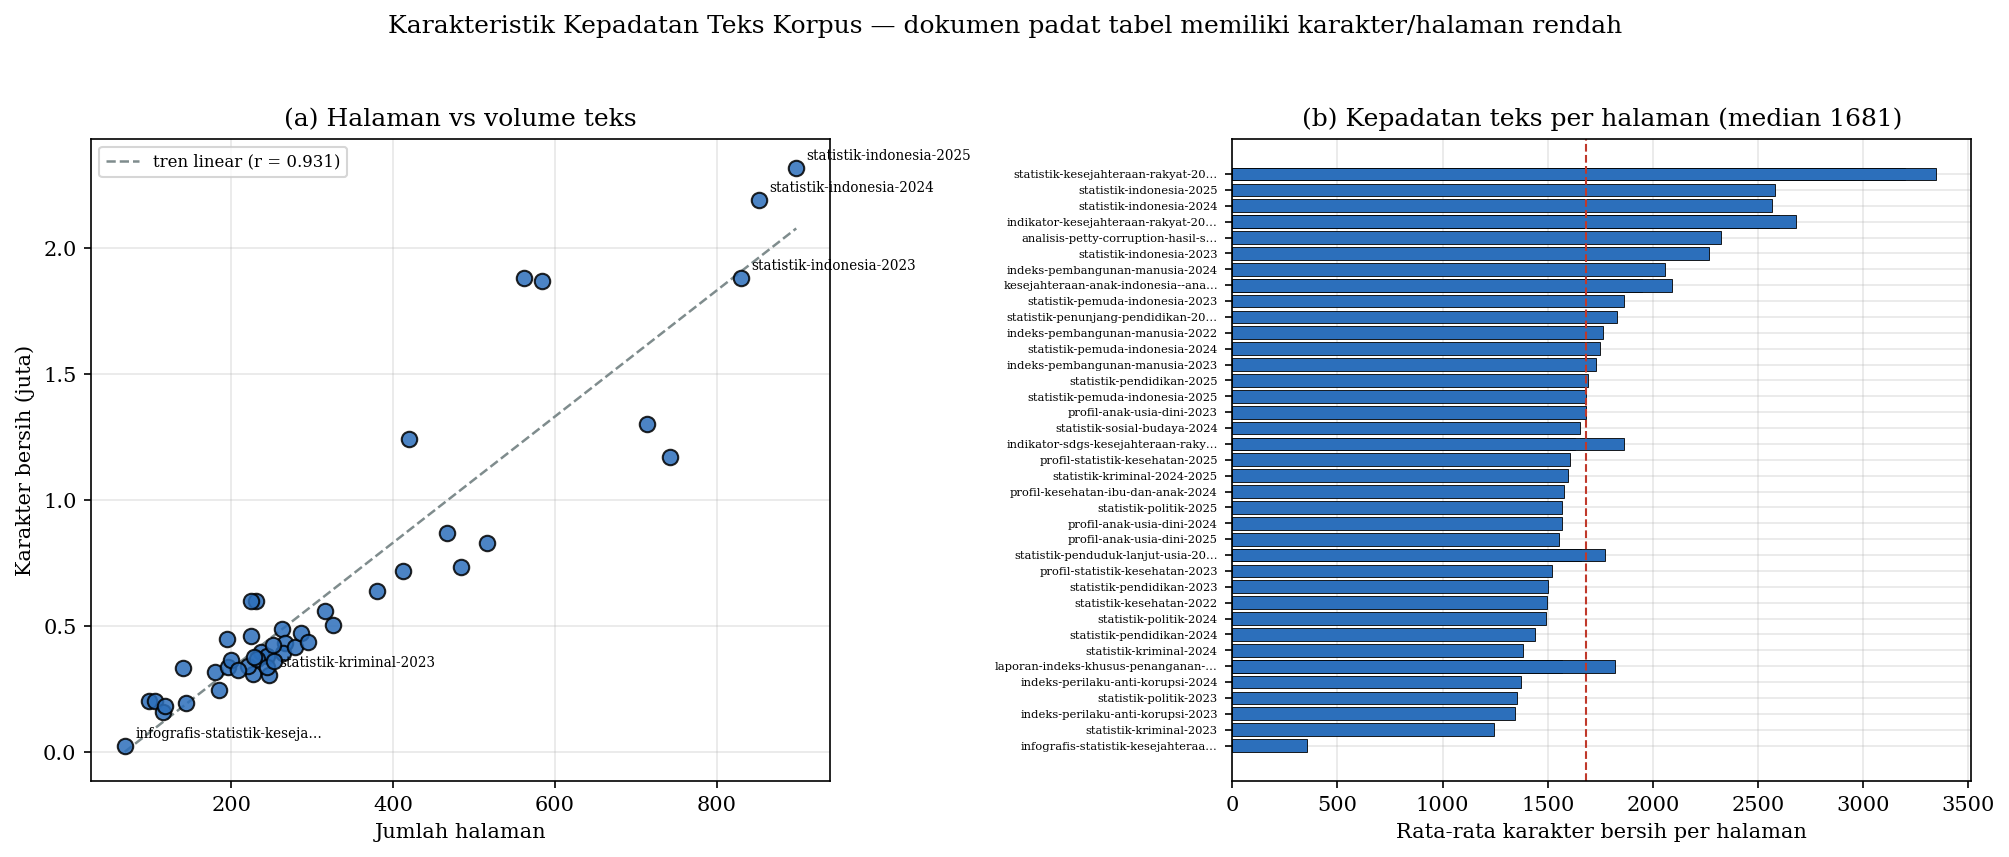

In [59]:
def fig05_kepadatan_teks():
    fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.5))

    ax = axes[0]
    ax.scatter(df_clean["halaman"], df_clean["chars_clean"] / 1e6, s=55,
               color=C_CLEAN, edgecolor="black", zorder=3, alpha=.85)
    koef = np.polyfit(df_clean["halaman"], df_clean["chars_clean"] / 1e6, 1)
    xg = np.linspace(df_clean["halaman"].min(), df_clean["halaman"].max(), 100)
    r = np.corrcoef(df_clean["halaman"], df_clean["chars_clean"])[0, 1]
    ax.plot(xg, np.polyval(koef, xg), ls="--", color=C_MUTED, lw=1.2, label=f"tren linear (r = {r:.3f})")
    ekstrem = pd.concat([df_clean.nlargest(3, "halaman"), df_clean.nsmallest(2, "chars_per_page")])
    for _, row in ekstrem.drop_duplicates("nama_file").iterrows():
        ax.annotate(label_pendek(row["nama_file"], 28), (row["halaman"], row["chars_clean"] / 1e6),
                    fontsize=6.5, xytext=(5, 4), textcoords="offset points")
    ax.set_xlabel("Jumlah halaman"); ax.set_ylabel("Karakter bersih (juta)")
    ax.set_title("(a) Halaman vs volume teks"); ax.legend(fontsize=8)

    ax = axes[1]
    d = df_clean.sort_values("chars_per_page")
    ax.barh([label_pendek(n, 34) for n in d["nama_file"]], d["chars_per_page"],
            color=C_CLEAN, edgecolor="black", linewidth=.4)
    ax.axvline(d["chars_per_page"].median(), ls="--", color=C_DROP, lw=1)
    ax.set_xlabel("Rata-rata karakter bersih per halaman")
    ax.tick_params(axis="y", labelsize=5.5)
    ax.set_title(f"(b) Kepadatan teks per halaman (median {d['chars_per_page'].median():.0f})")

    fig.suptitle("Karakteristik Kepadatan Teks Korpus — dokumen padat tabel memiliki karakter/halaman rendah", y=1.03)
    plt.tight_layout(); plt.savefig("fig05_kepadatan_teks.png", bbox_inches="tight"); plt.show()

fig05_kepadatan_teks()

### Gambar 6 — Elemen non-substantif yang dihapus: marker gambar dan watermark

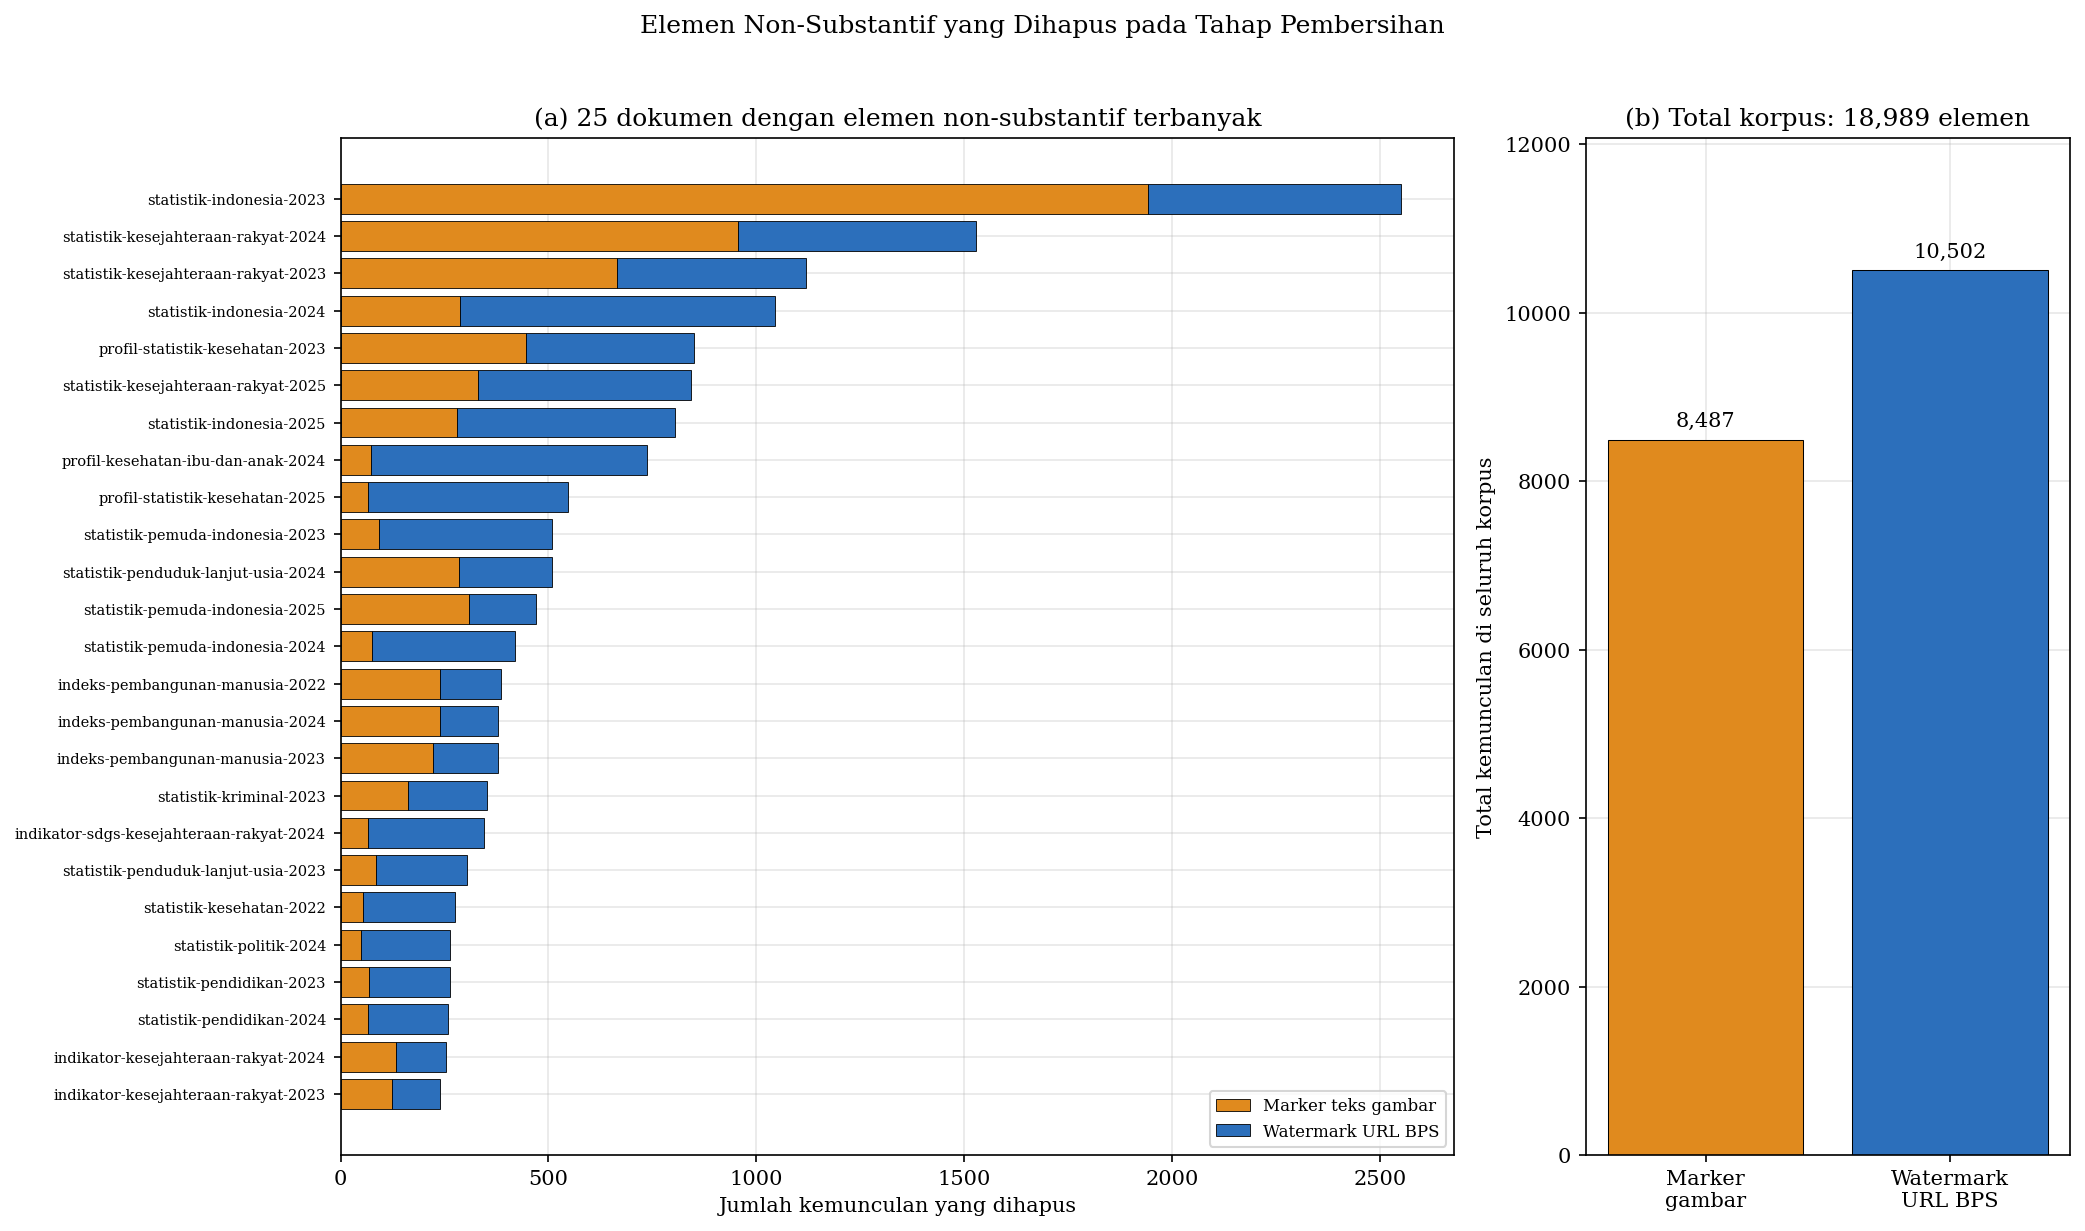

In [60]:
def fig06_elemen_dihapus():
    d = df_clean.copy()
    d["total_dihapus"] = d["picture_removed"] + d["watermark_removed"]
    d = d.sort_values("total_dihapus").tail(25)
    y = np.arange(len(d))
    fig, axes = plt.subplots(1, 2, figsize=(14, 8), gridspec_kw={"width_ratios": [2.3, 1]})

    ax = axes[0]
    ax.barh(y, d["picture_removed"], color=C_ACCENT, edgecolor="black", linewidth=.4, label="Marker teks gambar")
    ax.barh(y, d["watermark_removed"], left=d["picture_removed"], color=C_CLEAN,
            edgecolor="black", linewidth=.4, label="Watermark URL BPS")
    ax.set_yticks(y); ax.set_yticklabels([label_pendek(n, 40) for n in d["nama_file"]], fontsize=7)
    ax.set_xlabel("Jumlah kemunculan yang dihapus")
    ax.set_title("(a) 25 dokumen dengan elemen non-substantif terbanyak")
    ax.legend(fontsize=8, loc="lower right")

    ax = axes[1]
    total = [df_clean["picture_removed"].sum(), df_clean["watermark_removed"].sum()]
    ax.bar(["Marker\ngambar", "Watermark\nURL BPS"], total,
           color=[C_ACCENT, C_CLEAN], edgecolor="black", linewidth=.5)
    for i, v in enumerate(total):
        ax.text(i, v + max(total) * .015, f"{v:,}", ha="center", fontsize=10)
    ax.set_ylabel("Total kemunculan di seluruh korpus")
    ax.set_title(f"(b) Total korpus: {sum(total):,} elemen")
    ax.set_ylim(0, max(total) * 1.15)

    fig.suptitle("Elemen Non-Substantif yang Dihapus pada Tahap Pembersihan", y=1.02)
    plt.tight_layout(); plt.savefig("fig06_elemen_dihapus.png", bbox_inches="tight"); plt.show()

fig06_elemen_dihapus()

### Gambar 7 — Kualitas hasil ekstraksi: halaman kosong dan halaman berteks minim
Halaman kosong (0 karakter) dan halaman berteks minim (0 < karakter < 100) menandakan halaman yang didominasi gambar/tabel hasil pindaian sehingga OCR tidak menghasilkan teks yang memadai. Proporsinya menjadi indikator batas kualitas ekstraksi.

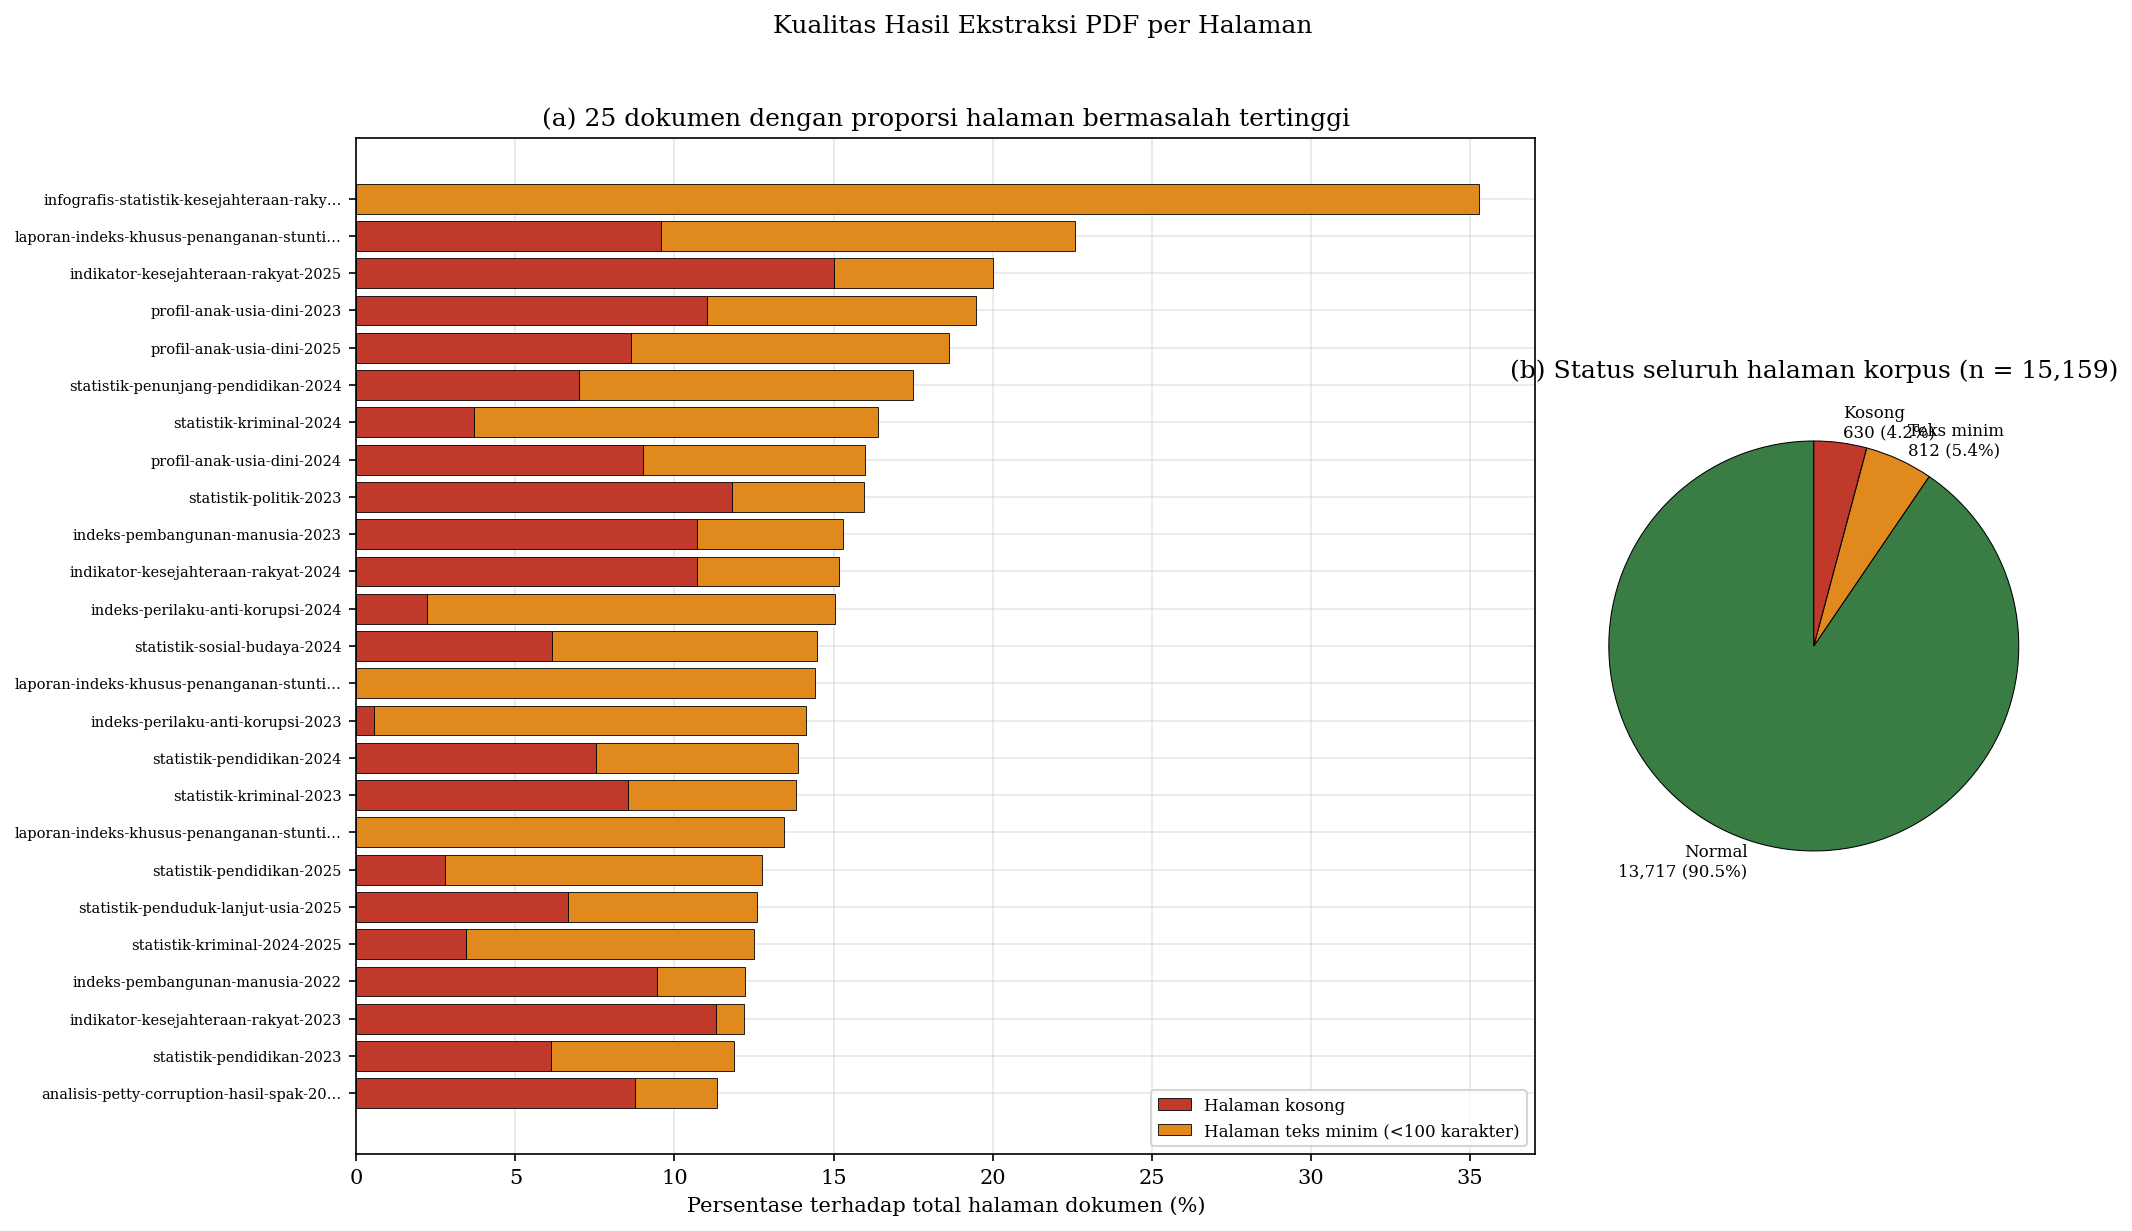

In [61]:
def fig07_kualitas_ekstraksi():
    d = df_clean.sort_values("problem_page_pct").tail(25)
    y = np.arange(len(d))
    fig, axes = plt.subplots(1, 2, figsize=(14, 8), gridspec_kw={"width_ratios": [2.3, 1]})

    ax = axes[0]
    ax.barh(y, 100 * d["empty_pages"] / d["halaman"], color=C_DROP,
            edgecolor="black", linewidth=.4, label="Halaman kosong")
    ax.barh(y, 100 * d["low_char_pages"] / d["halaman"], left=100 * d["empty_pages"] / d["halaman"],
            color=C_ACCENT, edgecolor="black", linewidth=.4, label="Halaman teks minim (<100 karakter)")
    ax.set_yticks(y); ax.set_yticklabels([label_pendek(n, 40) for n in d["nama_file"]], fontsize=7)
    ax.set_xlabel("Persentase terhadap total halaman dokumen (%)")
    ax.set_title("(a) 25 dokumen dengan proporsi halaman bermasalah tertinggi")
    ax.legend(fontsize=8, loc="lower right")

    ax = axes[1]
    total_hlm = df_clean["halaman"].sum()
    kosong, minim = df_clean["empty_pages"].sum(), df_clean["low_char_pages"].sum()
    normal = total_hlm - kosong - minim
    ax.pie([normal, minim, kosong],
           labels=[f"Normal\n{normal:,} ({100 * normal / total_hlm:.1f}%)",
                   f"Teks minim\n{minim:,} ({100 * minim / total_hlm:.1f}%)",
                   f"Kosong\n{kosong:,} ({100 * kosong / total_hlm:.1f}%)"],
           colors=[C_KEEP, C_ACCENT, C_DROP], startangle=90,
           wedgeprops={"edgecolor": "black", "linewidth": .5}, textprops={"fontsize": 8})
    ax.set_title(f"(b) Status seluruh halaman korpus (n = {total_hlm:,})")
    ax.grid(False)

    fig.suptitle("Kualitas Hasil Ekstraksi PDF per Halaman", y=1.02)
    plt.tight_layout(); plt.savefig("fig07_kualitas_ekstraksi.png", bbox_inches="tight"); plt.show()

fig07_kualitas_ekstraksi()

---
# Bagian 2 — Strukturisasi dan Chunking
Sumber: `03-structured-cleaned-extract.ipynb` dan `04-chunking-and-splitting.ipynb`. Teks bersih dipecah menjadi *section* berdasarkan tujuh detektor heading (markdown, BAB, penomoran desimal, lampiran, daftar isi/tabel/gambar, bagian khusus seperti metodologi, serta prolog), lalu tiap section dipotong menjadi chunk dengan `RecursiveCharacterTextSplitter` (ukuran 2.000 karakter, overlap 200 karakter). Section yang tidak layak dijadikan sumber QA disisihkan dan dicatat alasannya.

### Gambar 8 — Funnel penyusutan: dari section menjadi chunk siap-QA

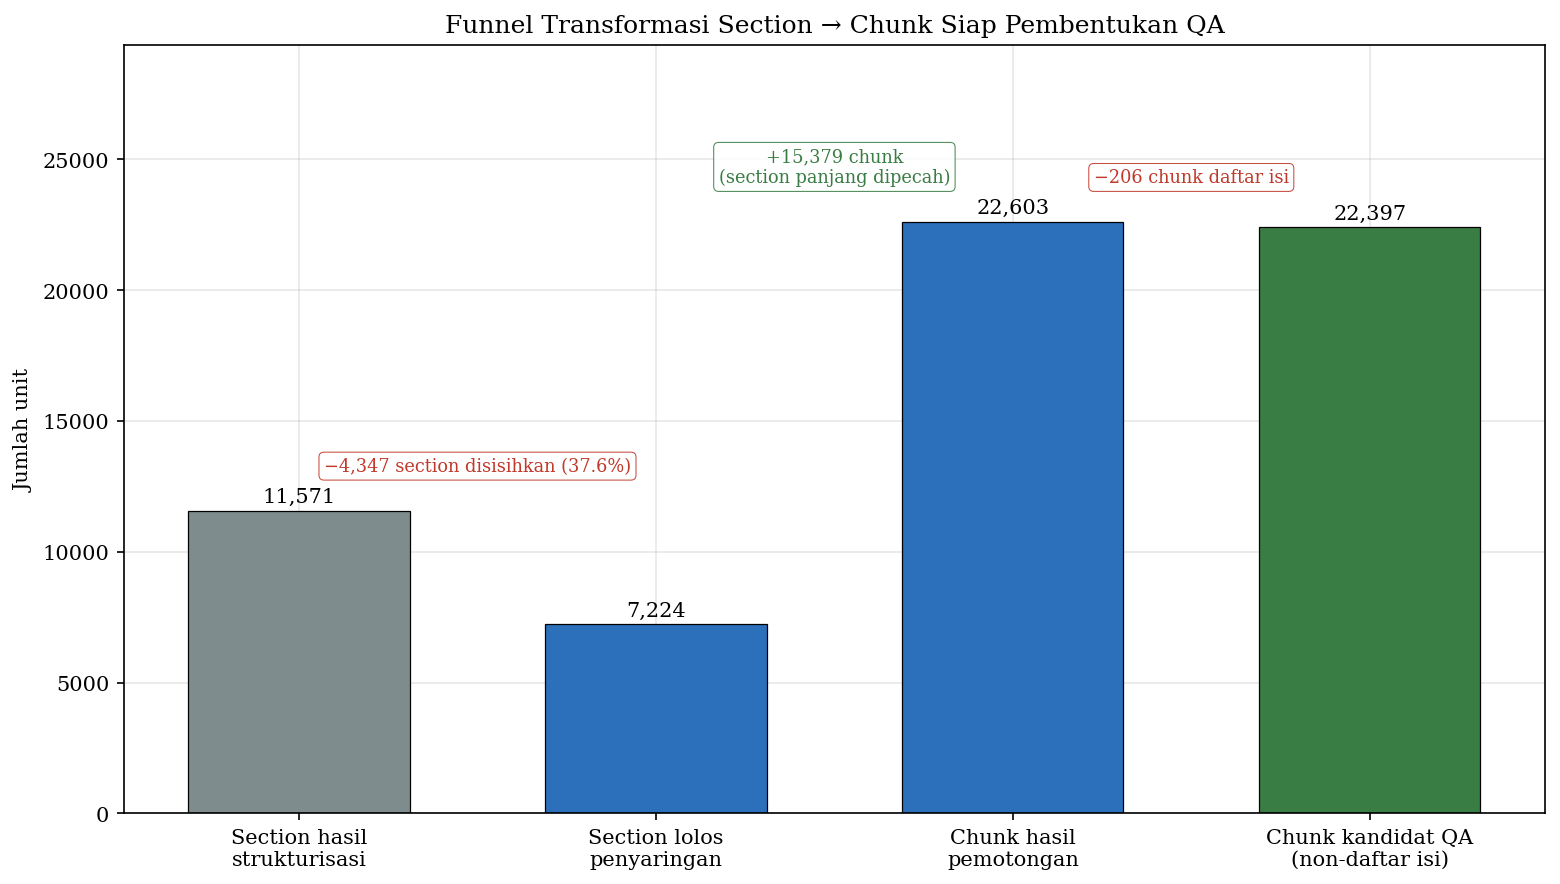

In [62]:
def fig08_funnel_chunking():
    total_section = int(df_chunk["n_sections"].sum())
    disisihkan = sum(EXCLUSION_DIST.values())
    chunk_qa = TOTAL_CHUNKS - CHUNK_TYPE_DIST["toc_table"] - CHUNK_TYPE_DIST["toc_figure"]

    tahap = ["Section hasil\nstrukturisasi", "Section lolos\npenyaringan",
             "Chunk hasil\npemotongan", "Chunk kandidat QA\n(non-daftar isi)"]
    nilai = [total_section, total_section - disisihkan, TOTAL_CHUNKS, chunk_qa]
    warna = [C_MUTED, C_CLEAN, C_CLEAN, C_KEEP]

    fig, ax = plt.subplots(figsize=(10.5, 6))
    bars = ax.bar(tahap, nilai, color=warna, edgecolor="black", linewidth=.6, width=.62)
    for b, v in zip(bars, nilai):
        ax.text(b.get_x() + b.get_width() / 2, v + max(nilai) * .015, f"{v:,}", ha="center", fontsize=10)

    anotasi_funnel(ax, nilai, [
        (f"−{disisihkan:,} section disisihkan ({100 * disisihkan / total_section:.1f}%)", C_DROP),
        (f"+{TOTAL_CHUNKS - nilai[1]:,} chunk\n(section panjang dipecah)", C_KEEP),
        (f"−{CHUNK_TYPE_DIST['toc_table'] + CHUNK_TYPE_DIST['toc_figure']:,} chunk daftar isi", C_DROP),
    ])

    ax.set_ylabel("Jumlah unit"); ax.set_ylim(0, max(nilai) * 1.3)
    ax.set_title("Funnel Transformasi Section → Chunk Siap Pembentukan QA")
    plt.tight_layout(); plt.savefig("fig08_funnel_chunking.png", bbox_inches="tight"); plt.show()

fig08_funnel_chunking()

### Gambar 9 — Alasan penyisihan section

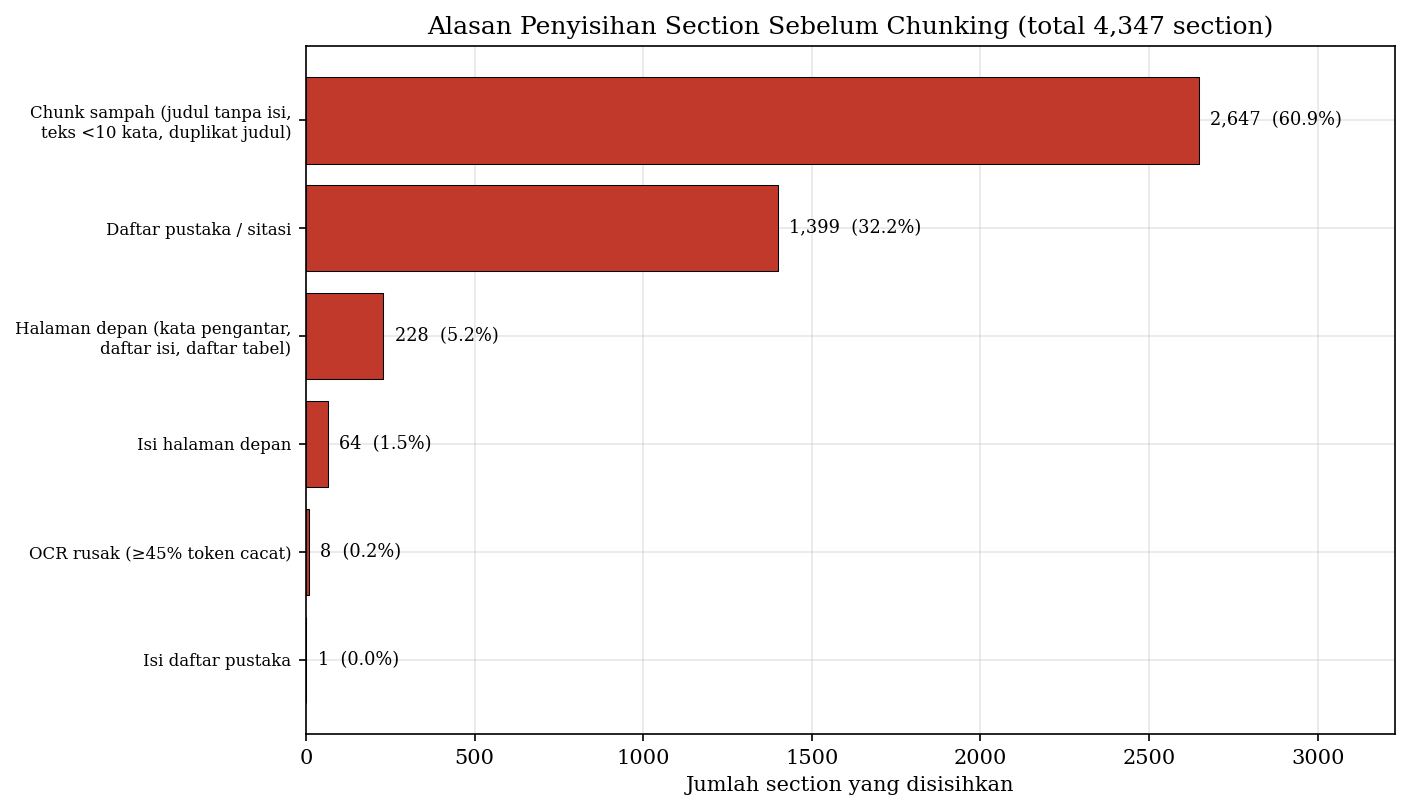

In [63]:
def fig09_alasan_penyisihan():
    ket = {
        "garbage_chunk": "Chunk sampah (judul tanpa isi,\nteks <10 kata, duplikat judul)",
        "reference": "Daftar pustaka / sitasi",
        "front_matter": "Halaman depan (kata pengantar,\ndaftar isi, daftar tabel)",
        "front_matter_content": "Isi halaman depan",
        "ocr_broken": "OCR rusak (≥45% token cacat)",
        "reference_content": "Isi daftar pustaka",
    }
    d = pd.Series(EXCLUSION_DIST).sort_values()
    total = d.sum()
    fig, ax = plt.subplots(figsize=(9.5, 5.5))
    ax.barh([ket[k] for k in d.index], d.values, color=C_DROP, edgecolor="black", linewidth=.5)
    for y, v in enumerate(d.values):
        ax.text(v + total * .008, y, f"{v:,}  ({100 * v / total:.1f}%)", va="center", fontsize=8.5)
    ax.set_xlabel("Jumlah section yang disisihkan")
    ax.set_xlim(0, d.max() * 1.22); ax.tick_params(axis="y", labelsize=8)
    ax.set_title(f"Alasan Penyisihan Section Sebelum Chunking (total {total:,} section)")
    plt.tight_layout(); plt.savefig("fig09_alasan_penyisihan.png", bbox_inches="tight"); plt.show()

fig09_alasan_penyisihan()

### Gambar 10 — Komposisi jenis chunk dan potensi tipe QA yang dihasilkan

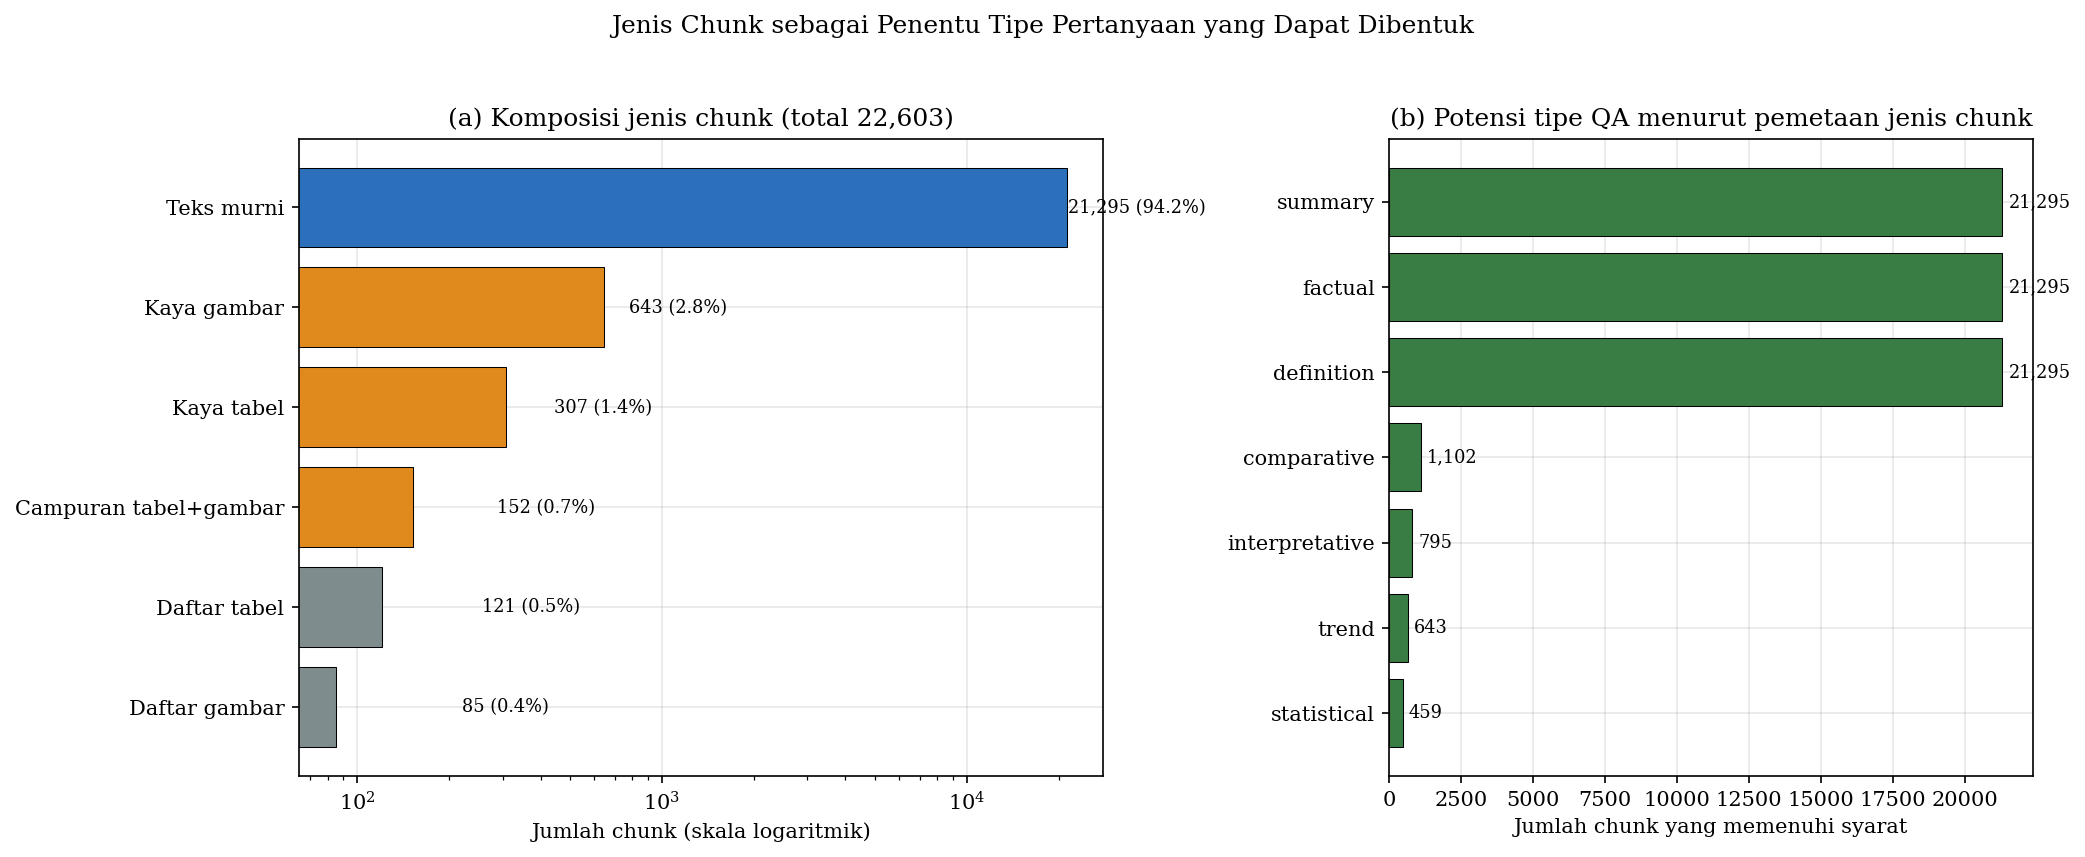

In [64]:
def fig10_jenis_chunk():
    ket = {"text_only": "Teks murni", "figure_rich": "Kaya gambar", "table_rich": "Kaya tabel",
           "mixed_rich": "Campuran tabel+gambar", "toc_table": "Daftar tabel", "toc_figure": "Daftar gambar"}
    d = pd.Series(CHUNK_TYPE_DIST).sort_values()
    total = d.sum()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), gridspec_kw={"width_ratios": [1.25, 1]})

    ax = axes[0]
    warna = [C_MUTED if k.startswith("toc") else (C_CLEAN if k == "text_only" else C_ACCENT) for k in d.index]
    ax.barh([ket[k] for k in d.index], d.values, color=warna, edgecolor="black", linewidth=.5)
    for y, v in enumerate(d.values):
        ax.text(v + total * .006, y, f"{v:,} ({100 * v / total:.1f}%)", va="center", fontsize=8.5)
    ax.set_xscale("log"); ax.set_xlabel("Jumlah chunk (skala logaritmik)")
    ax.set_title(f"(a) Komposisi jenis chunk (total {total:,})")

    ax = axes[1]
    potensi = {}
    for tipe, kandidat in QA_CANDIDATES.items():
        for jenis_qa in kandidat:
            potensi[jenis_qa] = potensi.get(jenis_qa, 0) + CHUNK_TYPE_DIST.get(tipe, 0)
    p = pd.Series(potensi).sort_values()
    ax.barh(p.index, p.values, color=C_KEEP, edgecolor="black", linewidth=.5)
    for y, v in enumerate(p.values):
        ax.text(v + p.max() * .01, y, f"{v:,}", va="center", fontsize=8.5)
    ax.set_xlabel("Jumlah chunk yang memenuhi syarat")
    ax.set_title("(b) Potensi tipe QA menurut pemetaan jenis chunk")

    fig.suptitle("Jenis Chunk sebagai Penentu Tipe Pertanyaan yang Dapat Dibentuk", y=1.03)
    plt.tight_layout(); plt.savefig("fig10_jenis_chunk.png", bbox_inches="tight"); plt.show()

fig10_jenis_chunk()

### Gambar 11 — Rasio pemecahan: section terhadap chunk per dokumen

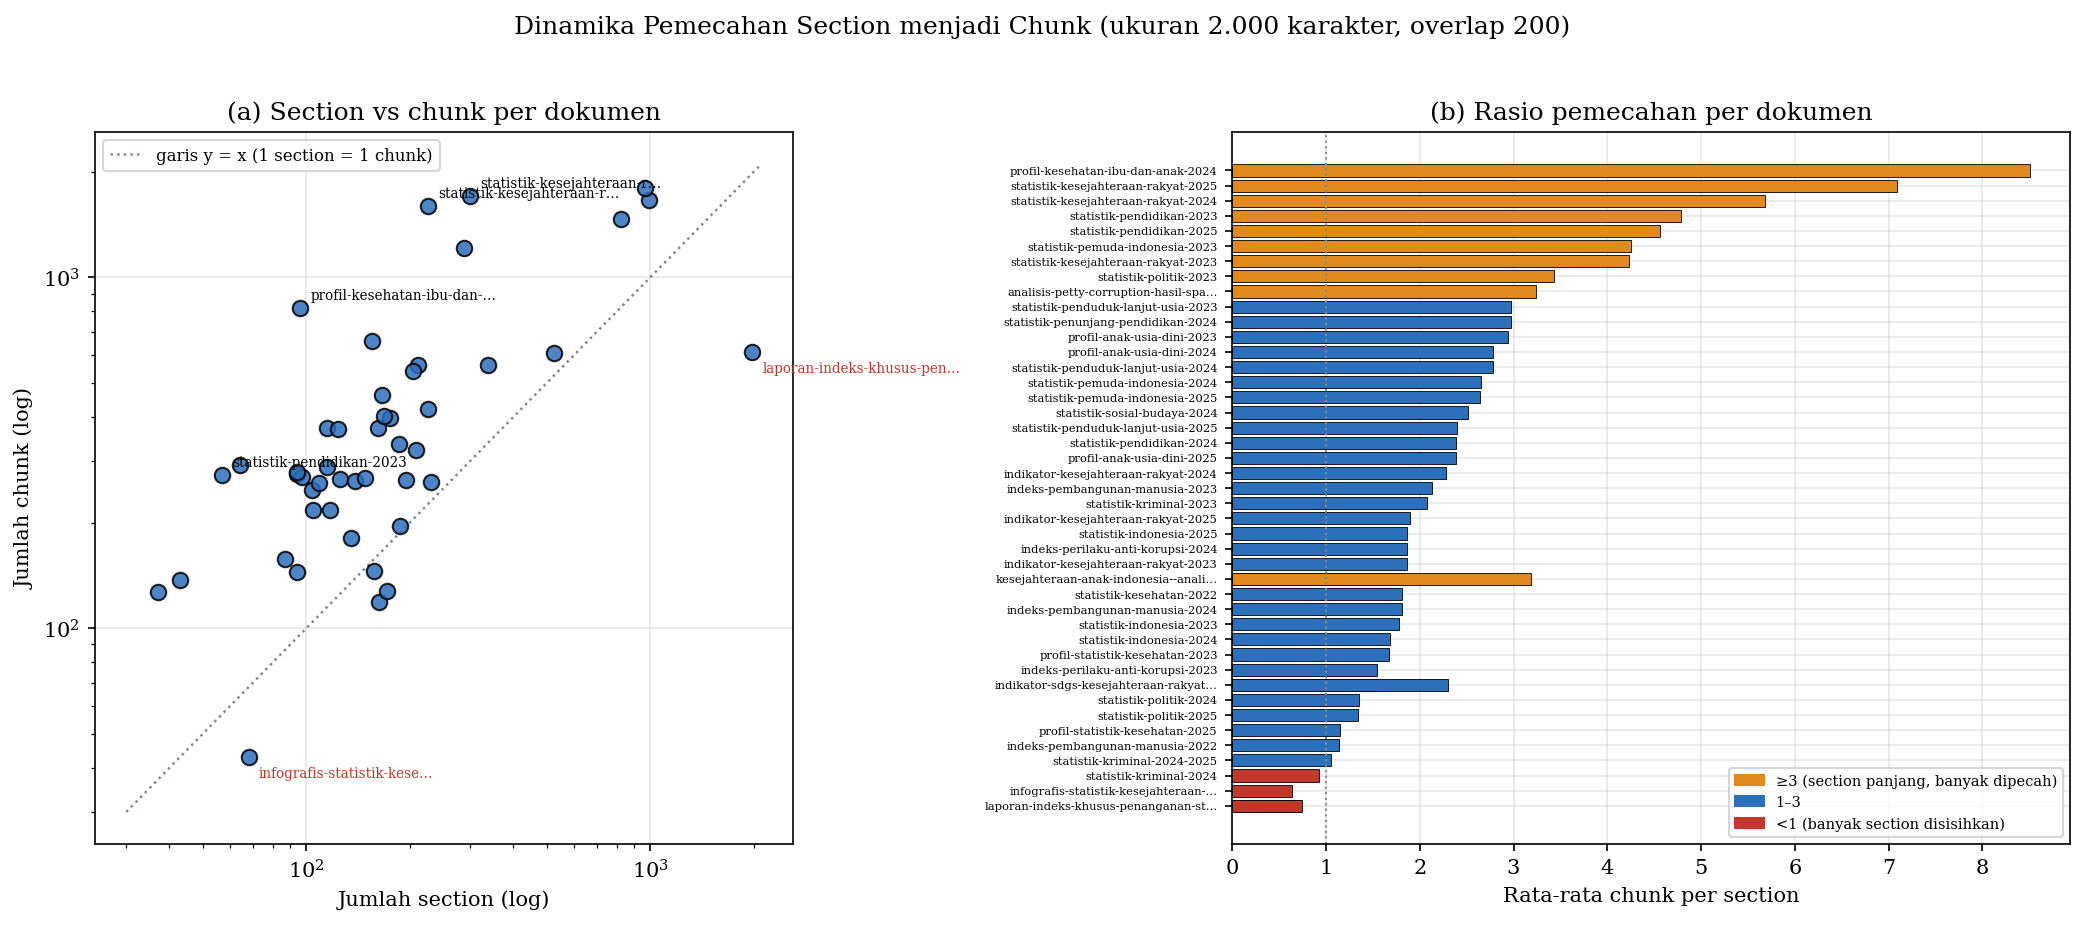

In [65]:
def fig11_rasio_section_chunk():
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={"width_ratios": [1, 1.2]})

    ax = axes[0]
    ax.scatter(df_korpus["n_sections"], df_korpus["n_chunks"], s=55,
               color=C_CLEAN, edgecolor="black", zorder=3, alpha=.85)
    lim = [30, 2100]
    ax.plot(lim, lim, ls=":", color=C_MUTED, lw=1.2, label="garis y = x (1 section = 1 chunk)")
    for _, row in df_korpus.nlargest(4, "chunk_per_section").iterrows():
        ax.annotate(label_pendek(row["nama_file"], 26), (row["n_sections"], row["n_chunks"]),
                    fontsize=6.5, xytext=(5, 4), textcoords="offset points")
    ekstrem_rendah = df_korpus.nsmallest(2, "chunk_per_section")
    for _, row in ekstrem_rendah.iterrows():
        ax.annotate(label_pendek(row["nama_file"], 26), (row["n_sections"], row["n_chunks"]),
                    fontsize=6.5, xytext=(5, -10), textcoords="offset points", color=C_DROP)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Jumlah section (log)"); ax.set_ylabel("Jumlah chunk (log)")
    ax.set_title("(a) Section vs chunk per dokumen"); ax.legend(fontsize=8)

    ax = axes[1]
    d = df_korpus.sort_values("chunk_per_section")
    warna = [C_ACCENT if v >= 3 else (C_CLEAN if v >= 1 else C_DROP) for v in d["chunk_per_section"]]
    ax.barh([label_pendek(n, 36) for n in d["nama_file"]], d["chunk_per_section"],
            color=warna, edgecolor="black", linewidth=.4)
    ax.axvline(1, ls=":", color=C_MUTED, lw=1)
    ax.set_xlabel("Rata-rata chunk per section")
    ax.tick_params(axis="y", labelsize=5.5)
    ax.set_title("(b) Rasio pemecahan per dokumen")
    ax.legend(handles=[Patch(color=C_ACCENT, label="≥3 (section panjang, banyak dipecah)"),
                       Patch(color=C_CLEAN, label="1–3"),
                       Patch(color=C_DROP, label="<1 (banyak section disisihkan)")],
              fontsize=7, loc="lower right")

    fig.suptitle("Dinamika Pemecahan Section menjadi Chunk (ukuran 2.000 karakter, overlap 200)", y=1.02)
    plt.tight_layout(); plt.savefig("fig11_rasio_section_chunk.png", bbox_inches="tight"); plt.show()

fig11_rasio_section_chunk()

### Gambar 12 — Kontribusi tiap dokumen terhadap total chunk korpus

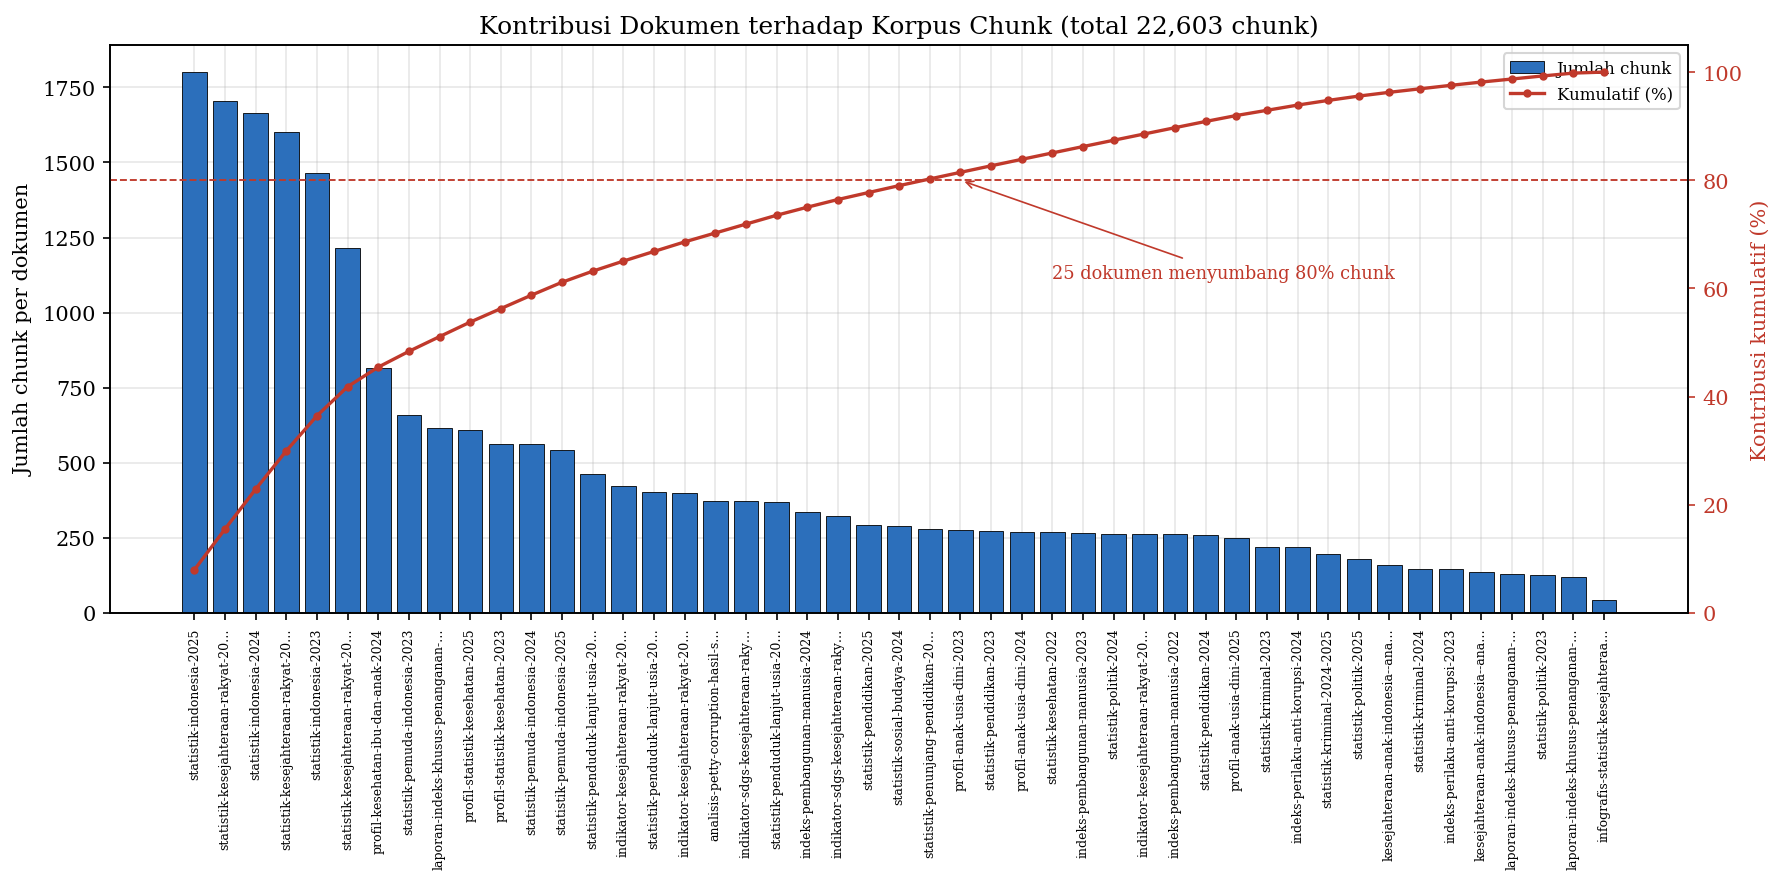

In [66]:
def fig12_kontribusi_chunk():
    d = df_korpus.sort_values("n_chunks", ascending=False).reset_index(drop=True)
    d["kumulatif_pct"] = 100 * d["n_chunks"].cumsum() / d["n_chunks"].sum()

    fig, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(len(d))
    ax.bar(x, d["n_chunks"], color=C_CLEAN, edgecolor="black", linewidth=.4, label="Jumlah chunk")
    ax.set_xticks(x); ax.set_xticklabels([label_pendek(n, 34) for n in d["nama_file"]],
                                         rotation=90, fontsize=6)
    ax.set_ylabel("Jumlah chunk per dokumen")

    ax2 = ax.twinx()
    ax2.plot(x, d["kumulatif_pct"], color=C_DROP, lw=1.6, marker="o", ms=3, label="Kumulatif (%)")
    ax2.set_ylabel("Kontribusi kumulatif (%)", color=C_DROP)
    ax2.tick_params(axis="y", colors=C_DROP); ax2.set_ylim(0, 105); ax2.grid(False)

    n80 = int((d["kumulatif_pct"] <= 80).sum()) + 1
    ax2.axhline(80, ls="--", color=C_DROP, lw=.9)
    ax2.annotate(f"{n80} dokumen menyumbang 80% chunk", xy=(n80, 80), xytext=(n80 + 3, 62),
                 fontsize=8.5, color=C_DROP, arrowprops=dict(arrowstyle="->", color=C_DROP, lw=.8))

    garis, label = ax.get_legend_handles_labels()
    garis2, label2 = ax2.get_legend_handles_labels()
    ax.legend(garis + garis2, label + label2, fontsize=8, loc="upper right")
    ax.set_title(f"Kontribusi Dokumen terhadap Korpus Chunk (total {TOTAL_CHUNKS:,} chunk)")
    plt.tight_layout(); plt.savefig("fig12_kontribusi_chunk.png", bbox_inches="tight"); plt.show()

fig12_kontribusi_chunk()

---
# Bagian 3 — Pembentukan dan Penyaringan Dataset QA
Sumber: `05-generating-context-aware-qa.ipynb`, `05b-tahap-1` s.d. `05b-tahap-3`, `06-dataset-qa-final.ipynb`, dan `07-embedding.ipynb`.

Pasangan pertanyaan–jawaban dibangkitkan oleh LLM eksternal (DeepSeek) dengan konteks chunk sebagai sumber kebenaran, lalu melewati tiga tahap penjaminan mutu: eksplorasi (tahap 1), pembersihan bertingkat (tahap 2), dan evaluasi keragaman serta kesesuaian semantik (tahap 3). Seluruh penyusutan data dilaporkan apa adanya, termasuk keterbatasan proses yang ditemukan di lapangan.

In [67]:
# ---- Statistik generasi QA (sumber: 05-generating-context-aware-qa.ipynb) ----
GEN_LLM = "deepseek-v4-flash"
SECTIONS_RAW, SECTIONS_SELECTED = 7535, 1069
GEN_FILTER_SECTION = {"too_short": 835, "noise_title": 14, "all_non_text": 108}
RAW_RECORDS, GEN_FAILURES, GEN_SKIPPED = 12261, 17, 3911
TOKEN_USAGE = {"prompt": 26_502_232, "cached": 12_173_184, "completion": 5_526_860}
CACHE_HIT_RATE = 45.93
PARSE_STATUS = {"direct": 9686, "fence_stripped": 2562, "extracted_object_wrapped": 11, "extracted": 2}

# ---- Eksplorasi dataset mentah (sumber: 05b-tahap-1) ----
TASK_TYPE_DIST = {"qa": 11498, "summary": 763}
SUBTASK_RAW = {"factual_retrieval": 1778, "definition_clarification": 1492, "comparative_analysis": 1453,
               "methodology_explanation": 1444, "source_navigation": 1357, "causal_reasoning": 1337,
               "trend_interpretation": 1329, "multi_source_synthesis": 1308, "document_overview": 763}
REASONING_SOURCE = {"single_paragraph": 8887, "multi_paragraph": 1974, "whole_section": 1387, "(kosong)": 13}
GENERATION_FOCUS = {"literal_reading": 3128, "concept_understanding": 2936, "analytical_reasoning": 2761,
                    "evidence_integration": 2673, "summary": 763}
DOK_UNIK, SECTION_UNIK = 29, 634
REC_PER_DOK = {"min": 51, "median": 313, "max": 1171}
TOP_DOKUMEN = {"Statistik Kesejahteraan Rakyat 2023": 1171, "Profil Kesehatan Ibu dan Anak 2024": 1092,
               "Statistik Kesejahteraan Rakyat 2024": 851, "Statistik Indonesia 2025": 757,
               "Statistik Indonesia 2023": 718}
BOTTOM_DOKUMEN = {"Infografis Statistik Kesra 2025": 51, "Indikator SDGs Kesra 2025": 164,
                  "Profil Statistik Kesehatan 2025": 197, "Laporan IKPS 2022-2023": 198,
                  "Indeks Pembangunan Manusia 2022": 206}

PANJANG_STAT = pd.DataFrame({
    "field": ["Instruction", "Response", "CoT"],
    "min": [4, 4, 10], "max": [67, 277, 173],
    "mean": [18.8, 34.8, 38.3], "median": [18, 30, 35],
}).set_index("field")
BUCKET_PANJANG = {
    "Instruction": {"[0–5)": 1, "[5–10)": 497, "[10–20)": 6878, "[20–50)": 4875, "[50–100)": 10,
                    "[100–200)": 0, "[200+)": 0},
    "Response": {"[0–5)": 1, "[5–10)": 257, "[10–20)": 2356, "[20–50)": 7475, "[50–100)": 2009,
                 "[100–200)": 159, "[200+)": 4},
    "CoT": {"[0–5)": 0, "[5–10)": 0, "[10–20)": 468, "[20–50)": 9942, "[50–100)": 1654,
            "[100–200)": 197, "[200+)": 0},
}
CONTEXT_SPANS = {"1 span": 8268, "2 span": 3030, "3 span": 963}
TEMUAN_KUALITAS = {
    "Angka pada jawaban tidak terlacak di konteks": 3015,
    "Residu notasi tabel pada konteks": 1915,
    "CoT tanpa kutipan literal": 7747,
    "CoT gagal diverifikasi (berpotensi mengarang)": 422,
    "Terminologi tidak konsisten dengan konteks": 331,
    "Pertanyaan≈jawaban (similarity > 0,85)": 326,
    "Kebocoran meta-referensi": 183,
    "Duplikat persis pertanyaan": 106,
    "Jawaban < 6 kata": 8,
    "Pertanyaan < 5 kata": 1,
}
META_REF_POLA = {"menyebut \"di atas\"": 146, "menyebut \"bagian ini\"": 14,
                 "menyebut \"konteks ini\"": 13, "diawali \"konteks\"": 7,
                 "diawali \"dokumen ini\"": 4}
SIMILARITY_TINGGI_SUBTASK = {"factual_retrieval": 235, "source_navigation": 86,
                             "definition_clarification": 2, "trend_interpretation": 2}

# ---- Pembersihan bertingkat (sumber: 05b-tahap-2) ----
FILTERED_RECORDS = 9350
REMOVED_RECORDS = 2911
REMOVAL_REASONS = {"table_residue": 1896, "high_ocr_noise": 749, "near_duplicate": 232,
                   "mixed_english_detected": 80, "table_ref_instruction": 40}
FLAG_NOL = {"schema_invalid": 0, "chunk_id_invalid": 0, "chunk_id_partial_invalid": 0, "degenerate": 0}
SOFT_FLAG = {"cot_ungrounded": 235, "leaked_phrase": 12, "meta_ref_cleaned": 14,
             "artefak_unicode_dibersihkan": 3}
TRACK_A_MEAN_ALL = 0.9518
TRACK_A_BOBOT = {"Kesesuaian angka (numeric_score)": 0.45, "Bebas kebocoran meta-referensi": 0.35,
                 "Validitas chunk_id": 0.10, "CoT ter-grounding": 0.10}
TRACK_A_SUBTASK = pd.DataFrame([
    ("causal_reasoning", 1337, 0.950, 0.550), ("comparative_analysis", 1453, 0.929, 0.535),
    ("definition_clarification", 1492, 0.969, 0.535), ("document_overview", 763, 0.947, 0.535),
    ("factual_retrieval", 1778, 0.948, 0.535), ("methodology_explanation", 1444, 0.966, 0.535),
    ("multi_source_synthesis", 1308, 0.943, 0.550), ("source_navigation", 1357, 0.966, 0.535),
    ("trend_interpretation", 1329, 0.946, 0.550),
], columns=["subtask", "n", "mean", "min"]).set_index("subtask")

# ---- Evaluasi keragaman & kesesuaian semantik (sumber: 05b-tahap-3) ----
DIVERSITY = {"distinct_1": 0.0515, "distinct_2": 0.2752, "self_bleu": 0.6192,
             "mean_pairwise_cosine": 0.282, "stratum_normalized_entropy": 0.9845,
             "stratum_gini": 0.1357, "top5_opener_share": 0.1971}
TOP_OPENER = {"apa yang dimaksud": 946, "di bagian mana": 358, "pada tabel nomor": 217,
              "uraikan gambaran menyeluruh": 211, "di tabel nomor": 110}
SIMILARITY_SUBTASK = pd.DataFrame([
    ("causal_reasoning", 934, 0.818, 0.872, 0.175), ("comparative_analysis", 942, 0.835, 0.879, 0.189),
    ("definition_clarification", 1344, 0.831, 0.868, 0.026), ("document_overview", 515, 0.841, 0.884, 0.284),
    ("factual_retrieval", 1270, 0.852, 0.907, 0.175), ("methodology_explanation", 1296, 0.816, 0.846, 0.189),
    ("multi_source_synthesis", 850, 0.839, 0.877, 0.303), ("source_navigation", 1279, 0.708, 0.747, 0.048),
    ("trend_interpretation", 920, 0.833, 0.889, 0.202),
], columns=["subtask", "n", "mean", "median", "min"]).set_index("subtask")
SIMILARITY_OVERALL = {"mean": 0.8155, "median": 0.8635, "di_bawah_0.5": 600, "n": 9350}

# ---- Dataset final (sumber: 06-dataset-qa-final) ----
SPLIT_COUNTS = {"train": 6516, "val": 1043, "test": 1791}
N_SECTION_FINAL, N_SECTION_BOCOR = 628, 0
SUBTASK_BY_SPLIT = pd.DataFrame([
    ("causal_reasoning", 668, 104, 162), ("comparative_analysis", 662, 112, 168),
    ("definition_clarification", 916, 146, 282), ("document_overview", 363, 59, 93),
    ("factual_retrieval", 891, 138, 241), ("methodology_explanation", 900, 148, 248),
    ("multi_source_synthesis", 599, 100, 151), ("source_navigation", 866, 133, 280),
    ("trend_interpretation", 651, 103, 166),
], columns=["subtask", "train", "val", "test"]).set_index("subtask")

# ---- Basis pengetahuan RAG (sumber: 07-embedding) ----
EMBED_MODEL, EMBED_DIM, FAISS_INDEX = "nomic-ai/nomic-embed-text-v1.5", 768, "IndexFlatIP"
N_VEKTOR, N_TERPOTONG = 22603, 0
SMOKE_TEST = {
    "Berapa tingkat pengangguran terbuka pemuda Indonesia?": [0.8034, 0.8018, 0.7923, 0.7760, 0.7685],
    "Apa yang dimaksud dengan Indeks Pembangunan Manusia?": [0.7828, 0.7773, 0.7698, 0.7670, 0.7610],
    "Bagaimana cara menghitung tpt?": [0.6876, 0.6815, 0.6803, 0.6790, 0.6783],
    "Dimana saya bisa mendapatkan data mengenai IPM?": [0.7791, 0.7773, 0.7703, 0.7661, 0.7651],
    "Apa yang ada didalam publikasi statistik indonesia?": [0.8154, 0.8069, 0.7963, 0.7949, 0.7943],
}

SUBTASK_LABEL = {
    "factual_retrieval": "Penelusuran fakta", "definition_clarification": "Klarifikasi definisi",
    "comparative_analysis": "Analisis perbandingan", "methodology_explanation": "Penjelasan metodologi",
    "source_navigation": "Navigasi sumber", "causal_reasoning": "Penalaran kausal",
    "trend_interpretation": "Interpretasi tren", "multi_source_synthesis": "Sintesis multi-sumber",
    "document_overview": "Ikhtisar dokumen",
}
print(f"QA mentah {RAW_RECORDS:,} → lolos pembersihan {FILTERED_RECORDS:,} "
      f"({100 * FILTERED_RECORDS / RAW_RECORDS:.1f}%) → train/val/test "
      f"{SPLIT_COUNTS['train']:,}/{SPLIT_COUNTS['val']:,}/{SPLIT_COUNTS['test']:,}")

QA mentah 12,261 → lolos pembersihan 9,350 (76.3%) → train/val/test 6,516/1,043/1,791


### Gambar 13 — Funnel besar pembentukan dataset QA

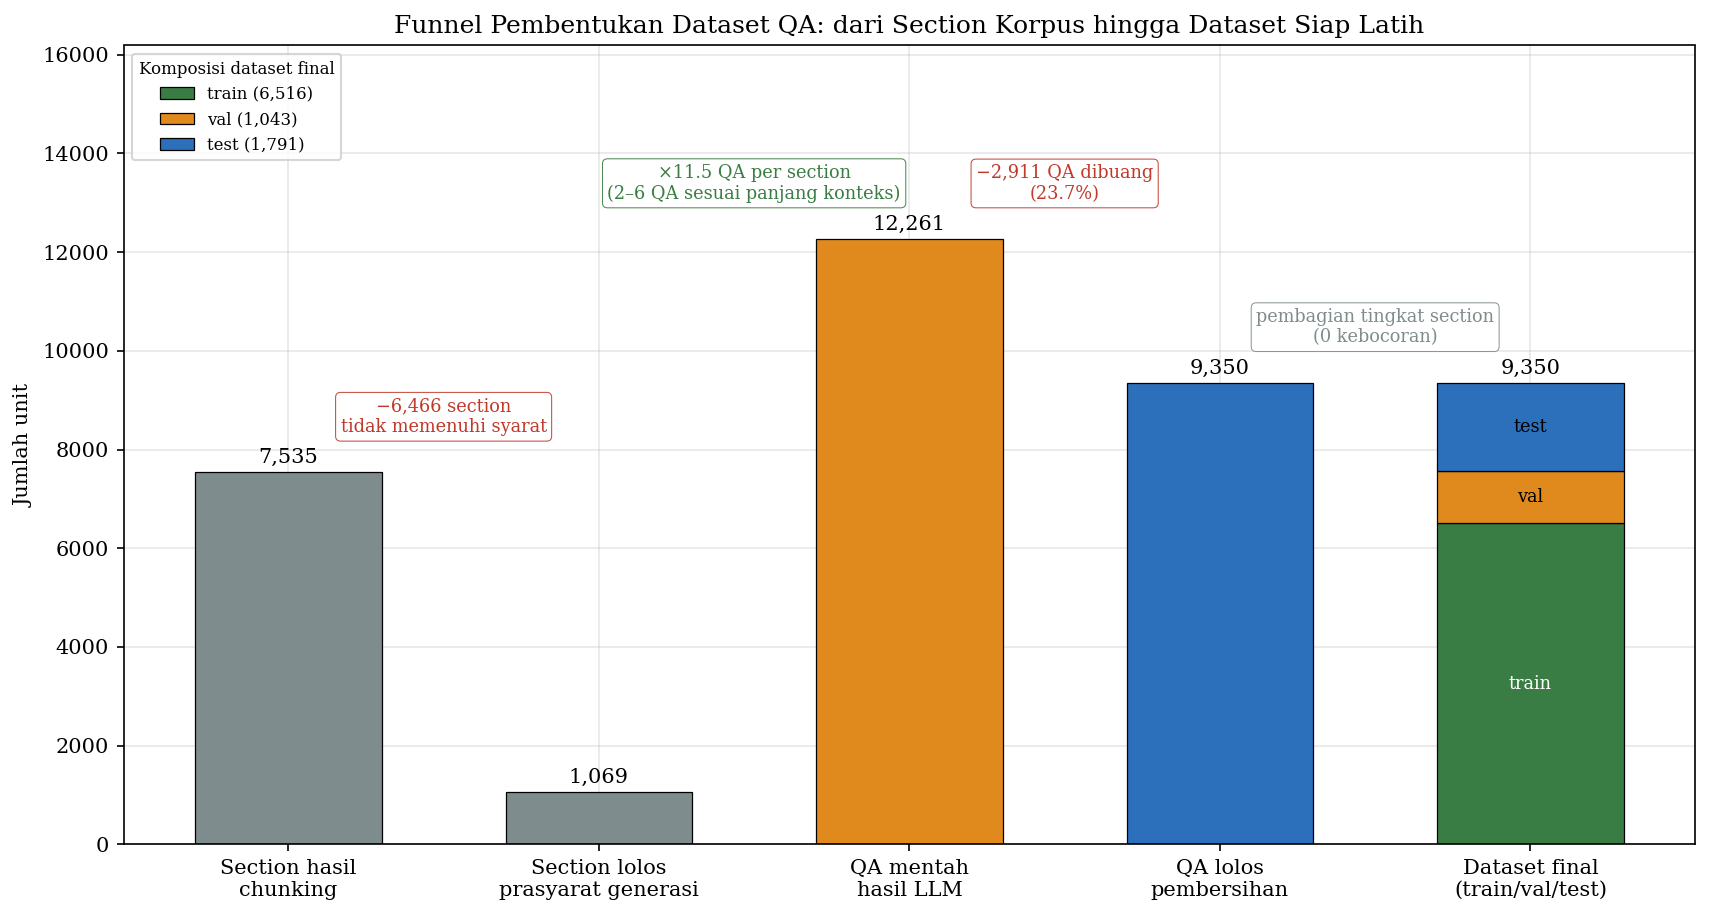

In [68]:
def fig13_funnel_dataset_qa():
    tahap = ["Section hasil\nchunking", "Section lolos\nprasyarat generasi", "QA mentah\nhasil LLM",
             "QA lolos\npembersihan", "Dataset final\n(train/val/test)"]
    nilai = [SECTIONS_RAW, SECTIONS_SELECTED, RAW_RECORDS, FILTERED_RECORDS, sum(SPLIT_COUNTS.values())]
    warna = [C_MUTED, C_MUTED, C_ACCENT, C_CLEAN, C_KEEP]
    x = np.arange(len(tahap))

    fig, ax = plt.subplots(figsize=(11.5, 6.2))
    ax.bar(x[:-1], nilai[:-1], color=warna[:-1], edgecolor="black", linewidth=.6, width=.6)
    bawah = 0
    for (nama_split, jumlah), warna_split in zip(SPLIT_COUNTS.items(), [C_KEEP, C_ACCENT, C_CLEAN]):
        ax.bar(x[-1], jumlah, bottom=bawah, color=warna_split, edgecolor="black",
               linewidth=.6, width=.6, label=f"{nama_split} ({jumlah:,})")
        ax.text(x[-1], bawah + jumlah / 2, nama_split, ha="center", va="center", fontsize=8.5,
                color="white" if nama_split == "train" else "black")
        bawah += jumlah
    for xi, v in zip(x, nilai):
        ax.text(xi, v + max(nilai) * .015, f"{v:,}", ha="center", fontsize=10)

    anotasi_funnel(ax, nilai, [
        (f"−{SECTIONS_RAW - SECTIONS_SELECTED:,} section\ntidak memenuhi syarat", C_DROP),
        (f"×{RAW_RECORDS / SECTIONS_SELECTED:.1f} QA per section\n(2–6 QA sesuai panjang konteks)", C_KEEP),
        (f"−{REMOVED_RECORDS:,} QA dibuang\n({100 * REMOVED_RECORDS / RAW_RECORDS:.1f}%)", C_DROP),
        (f"pembagian tingkat section\n({N_SECTION_BOCOR} kebocoran)", C_MUTED),
    ])

    ax.set_xticks(x); ax.set_xticklabels(tahap)
    ax.set_ylabel("Jumlah unit"); ax.set_ylim(0, max(nilai) * 1.32)
    ax.legend(fontsize=8, loc="upper left", title="Komposisi dataset final", title_fontsize=8)
    ax.set_title("Funnel Pembentukan Dataset QA: dari Section Korpus hingga Dataset Siap Latih")
    plt.tight_layout(); plt.savefig("fig13_funnel_dataset_qa.png", bbox_inches="tight"); plt.show()

fig13_funnel_dataset_qa()

### Gambar 14 — Penyaringan section sebelum generasi dan status parsing keluaran LLM
Dari 7.535 section, hanya 1.069 yang dipakai sebagai sumber generasi. Panel (b) menunjukkan bahwa keluaran LLM tidak selalu berupa JSON bersih — seperlima keluaran masih terbungkus penanda blok kode dan harus diperbaiki secara programatis.

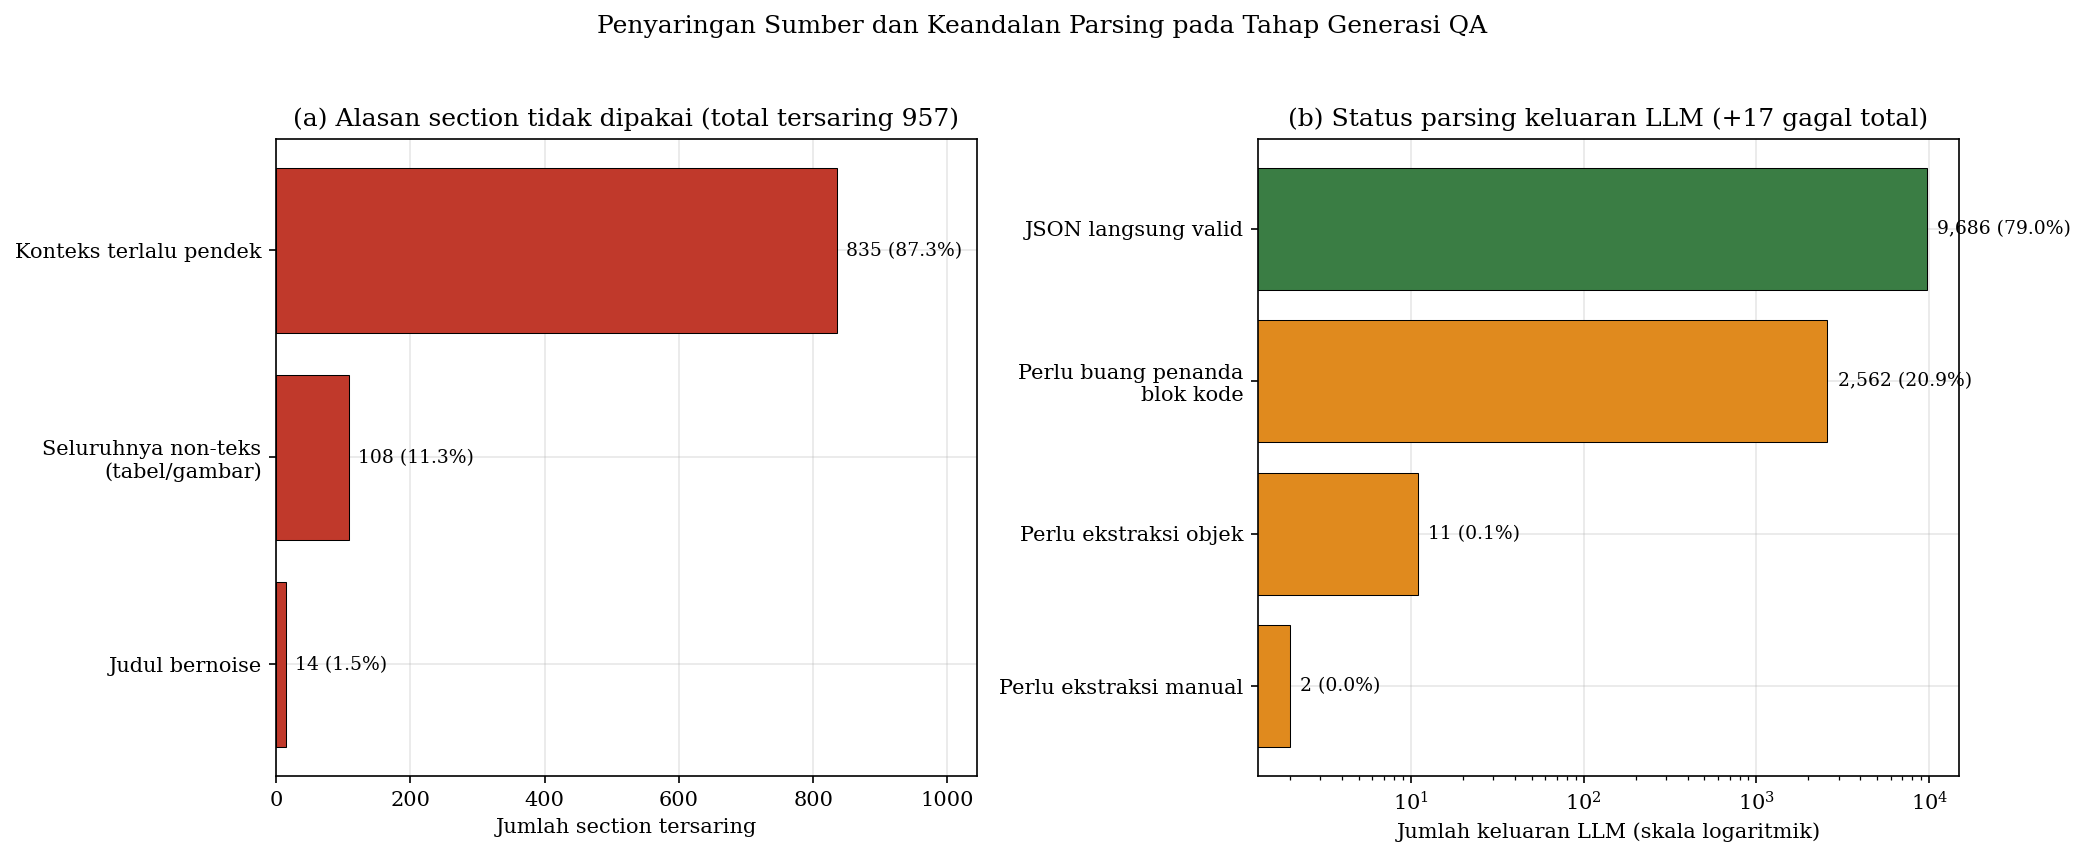

In [69]:
def fig14_penyaringan_dan_parsing():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

    ax = axes[0]
    ket = {"too_short": "Konteks terlalu pendek", "all_non_text": "Seluruhnya non-teks\n(tabel/gambar)",
           "noise_title": "Judul bernoise"}
    d = pd.Series(GEN_FILTER_SECTION).sort_values()
    total_filter = d.sum()
    ax.barh([ket[k] for k in d.index], d.values, color=C_DROP, edgecolor="black", linewidth=.5)
    for y, v in enumerate(d.values):
        ax.text(v + total_filter * .015, y, f"{v:,} ({100 * v / total_filter:.1f}%)", va="center", fontsize=9)
    ax.set_xlabel("Jumlah section tersaring")
    ax.set_xlim(0, d.max() * 1.25)
    ax.set_title(f"(a) Alasan section tidak dipakai (total tersaring {total_filter:,})")

    ax = axes[1]
    ket2 = {"direct": "JSON langsung valid", "fence_stripped": "Perlu buang penanda\nblok kode",
            "extracted_object_wrapped": "Perlu ekstraksi objek", "extracted": "Perlu ekstraksi manual"}
    d2 = pd.Series(PARSE_STATUS).sort_values()
    total_parse = d2.sum()
    warna = [C_KEEP if k == "direct" else C_ACCENT for k in d2.index]
    ax.barh([ket2[k] for k in d2.index], d2.values, color=warna, edgecolor="black", linewidth=.5)
    for y, v in enumerate(d2.values):
        ax.text(v * 1.15, y, f"{v:,} ({100 * v / total_parse:.1f}%)", va="center", fontsize=9)
    ax.set_xscale("log"); ax.set_xlabel("Jumlah keluaran LLM (skala logaritmik)")
    ax.set_title(f"(b) Status parsing keluaran LLM (+{GEN_FAILURES} gagal total)")

    fig.suptitle("Penyaringan Sumber dan Keandalan Parsing pada Tahap Generasi QA", y=1.03)
    plt.tight_layout(); plt.savefig("fig14_penyaringan_dan_parsing.png", bbox_inches="tight"); plt.show()

fig14_penyaringan_dan_parsing()

### Gambar 15 — Komposisi tipe pertanyaan pada dataset QA mentah

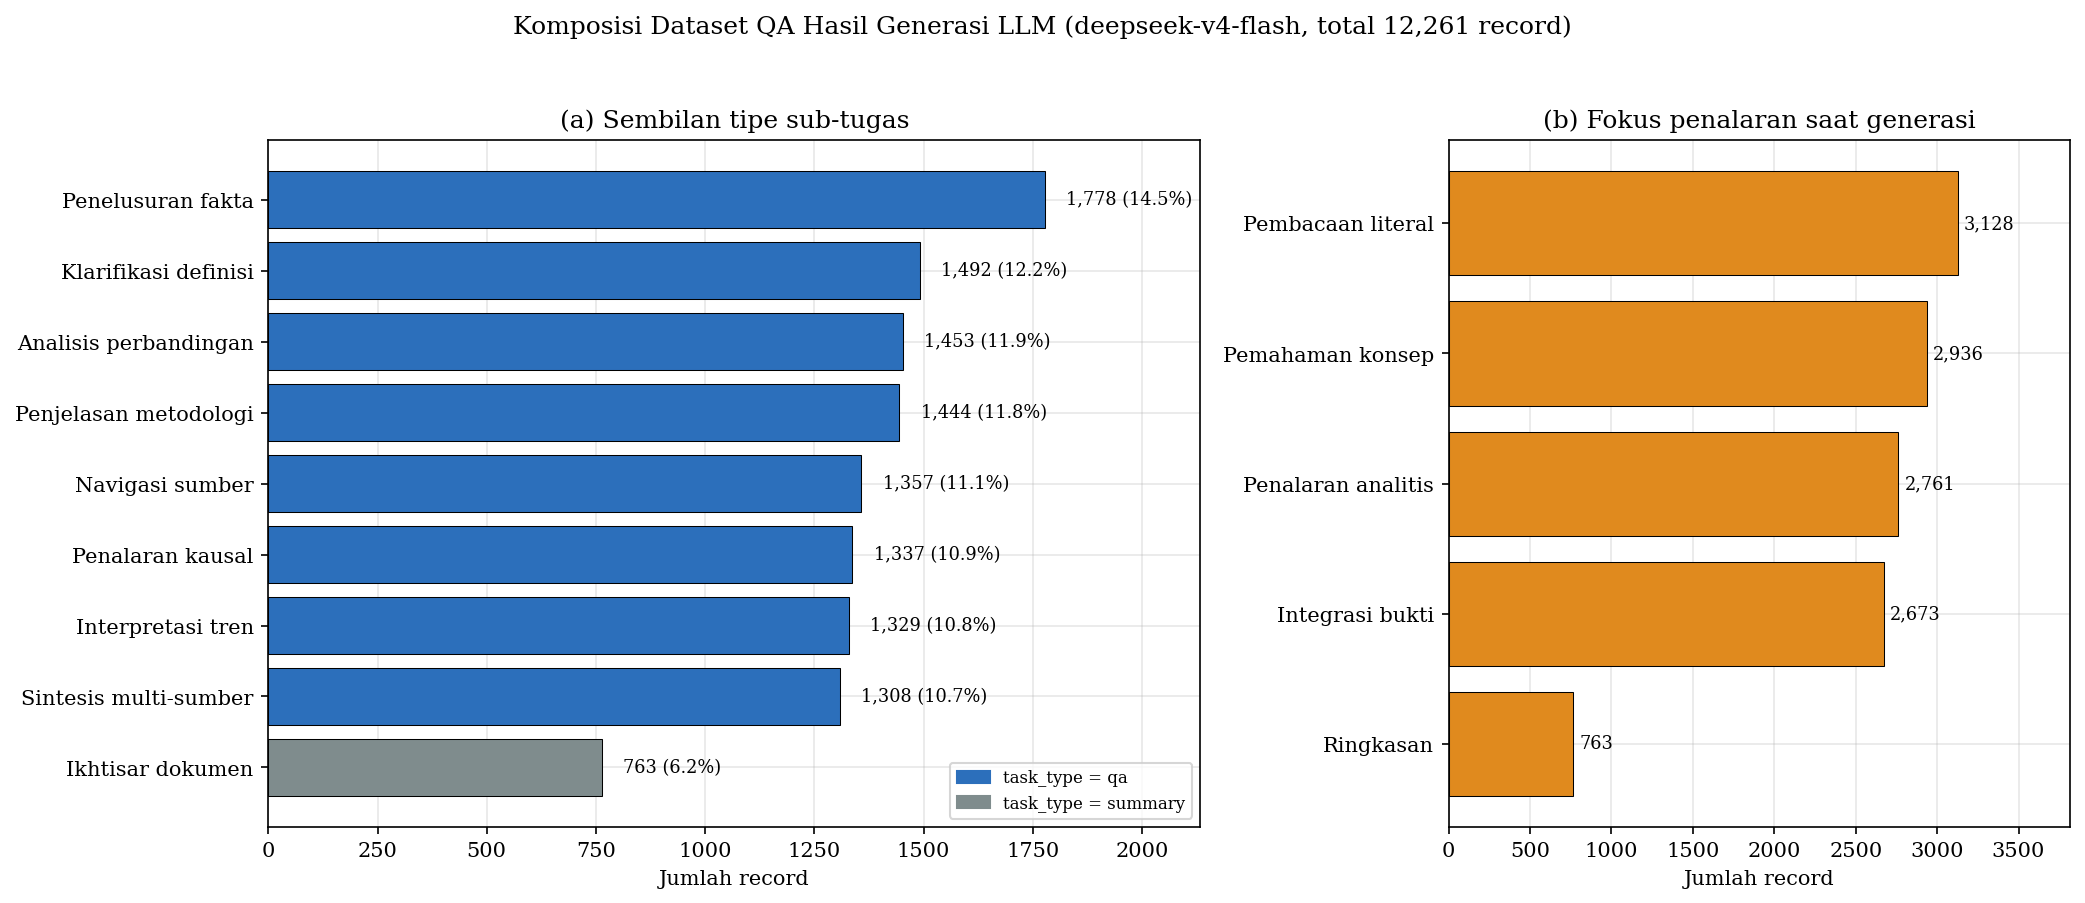

In [70]:
def fig15_komposisi_subtask():
    d = pd.Series(SUBTASK_RAW).sort_values()
    total = d.sum()
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.8), gridspec_kw={"width_ratios": [1.5, 1]})

    ax = axes[0]
    warna = [C_MUTED if k == "document_overview" else C_CLEAN for k in d.index]
    ax.barh([SUBTASK_LABEL[k] for k in d.index], d.values, color=warna, edgecolor="black", linewidth=.5)
    for y, v in enumerate(d.values):
        ax.text(v + total * .004, y, f"{v:,} ({100 * v / total:.1f}%)", va="center", fontsize=8.5)
    ax.set_xlabel("Jumlah record"); ax.set_xlim(0, d.max() * 1.2)
    ax.set_title("(a) Sembilan tipe sub-tugas")
    ax.legend(handles=[Patch(color=C_CLEAN, label="task_type = qa"),
                       Patch(color=C_MUTED, label="task_type = summary")], fontsize=8, loc="lower right")

    ax = axes[1]
    d2 = pd.Series(GENERATION_FOCUS).sort_values()
    ket = {"literal_reading": "Pembacaan literal", "concept_understanding": "Pemahaman konsep",
           "analytical_reasoning": "Penalaran analitis", "evidence_integration": "Integrasi bukti",
           "summary": "Ringkasan"}
    ax.barh([ket[k] for k in d2.index], d2.values, color=C_ACCENT, edgecolor="black", linewidth=.5)
    for y, v in enumerate(d2.values):
        ax.text(v + d2.max() * .012, y, f"{v:,}", va="center", fontsize=8.5)
    ax.set_xlabel("Jumlah record"); ax.set_xlim(0, d2.max() * 1.22)
    ax.set_title("(b) Fokus penalaran saat generasi")

    fig.suptitle(f"Komposisi Dataset QA Hasil Generasi LLM ({GEN_LLM}, total {total:,} record)", y=1.03)
    plt.tight_layout(); plt.savefig("fig15_komposisi_subtask.png", bbox_inches="tight"); plt.show()

fig15_komposisi_subtask()

### Gambar 16 — Cakupan korpus oleh dataset QA: keterbatasan yang perlu dilaporkan
Proses generasi terhenti sebelum seluruh korpus terproses karena kuota API generator habis. Akibatnya hanya 29 dari 47 dokumen yang terwakili, dengan konsentrasi record yang timpang antar dokumen. Keterbatasan ini dilaporkan terbuka sebagai batas generalisasi penelitian.

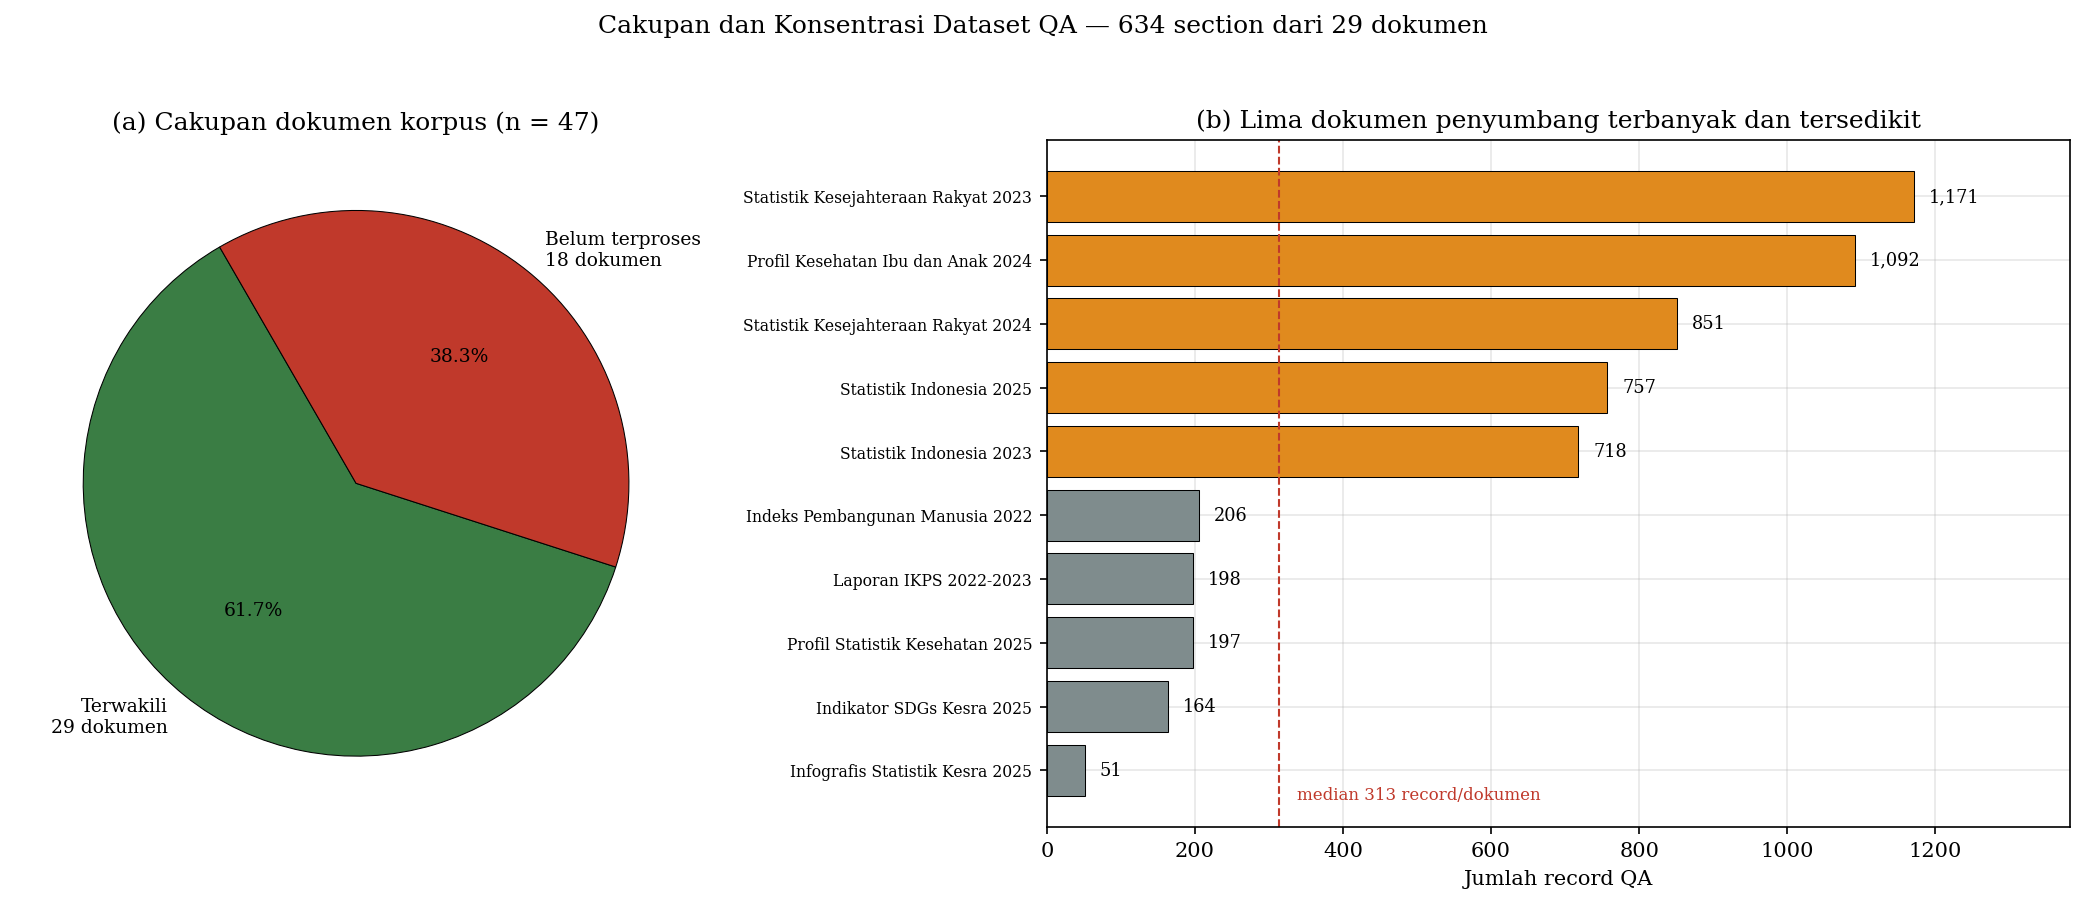

In [71]:
def fig16_cakupan_korpus():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.8), gridspec_kw={"width_ratios": [1, 1.5]})

    ax = axes[0]
    n_total_dok = len(df_clean)
    terwakili, tidak = DOK_UNIK, n_total_dok - DOK_UNIK
    ax.pie([terwakili, tidak],
           labels=[f"Terwakili\n{terwakili} dokumen", f"Belum terproses\n{tidak} dokumen"],
           colors=[C_KEEP, C_DROP], startangle=120, autopct="%1.1f%%",
           wedgeprops={"edgecolor": "black", "linewidth": .5}, textprops={"fontsize": 9})
    ax.set_title(f"(a) Cakupan dokumen korpus (n = {n_total_dok})")
    ax.grid(False)

    ax = axes[1]
    gabungan = {**TOP_DOKUMEN, **BOTTOM_DOKUMEN}
    d = pd.Series(gabungan).sort_values()
    warna = [C_ACCENT if v >= REC_PER_DOK["median"] else C_MUTED for v in d.values]
    ax.barh([label_pendek(k, 36) for k in d.index], d.values, color=warna, edgecolor="black", linewidth=.5)
    for y, v in enumerate(d.values):
        ax.text(v + 20, y, f"{v:,}", va="center", fontsize=8.5)
    ax.axvline(REC_PER_DOK["median"], ls="--", color=C_DROP, lw=1)
    ax.text(REC_PER_DOK["median"] + 25, -0.45, f"median {REC_PER_DOK['median']} record/dokumen",
            color=C_DROP, fontsize=8)
    ax.set_xlabel("Jumlah record QA"); ax.tick_params(axis="y", labelsize=7.5)
    ax.set_xlim(0, d.max() * 1.18)
    ax.set_title("(b) Lima dokumen penyumbang terbanyak dan tersedikit")

    fig.suptitle(f"Cakupan dan Konsentrasi Dataset QA — {SECTION_UNIK} section dari {DOK_UNIK} dokumen", y=1.03)
    plt.tight_layout(); plt.savefig("fig16_cakupan_korpus.png", bbox_inches="tight"); plt.show()

fig16_cakupan_korpus()

### Gambar 17 — Biaya komputasi generasi: penggunaan token LLM

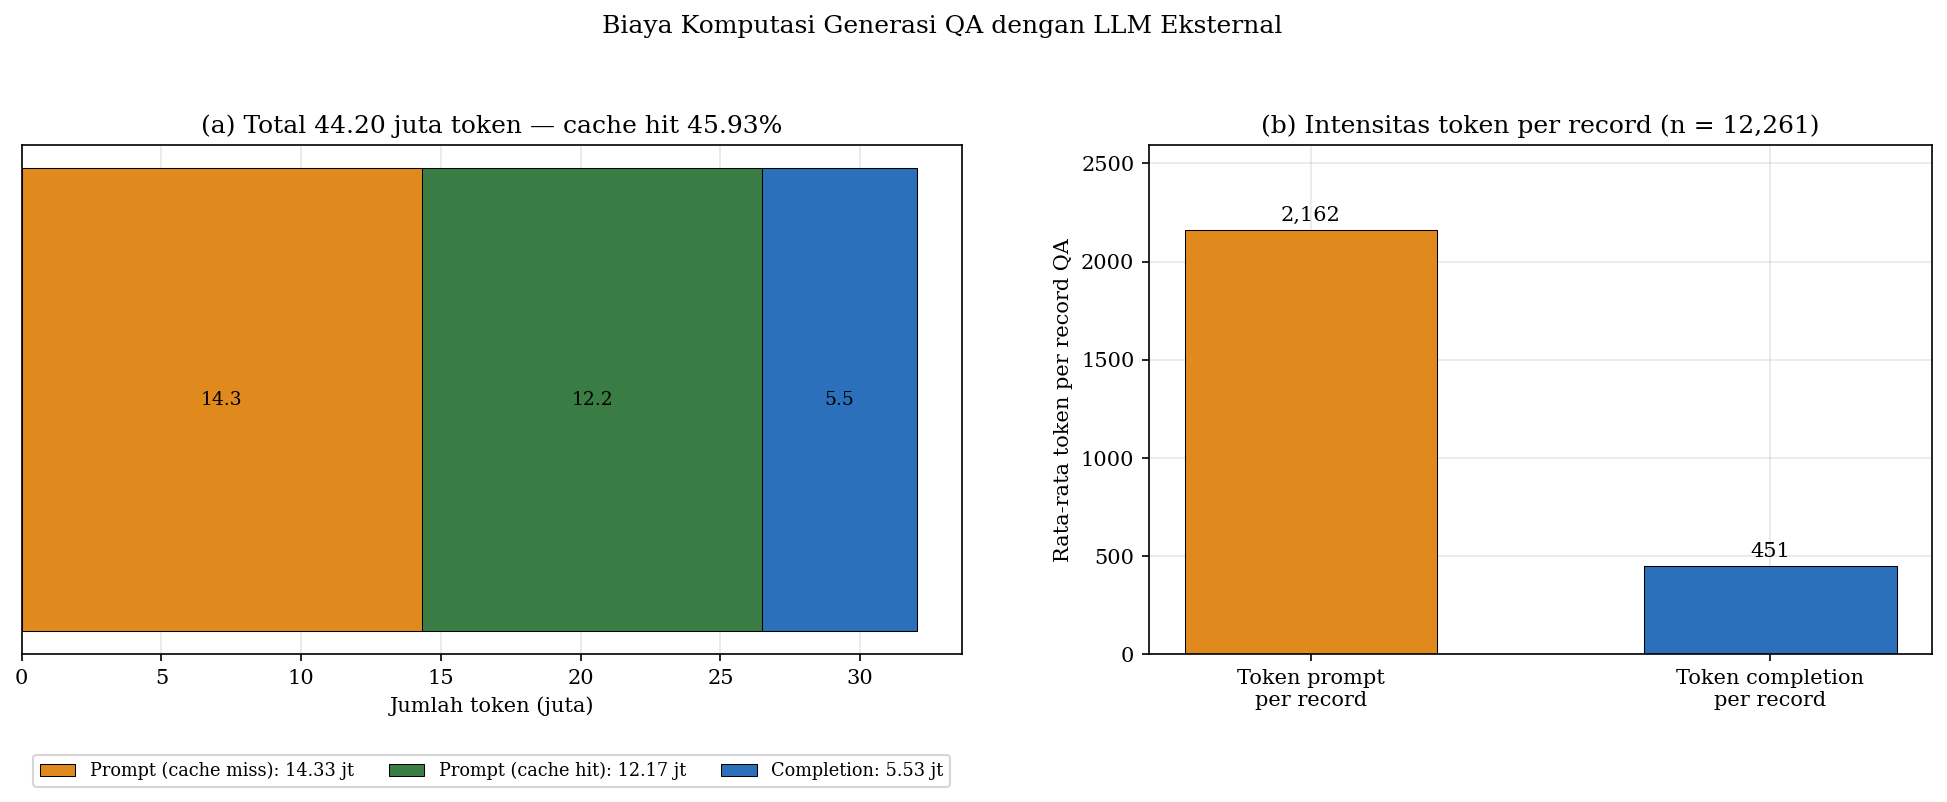

In [72]:
def fig17_biaya_token():
    fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2), gridspec_kw={"width_ratios": [1.2, 1]})

    ax = axes[0]
    prompt_baru = TOKEN_USAGE["prompt"] - TOKEN_USAGE["cached"]
    bagian = [("Prompt (cache miss)", prompt_baru, C_ACCENT),
              ("Prompt (cache hit)", TOKEN_USAGE["cached"], C_KEEP),
              ("Completion", TOKEN_USAGE["completion"], C_CLEAN)]
    kiri = 0
    for nama, nilai, warna in bagian:
        ax.barh([0], [nilai / 1e6], left=kiri / 1e6, color=warna, edgecolor="black",
                linewidth=.5, label=f"{nama}: {nilai / 1e6:.2f} jt")
        ax.text((kiri + nilai / 2) / 1e6, 0, f"{nilai / 1e6:.1f}", ha="center", va="center", fontsize=9)
        kiri += nilai
    ax.set_yticks([]); ax.set_xlabel("Jumlah token (juta)")
    ax.set_title(f"(a) Total {sum(TOKEN_USAGE.values()) / 1e6:.2f} juta token "
                 f"— cache hit {CACHE_HIT_RATE}%")
    ax.legend(fontsize=8.5, loc="upper center", bbox_to_anchor=(.5, -.18), ncol=3)

    ax = axes[1]
    rasio = {"Token prompt\nper record": TOKEN_USAGE["prompt"] / RAW_RECORDS,
             "Token completion\nper record": TOKEN_USAGE["completion"] / RAW_RECORDS}
    ax.bar(list(rasio.keys()), list(rasio.values()), color=[C_ACCENT, C_CLEAN],
           edgecolor="black", linewidth=.5, width=.55)
    for i, v in enumerate(rasio.values()):
        ax.text(i, v + 45, f"{v:,.0f}", ha="center", fontsize=10)
    ax.set_ylabel("Rata-rata token per record QA")
    ax.set_ylim(0, max(rasio.values()) * 1.2)
    ax.set_title(f"(b) Intensitas token per record (n = {RAW_RECORDS:,})")

    fig.suptitle("Biaya Komputasi Generasi QA dengan LLM Eksternal", y=1.04)
    plt.tight_layout(); plt.savefig("fig17_biaya_token.png", bbox_inches="tight"); plt.show()

fig17_biaya_token()

### Gambar 18 — Distribusi panjang pertanyaan, jawaban, dan rantai penalaran

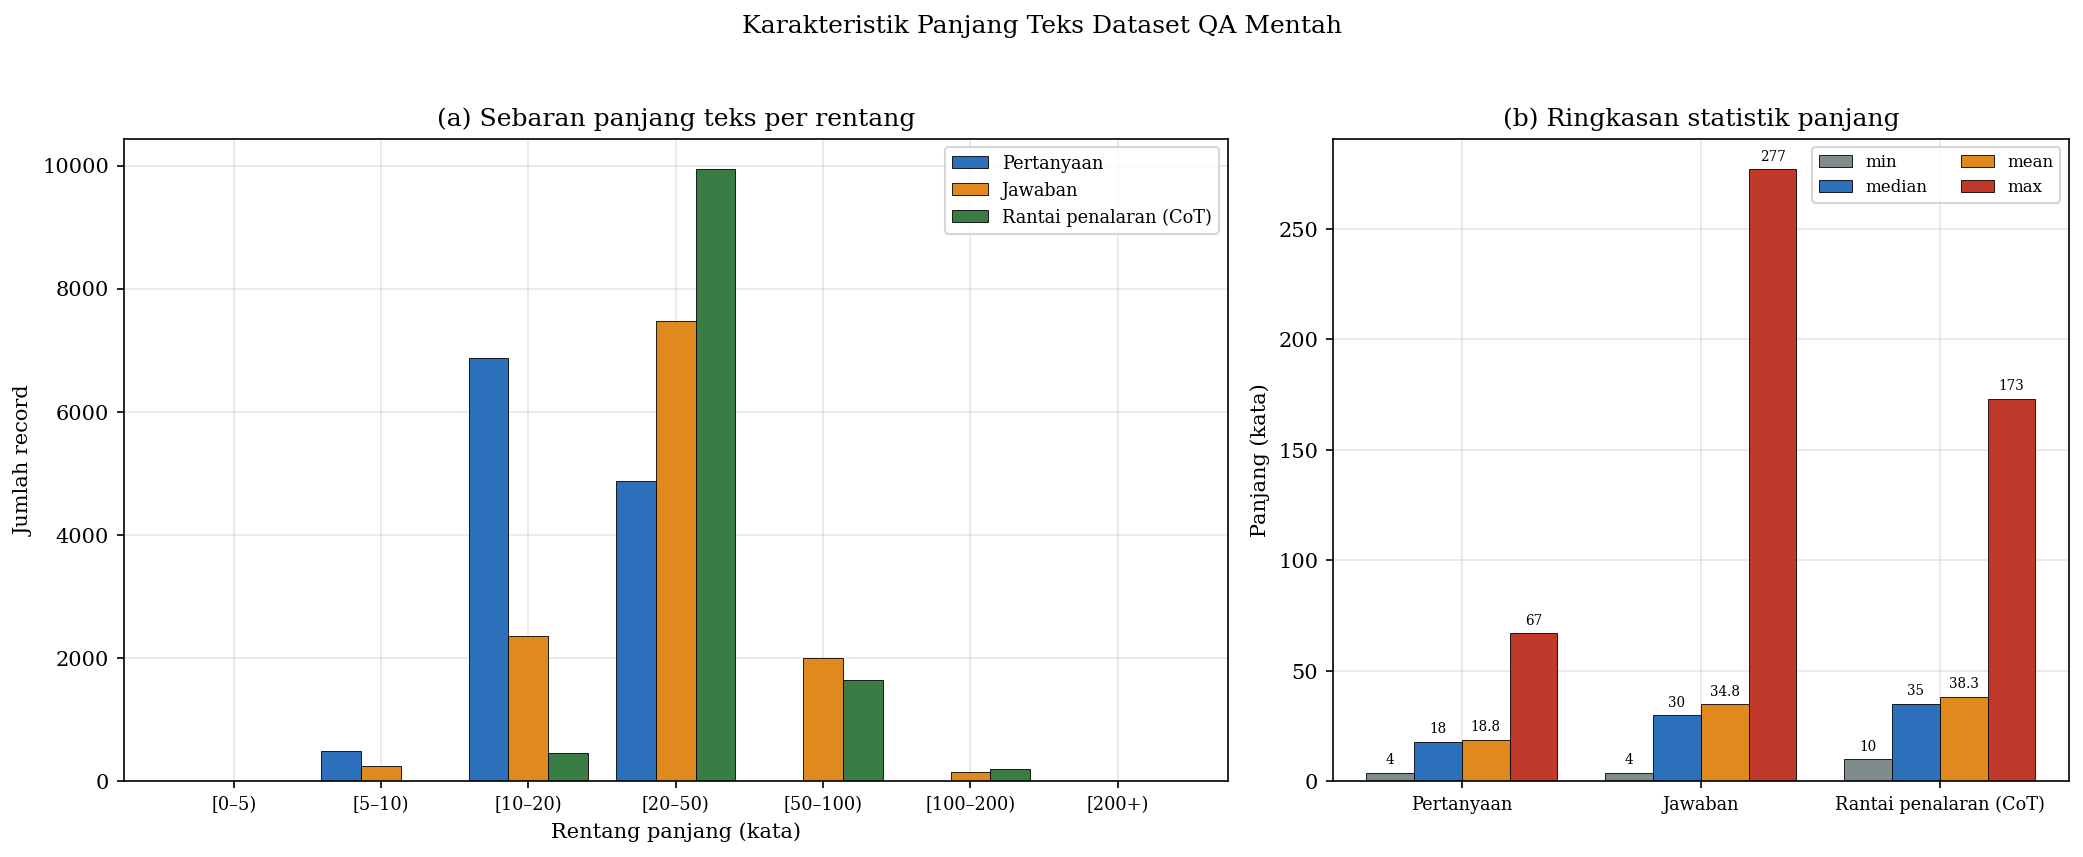

In [73]:
def fig18_panjang_teks():
    bucket_urut = ["[0–5)", "[5–10)", "[10–20)", "[20–50)", "[50–100)", "[100–200)", "[200+)"]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), gridspec_kw={"width_ratios": [1.5, 1]})

    ax = axes[0]
    x = np.arange(len(bucket_urut)); w = 0.27
    warna_field = {"Instruction": C_CLEAN, "Response": C_ACCENT, "CoT": C_KEEP}
    label_field = {"Instruction": "Pertanyaan", "Response": "Jawaban", "CoT": "Rantai penalaran (CoT)"}
    for i, (field, warna) in enumerate(warna_field.items()):
        nilai = [BUCKET_PANJANG[field].get(b, 0) for b in bucket_urut]
        ax.bar(x + (i - 1) * w, nilai, w, color=warna, edgecolor="black",
               linewidth=.4, label=label_field[field])
    ax.set_xticks(x); ax.set_xticklabels(bucket_urut, fontsize=8.5)
    ax.set_xlabel("Rentang panjang (kata)"); ax.set_ylabel("Jumlah record")
    ax.set_title("(a) Sebaran panjang teks per rentang"); ax.legend(fontsize=8.5)

    ax = axes[1]
    x2 = np.arange(len(PANJANG_STAT)); w2 = 0.2
    for i, (kol, warna) in enumerate([("min", C_MUTED), ("median", C_CLEAN),
                                      ("mean", C_ACCENT), ("max", C_DROP)]):
        ax.bar(x2 + (i - 1.5) * w2, PANJANG_STAT[kol], w2, color=warna,
               edgecolor="black", linewidth=.4, label=kol)
        for xi, v in zip(x2 + (i - 1.5) * w2, PANJANG_STAT[kol]):
            ax.text(xi, v + 4, f"{v:g}", ha="center", fontsize=6.5)
    ax.set_xticks(x2); ax.set_xticklabels([label_field[f] for f in PANJANG_STAT.index], fontsize=8.5)
    ax.set_ylabel("Panjang (kata)"); ax.legend(fontsize=8, ncol=2)
    ax.set_title("(b) Ringkasan statistik panjang")

    fig.suptitle("Karakteristik Panjang Teks Dataset QA Mentah", y=1.03)
    plt.tight_layout(); plt.savefig("fig18_panjang_teks.png", bbox_inches="tight"); plt.show()

fig18_panjang_teks()

### Gambar 19 — Temuan masalah kualitas pada tahap eksplorasi
Tahap eksplorasi berfungsi mengidentifikasi seluruh potensi cacat sebelum menentukan aturan pembersihan. Sebagian temuan bersifat berat (mis. residu notasi tabel) dan dijadikan dasar pembuangan, sebagian lain bersifat penanda (mis. CoT tanpa kutipan literal) yang dicatat tetapi tidak otomatis menggugurkan record.

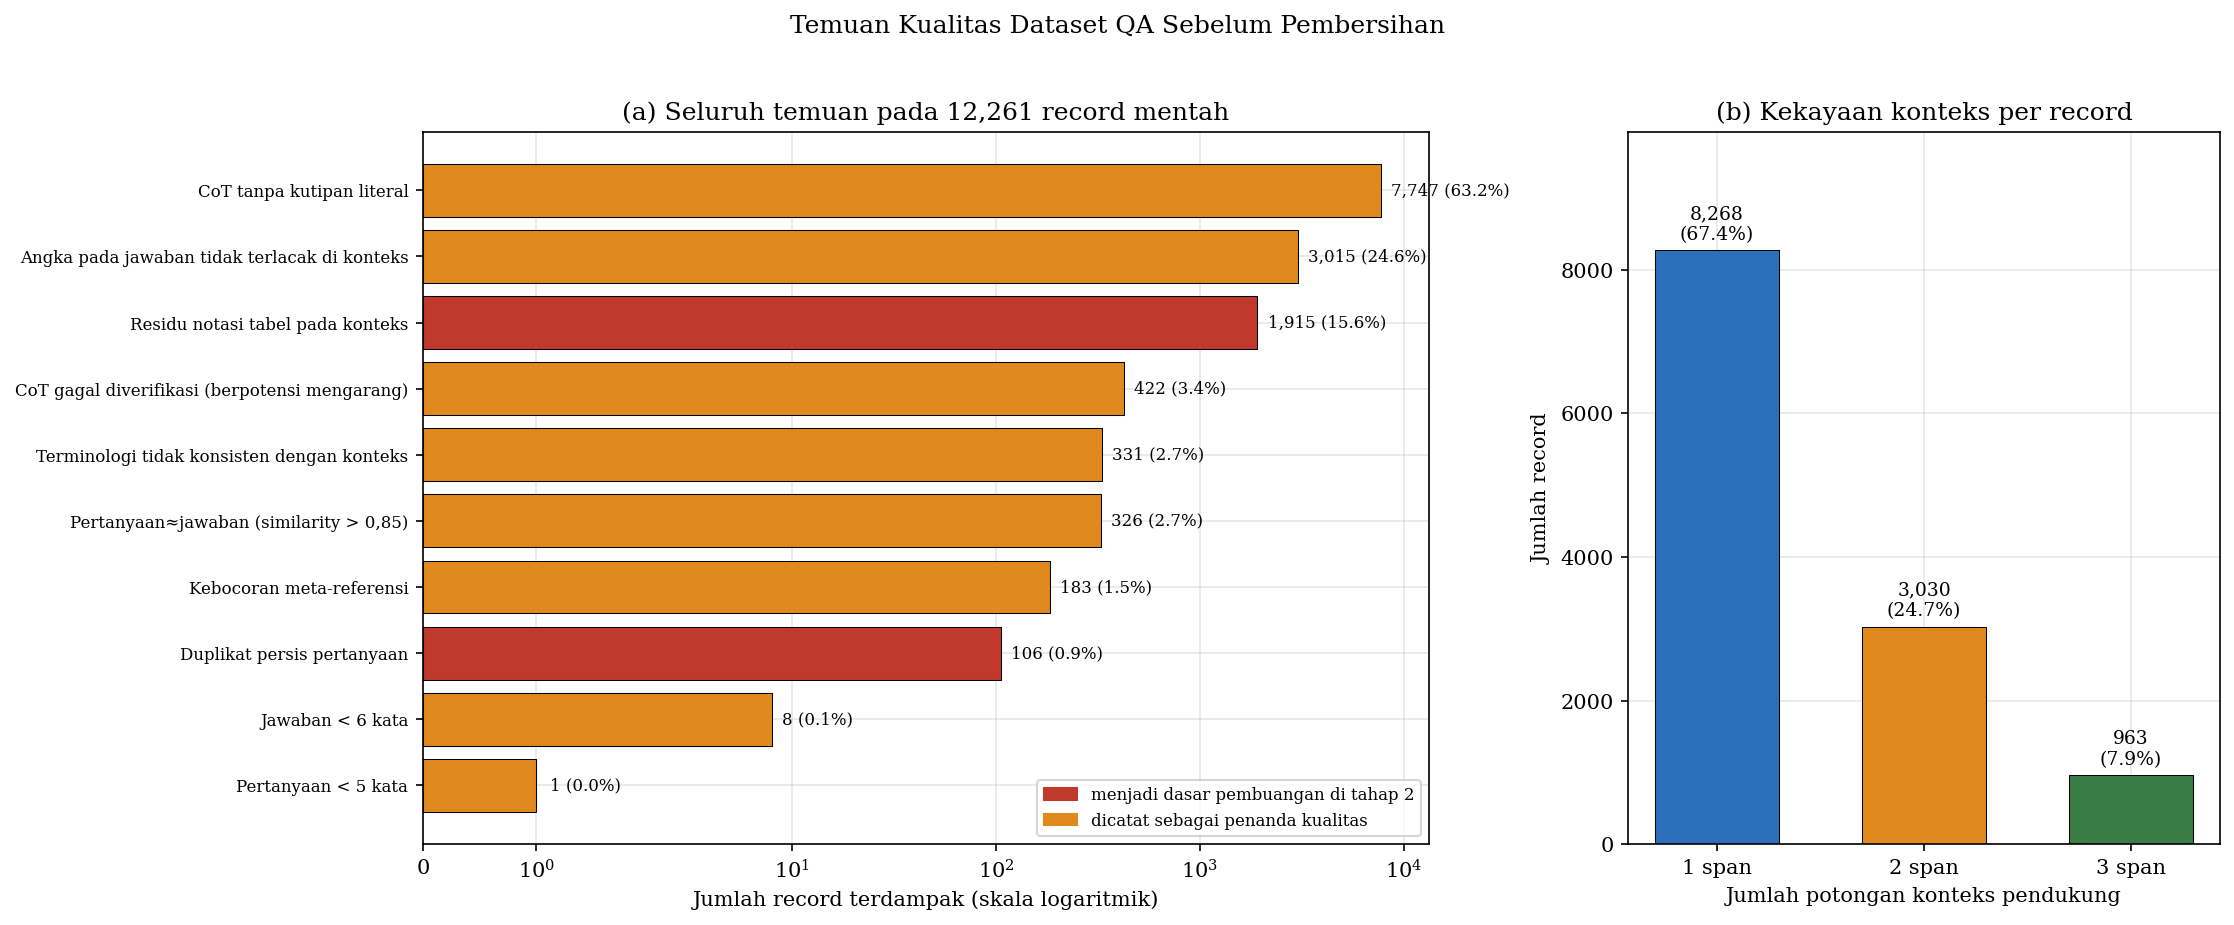

In [74]:
def fig19_temuan_kualitas():
    fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [1.7, 1]})

    ax = axes[0]
    d = pd.Series(TEMUAN_KUALITAS).sort_values()
    jadi_gate = {"Residu notasi tabel pada konteks", "Duplikat persis pertanyaan"}
    warna = [C_DROP if k in jadi_gate else C_ACCENT for k in d.index]
    ax.barh(d.index, d.values, color=warna, edgecolor="black", linewidth=.5)
    for y, v in enumerate(d.values):
        ax.text(v * 1.12, y, f"{v:,} ({100 * v / RAW_RECORDS:.1f}%)", va="center", fontsize=8)
    ax.set_xscale("symlog"); ax.set_xlabel("Jumlah record terdampak (skala logaritmik)")
    ax.tick_params(axis="y", labelsize=8)
    ax.set_title(f"(a) Seluruh temuan pada {RAW_RECORDS:,} record mentah")
    ax.legend(handles=[Patch(color=C_DROP, label="menjadi dasar pembuangan di tahap 2"),
                       Patch(color=C_ACCENT, label="dicatat sebagai penanda kualitas")],
              fontsize=8, loc="lower right")

    ax = axes[1]
    d2 = pd.Series(CONTEXT_SPANS)
    ax.bar(d2.index, d2.values, color=[C_CLEAN, C_ACCENT, C_KEEP], edgecolor="black", linewidth=.5, width=.6)
    for i, v in enumerate(d2.values):
        ax.text(i, v + RAW_RECORDS * .012, f"{v:,}\n({100 * v / d2.sum():.1f}%)", ha="center", fontsize=9)
    ax.set_ylabel("Jumlah record"); ax.set_ylim(0, d2.max() * 1.2)
    ax.set_xlabel("Jumlah potongan konteks pendukung")
    ax.set_title("(b) Kekayaan konteks per record")

    fig.suptitle("Temuan Kualitas Dataset QA Sebelum Pembersihan", y=1.02)
    plt.tight_layout(); plt.savefig("fig19_temuan_kualitas.png", bbox_inches="tight"); plt.show()

fig19_temuan_kualitas()

### Gambar 20 — Pembersihan bertingkat: berapa yang terbuang dan mengapa

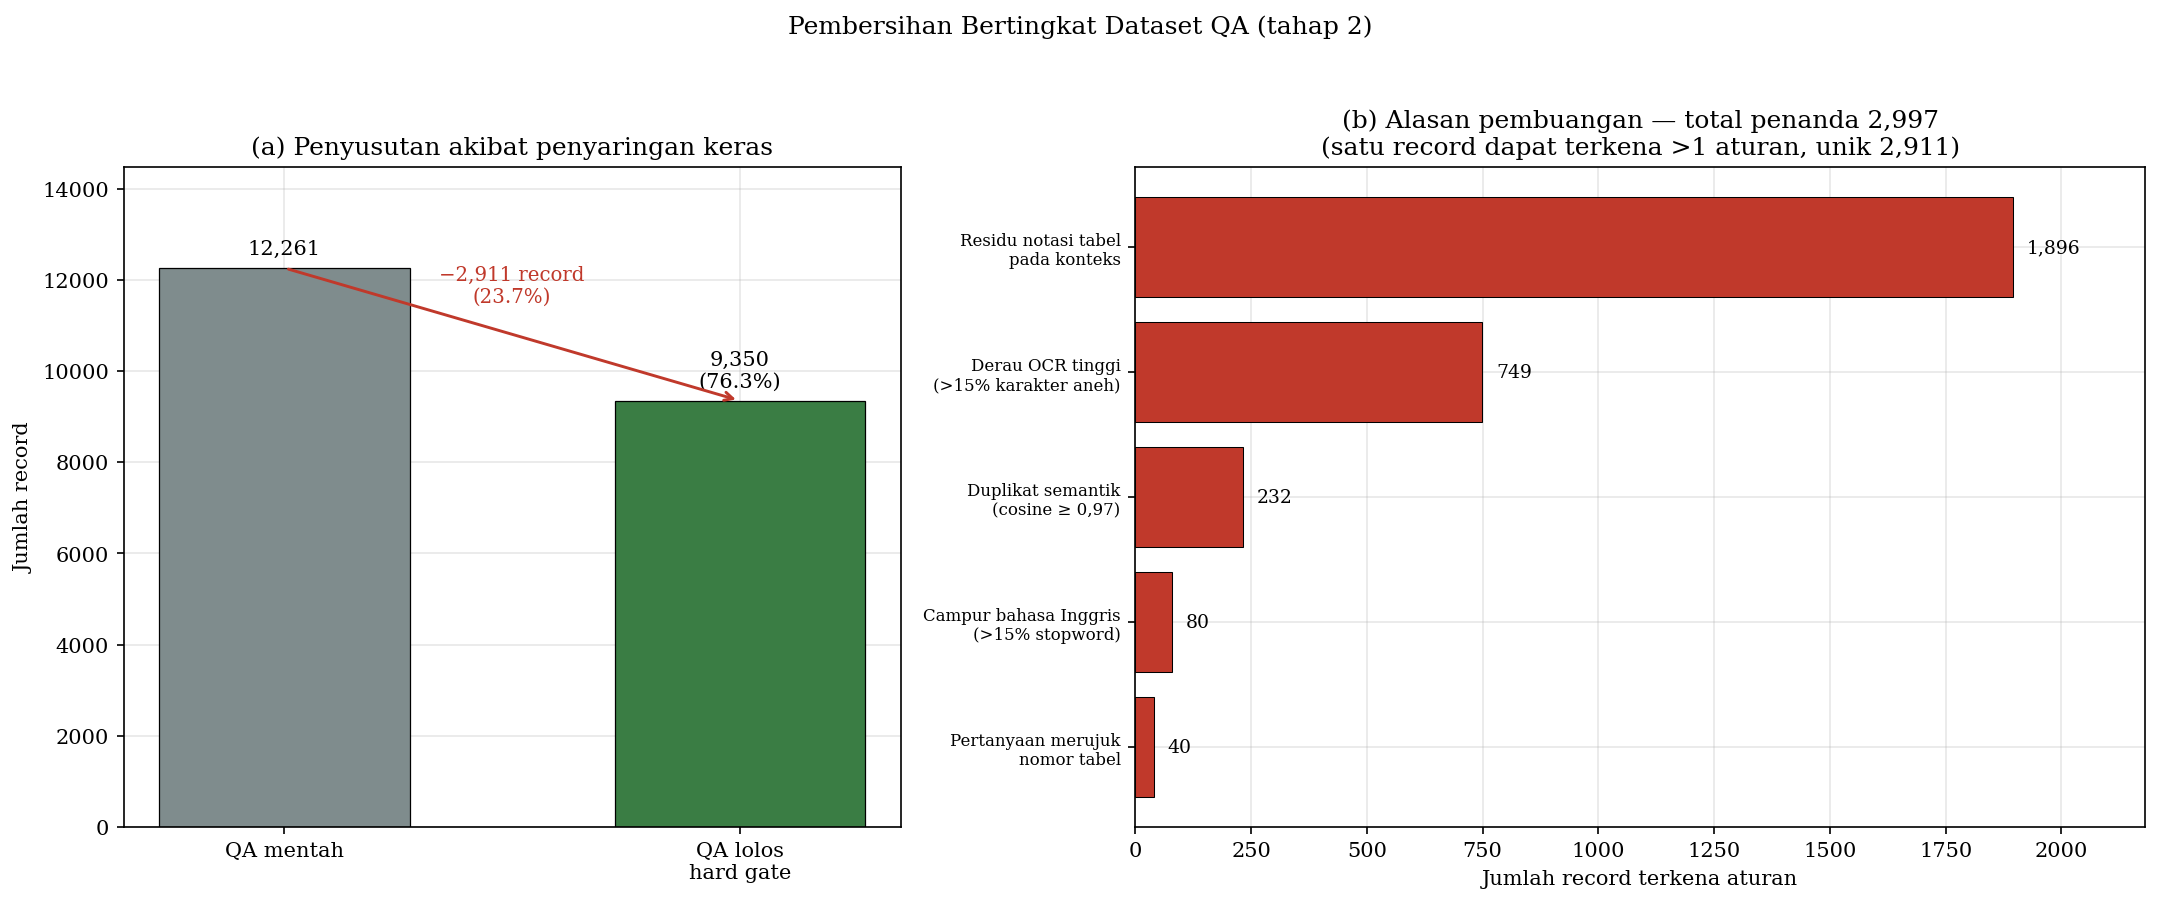

In [75]:
def fig20_funnel_pembersihan():
    fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.8), gridspec_kw={"width_ratios": [1, 1.3]})

    ax = axes[0]
    ax.bar(["QA mentah", "QA lolos\nhard gate"], [RAW_RECORDS, FILTERED_RECORDS],
           color=[C_MUTED, C_KEEP], edgecolor="black", linewidth=.6, width=.55)
    ax.text(0, RAW_RECORDS + 300, f"{RAW_RECORDS:,}", ha="center", fontsize=10)
    ax.text(1, FILTERED_RECORDS + 300, f"{FILTERED_RECORDS:,}\n({100 * FILTERED_RECORDS / RAW_RECORDS:.1f}%)",
            ha="center", fontsize=10)
    ax.annotate("", xy=(1, FILTERED_RECORDS), xytext=(0, RAW_RECORDS),
                arrowprops=dict(arrowstyle="->", color=C_DROP, lw=1.4))
    ax.text(.5, (RAW_RECORDS + FILTERED_RECORDS) / 2 + 700,
            f"−{REMOVED_RECORDS:,} record\n({100 * REMOVED_RECORDS / RAW_RECORDS:.1f}%)",
            ha="center", fontsize=9.5, color=C_DROP)
    ax.set_ylabel("Jumlah record"); ax.set_ylim(0, RAW_RECORDS * 1.18)
    ax.set_title("(a) Penyusutan akibat penyaringan keras")

    ax = axes[1]
    ket = {"table_residue": "Residu notasi tabel\npada konteks",
           "high_ocr_noise": "Derau OCR tinggi\n(>15% karakter aneh)",
           "near_duplicate": "Duplikat semantik\n(cosine ≥ 0,97)",
           "mixed_english_detected": "Campur bahasa Inggris\n(>15% stopword)",
           "table_ref_instruction": "Pertanyaan merujuk\nnomor tabel"}
    d = pd.Series(REMOVAL_REASONS).sort_values()
    ax.barh([ket[k] for k in d.index], d.values, color=C_DROP, edgecolor="black", linewidth=.5)
    for y, v in enumerate(d.values):
        ax.text(v + 30, y, f"{v:,}", va="center", fontsize=9)
    ax.set_xlabel("Jumlah record terkena aturan")
    ax.set_xlim(0, d.max() * 1.15); ax.tick_params(axis="y", labelsize=8)
    ax.set_title(f"(b) Alasan pembuangan — total penanda {sum(REMOVAL_REASONS.values()):,}\n"
                 f"(satu record dapat terkena >1 aturan, unik {REMOVED_RECORDS:,})")

    fig.suptitle("Pembersihan Bertingkat Dataset QA (tahap 2)", y=1.03)
    plt.tight_layout(); plt.savefig("fig20_funnel_pembersihan.png", bbox_inches="tight"); plt.show()

fig20_funnel_pembersihan()

### Gambar 21 — Skor kualitas komposit (`track_a_score`) per tipe sub-tugas
`track_a_score` menggabungkan empat komponen dengan bobot berbeda; komponen terbesar adalah keterlacakan angka jawaban terhadap konteks — dimensi paling kritis untuk domain statistik resmi.

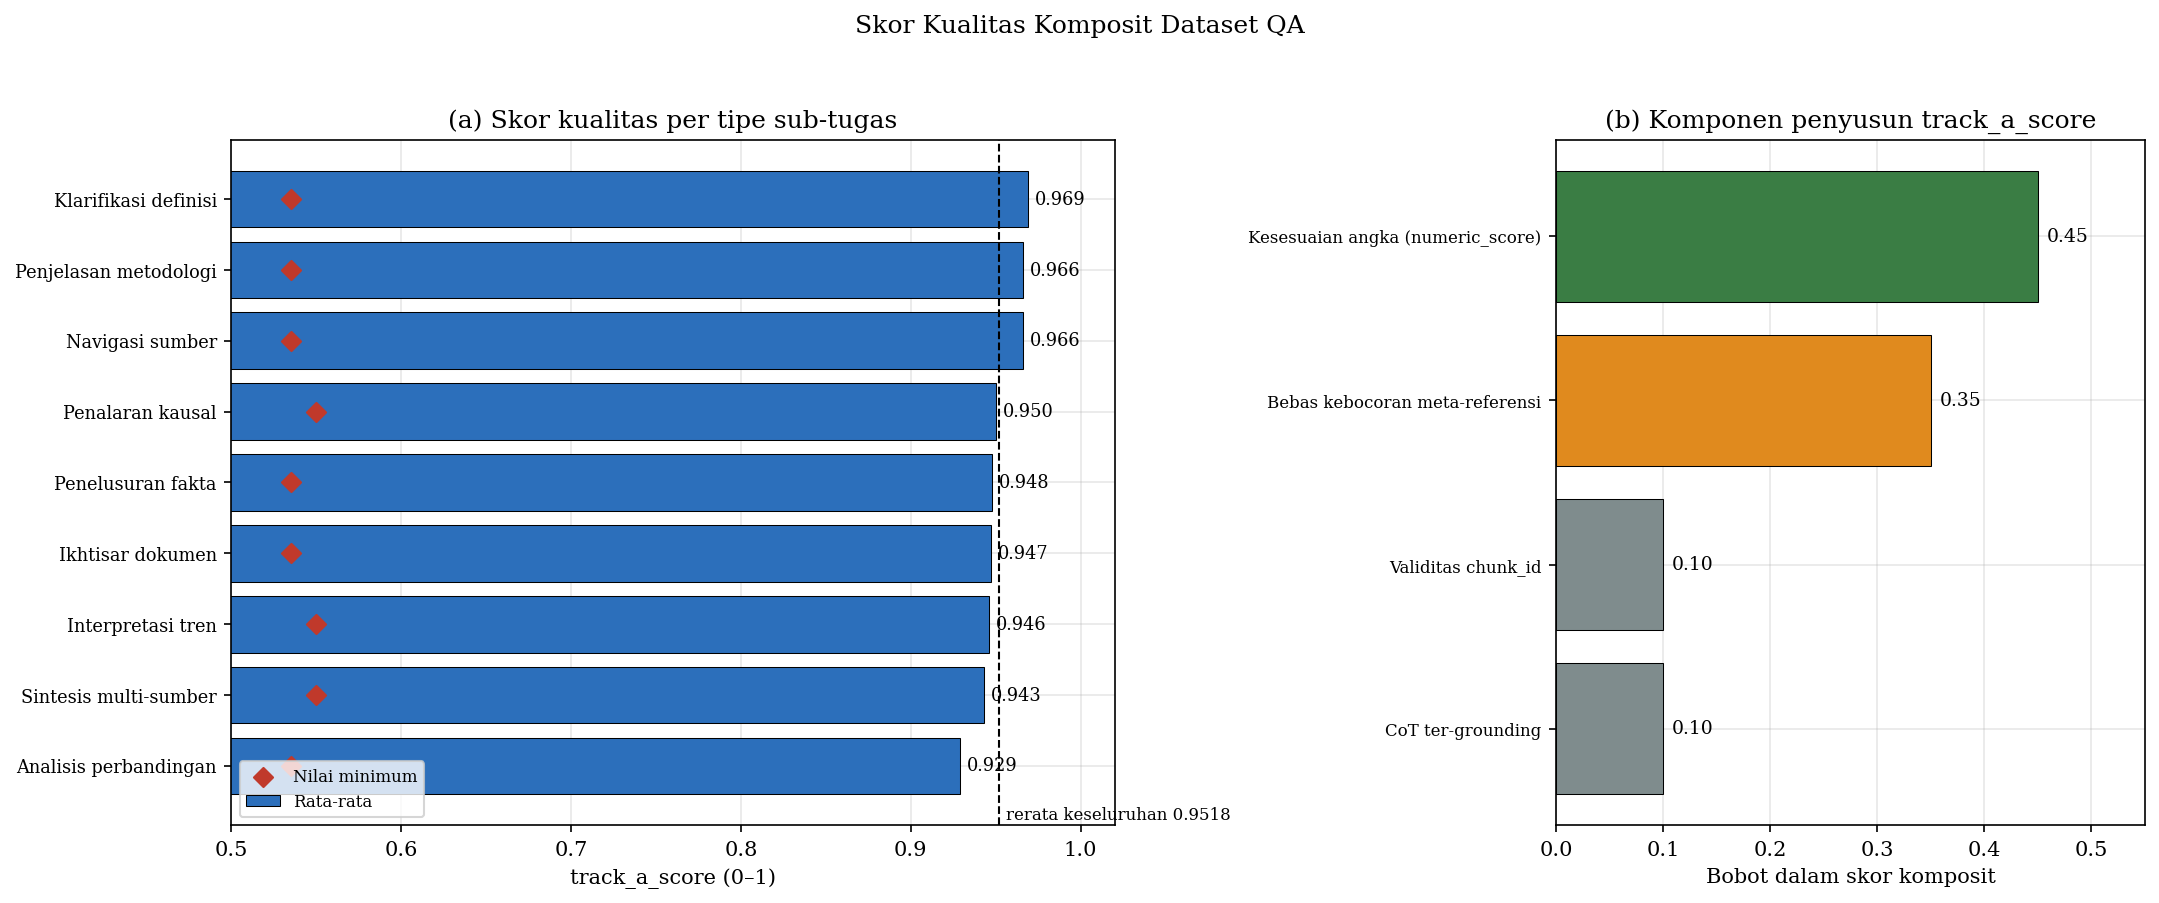

In [76]:
def fig21_skor_kualitas():
    fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.8), gridspec_kw={"width_ratios": [1.5, 1]})

    ax = axes[0]
    d = TRACK_A_SUBTASK.sort_values("mean")
    y = np.arange(len(d))
    ax.barh(y, d["mean"], color=C_CLEAN, edgecolor="black", linewidth=.5, label="Rata-rata")
    ax.scatter(d["min"], y, color=C_DROP, s=42, zorder=3, marker="D", label="Nilai minimum")
    for yi, v in zip(y, d["mean"]):
        ax.text(v + .004, yi, f"{v:.3f}", va="center", fontsize=8.5)
    ax.axvline(TRACK_A_MEAN_ALL, ls="--", color="black", lw=1)
    ax.text(TRACK_A_MEAN_ALL + .004, -.75, f"rerata keseluruhan {TRACK_A_MEAN_ALL:.4f}", fontsize=8)
    ax.set_yticks(y); ax.set_yticklabels([SUBTASK_LABEL[k] for k in d.index], fontsize=8.5)
    ax.set_xlim(.5, 1.02); ax.set_xlabel("track_a_score (0–1)")
    ax.set_title("(a) Skor kualitas per tipe sub-tugas"); ax.legend(fontsize=8, loc="lower left")

    ax = axes[1]
    d2 = pd.Series(TRACK_A_BOBOT).sort_values()
    ax.barh(d2.index, d2.values, color=[C_MUTED, C_MUTED, C_ACCENT, C_KEEP], edgecolor="black", linewidth=.5)
    for y2, v in enumerate(d2.values):
        ax.text(v + .008, y2, f"{v:.2f}", va="center", fontsize=9)
    ax.set_xlim(0, .55); ax.set_xlabel("Bobot dalam skor komposit")
    ax.tick_params(axis="y", labelsize=8)
    ax.set_title("(b) Komponen penyusun track_a_score")

    fig.suptitle("Skor Kualitas Komposit Dataset QA", y=1.03)
    plt.tight_layout(); plt.savefig("fig21_skor_kualitas.png", bbox_inches="tight"); plt.show()

fig21_skor_kualitas()

### Gambar 22 — Keragaman pertanyaan dan konsentrasi pola pembuka
Keragaman leksikal diukur dengan distinct-n dan self-BLEU, sedangkan keseimbangan antar tipe sub-tugas diukur dengan entropi ternormalisasi dan koefisien Gini. Nilai self-BLEU yang relatif tinggi (0,62) menunjukkan pola kalimat yang cenderung berulang — konsekuensi wajar dari template prompt generasi.

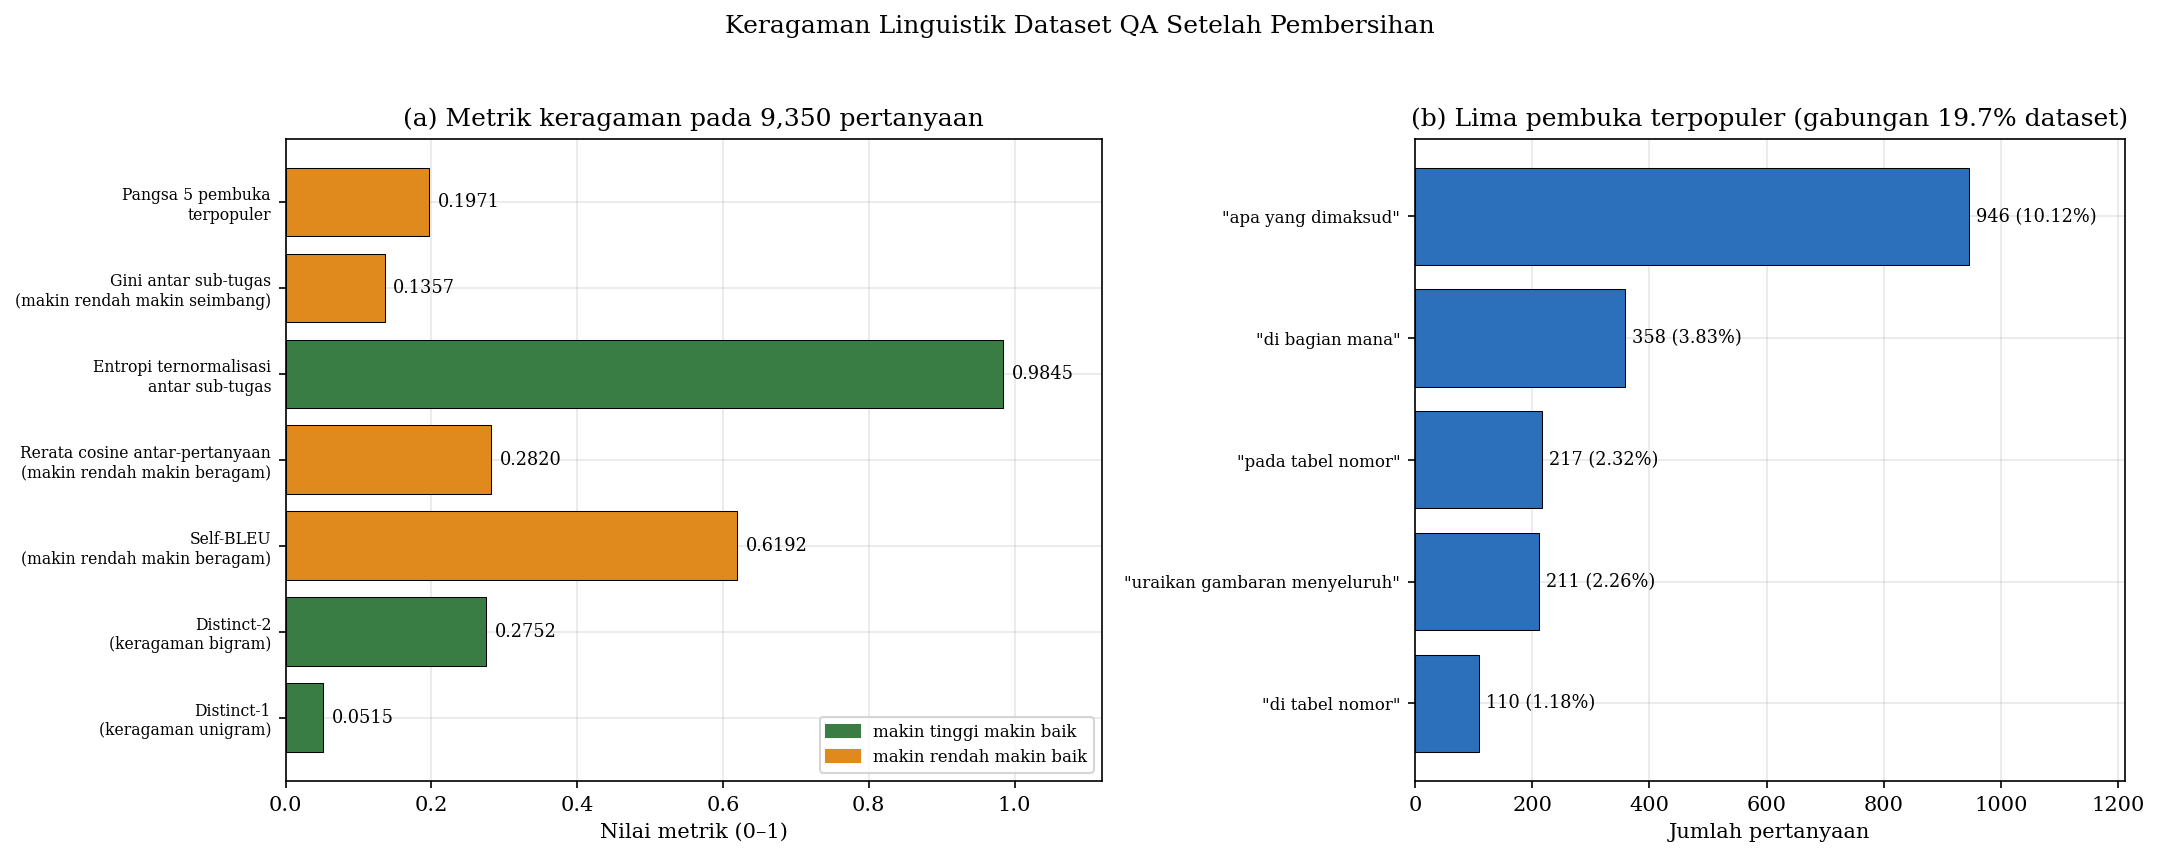

In [77]:
def fig22_keragaman():
    fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.5), gridspec_kw={"width_ratios": [1.15, 1]})

    ax = axes[0]
    ket = {"distinct_1": "Distinct-1\n(keragaman unigram)", "distinct_2": "Distinct-2\n(keragaman bigram)",
           "self_bleu": "Self-BLEU\n(makin rendah makin beragam)",
           "mean_pairwise_cosine": "Rerata cosine antar-pertanyaan\n(makin rendah makin beragam)",
           "stratum_normalized_entropy": "Entropi ternormalisasi\nantar sub-tugas",
           "stratum_gini": "Gini antar sub-tugas\n(makin rendah makin seimbang)",
           "top5_opener_share": "Pangsa 5 pembuka\nterpopuler"}
    makin_tinggi_makin_baik = {"distinct_1", "distinct_2", "stratum_normalized_entropy"}
    d = pd.Series(DIVERSITY)
    warna = [C_KEEP if k in makin_tinggi_makin_baik else C_ACCENT for k in d.index]
    ax.barh([ket[k] for k in d.index], d.values, color=warna, edgecolor="black", linewidth=.5)
    for y, v in enumerate(d.values):
        ax.text(v + .012, y, f"{v:.4f}", va="center", fontsize=8.5)
    ax.set_xlim(0, 1.12); ax.set_xlabel("Nilai metrik (0–1)")
    ax.tick_params(axis="y", labelsize=7.5)
    ax.set_title(f"(a) Metrik keragaman pada {FILTERED_RECORDS:,} pertanyaan")
    ax.legend(handles=[Patch(color=C_KEEP, label="makin tinggi makin baik"),
                       Patch(color=C_ACCENT, label="makin rendah makin baik")],
              fontsize=8, loc="lower right")

    ax = axes[1]
    d2 = pd.Series(TOP_OPENER).sort_values()
    ax.barh([f'"{k}"' for k in d2.index], d2.values, color=C_CLEAN, edgecolor="black", linewidth=.5)
    for y, v in enumerate(d2.values):
        ax.text(v + 12, y, f"{v:,} ({100 * v / FILTERED_RECORDS:.2f}%)", va="center", fontsize=8.5)
    ax.set_xlabel("Jumlah pertanyaan"); ax.set_xlim(0, d2.max() * 1.28)
    ax.tick_params(axis="y", labelsize=8)
    ax.set_title(f"(b) Lima pembuka terpopuler "
                 f"(gabungan {100 * DIVERSITY['top5_opener_share']:.1f}% dataset)")

    fig.suptitle("Keragaman Linguistik Dataset QA Setelah Pembersihan", y=1.03)
    plt.tight_layout(); plt.savefig("fig22_keragaman.png", bbox_inches="tight"); plt.show()

fig22_keragaman()

### Gambar 23 — Kesesuaian semantik jawaban terhadap konteks (IndoBERT)
Kemiripan semantik antara jawaban dan konteks sumber menjadi proksi *groundedness*. Tipe navigasi sumber memiliki kemiripan paling rendah karena jawabannya berupa penunjuk lokasi (nomor tabel/bagian), bukan kutipan isi — perbedaan yang bersifat struktural, bukan indikasi kesalahan.

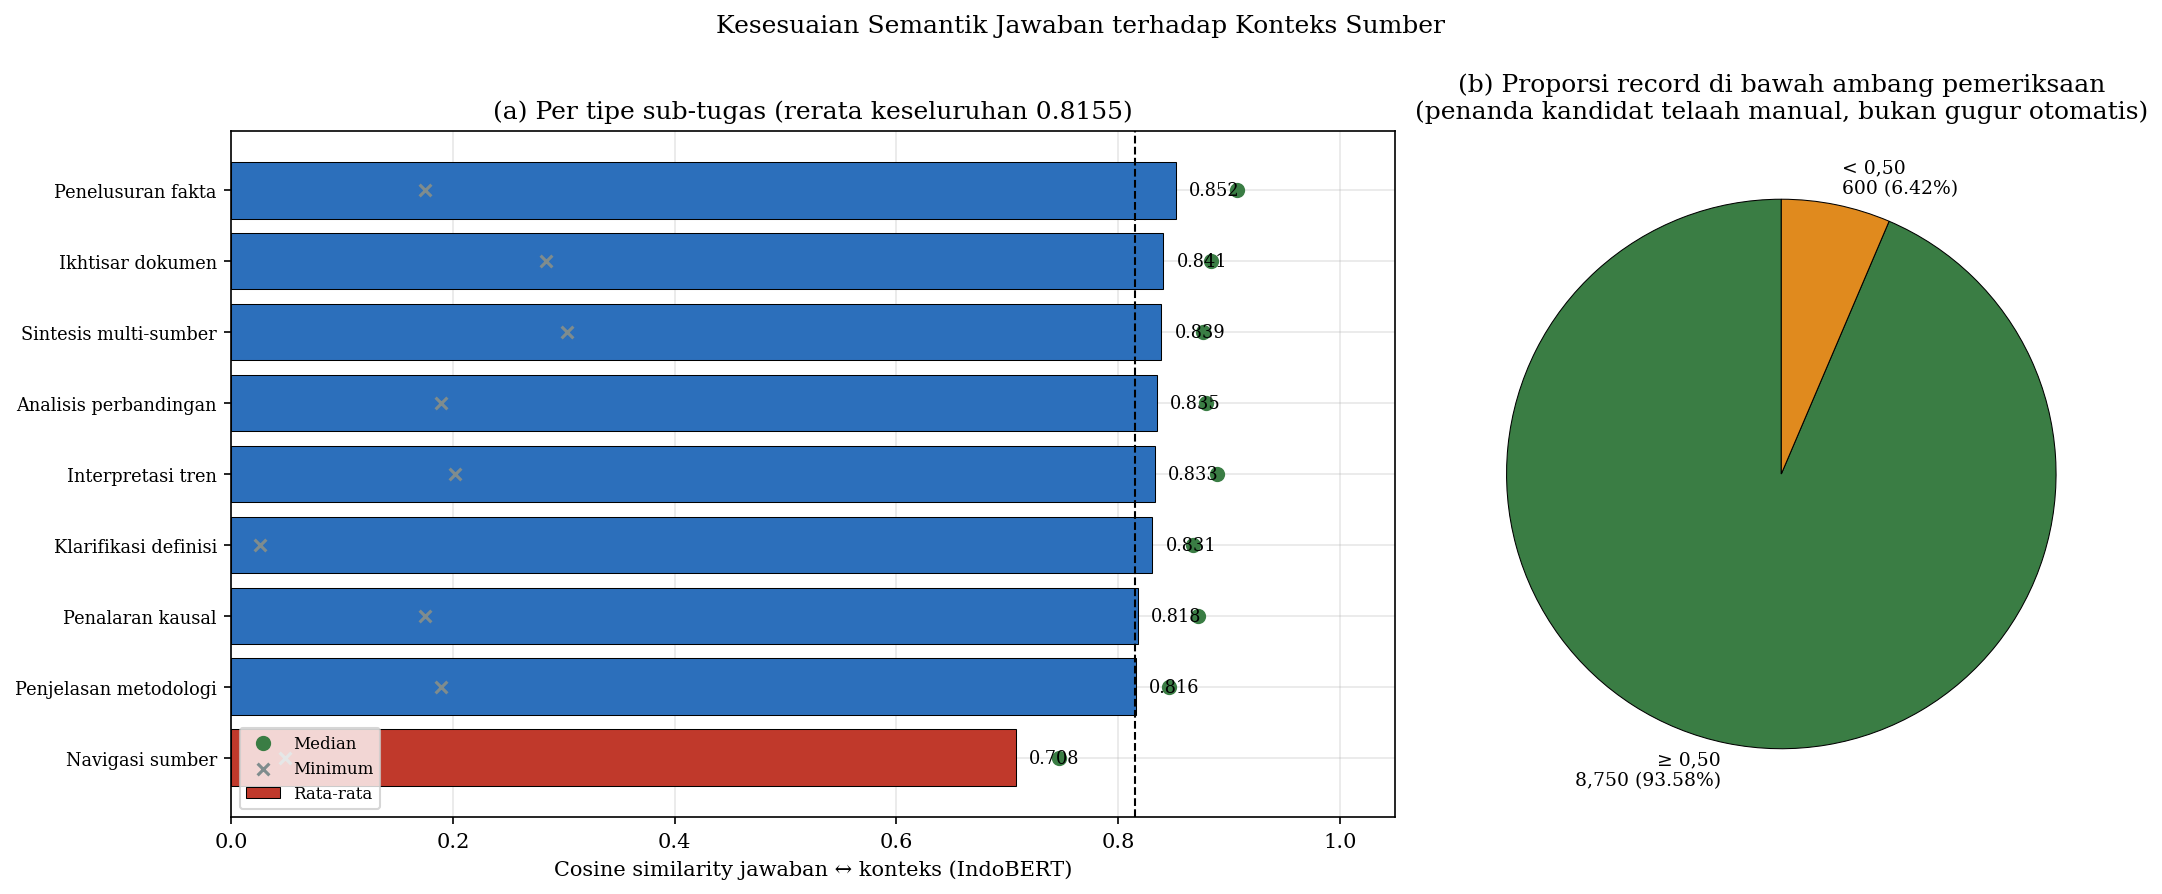

In [78]:
def fig23_similarity_semantik():
    fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.8), gridspec_kw={"width_ratios": [1.6, 1]})

    ax = axes[0]
    d = SIMILARITY_SUBTASK.sort_values("mean")
    y = np.arange(len(d))
    warna = [C_DROP if v < .75 else C_CLEAN for v in d["mean"]]
    ax.barh(y, d["mean"], color=warna, edgecolor="black", linewidth=.5, label="Rata-rata")
    ax.scatter(d["median"], y, color=C_KEEP, s=40, zorder=3, marker="o", label="Median")
    ax.scatter(d["min"], y, color=C_MUTED, s=32, zorder=3, marker="x", label="Minimum")
    for yi, v in zip(y, d["mean"]):
        ax.text(v + .012, yi, f"{v:.3f}", va="center", fontsize=8.5)
    ax.axvline(SIMILARITY_OVERALL["mean"], ls="--", color="black", lw=1)
    ax.set_yticks(y); ax.set_yticklabels([SUBTASK_LABEL[k] for k in d.index], fontsize=8.5)
    ax.set_xlim(0, 1.05); ax.set_xlabel("Cosine similarity jawaban ↔ konteks (IndoBERT)")
    ax.set_title(f"(a) Per tipe sub-tugas (rerata keseluruhan {SIMILARITY_OVERALL['mean']:.4f})")
    ax.legend(fontsize=8, loc="lower left")

    ax = axes[1]
    rendah = SIMILARITY_OVERALL["di_bawah_0.5"]
    tinggi = SIMILARITY_OVERALL["n"] - rendah
    ax.pie([tinggi, rendah],
           labels=[f"≥ 0,50\n{tinggi:,} ({100 * tinggi / SIMILARITY_OVERALL['n']:.2f}%)",
                   f"< 0,50\n{rendah:,} ({100 * rendah / SIMILARITY_OVERALL['n']:.2f}%)"],
           colors=[C_KEEP, C_ACCENT], startangle=90,
           wedgeprops={"edgecolor": "black", "linewidth": .5}, textprops={"fontsize": 9})
    ax.set_title("(b) Proporsi record di bawah ambang pemeriksaan\n"
                 "(penanda kandidat telaah manual, bukan gugur otomatis)")
    ax.grid(False)

    fig.suptitle("Kesesuaian Semantik Jawaban terhadap Konteks Sumber", y=1.02)
    plt.tight_layout(); plt.savefig("fig23_similarity_semantik.png", bbox_inches="tight"); plt.show()

fig23_similarity_semantik()

### Gambar 24 — Dataset final: pembagian train/val/test tingkat section

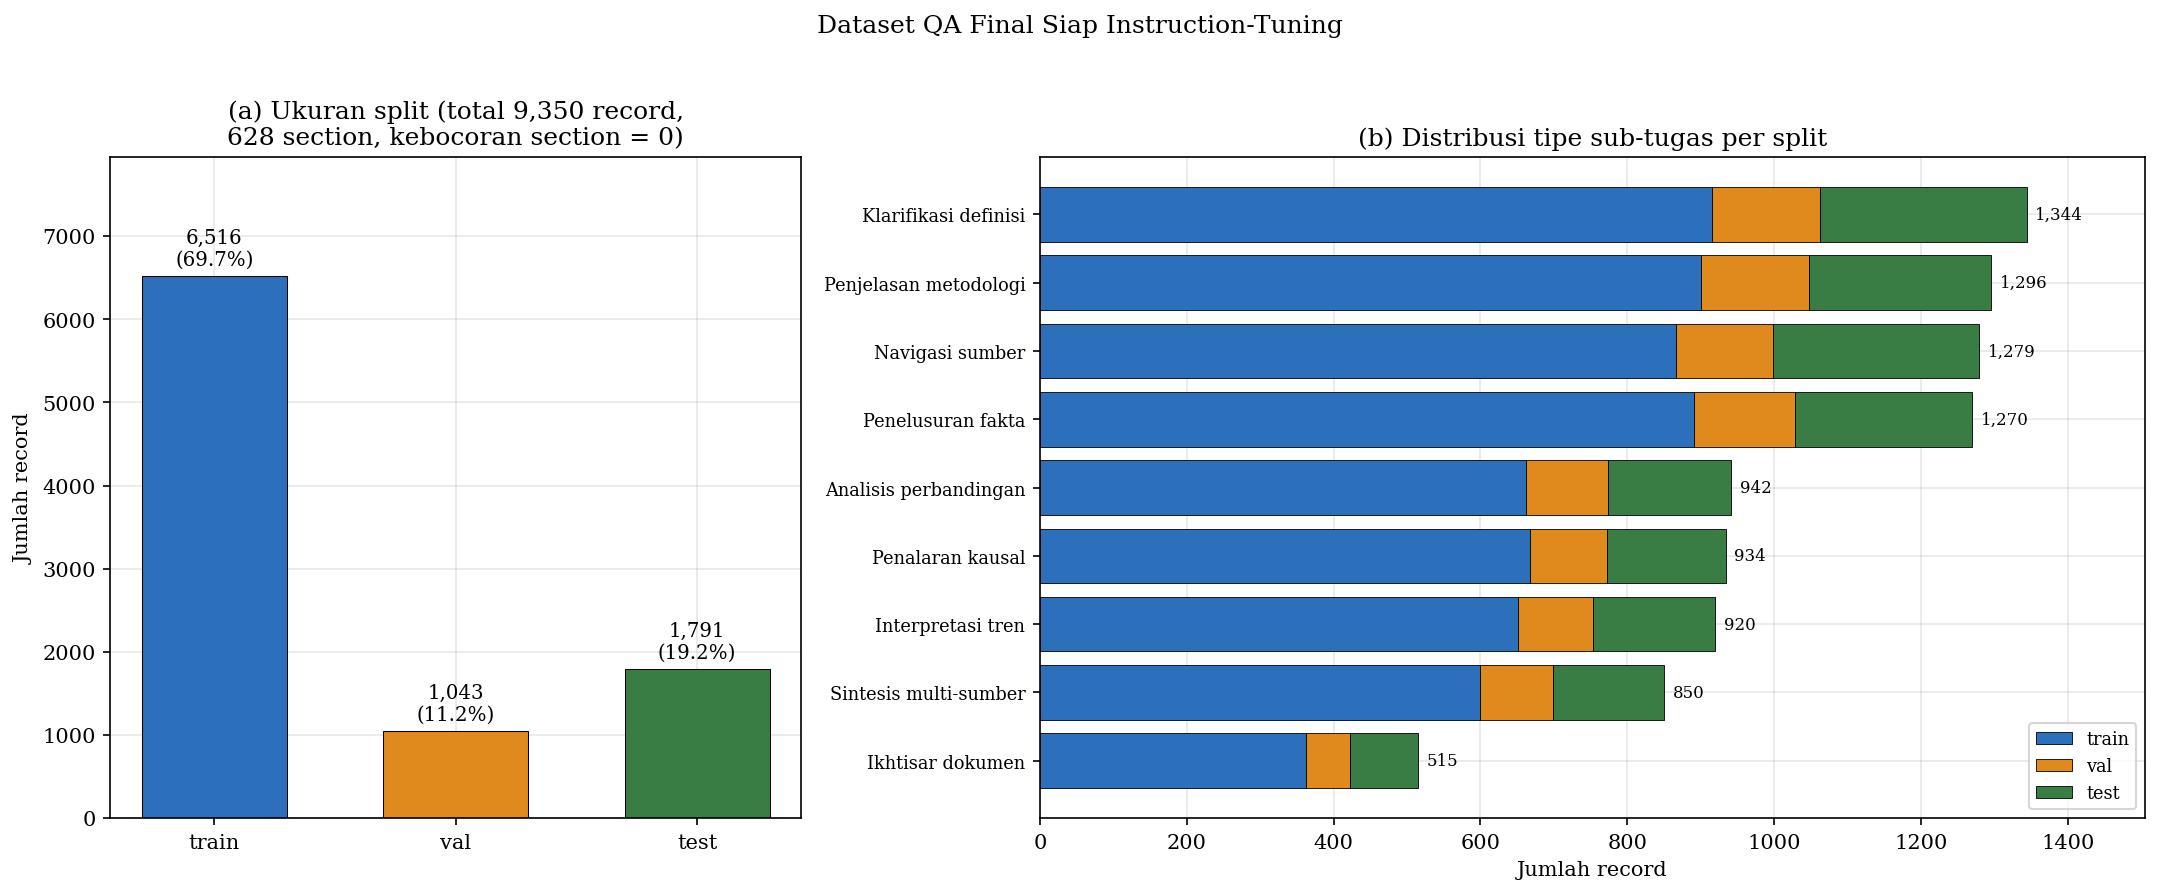

In [79]:
def fig24_dataset_final():
    fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.8), gridspec_kw={"width_ratios": [1, 1.6]})

    ax = axes[0]
    nama = list(SPLIT_COUNTS.keys()); nilai = list(SPLIT_COUNTS.values())
    total = sum(nilai)
    ax.bar(nama, nilai, color=[C_CLEAN, C_ACCENT, C_KEEP], edgecolor="black", linewidth=.5, width=.6)
    for i, v in enumerate(nilai):
        ax.text(i, v + total * .015, f"{v:,}\n({100 * v / total:.1f}%)", ha="center", fontsize=9.5)
    ax.set_ylabel("Jumlah record"); ax.set_ylim(0, max(nilai) * 1.22)
    ax.set_title(f"(a) Ukuran split (total {total:,} record,\n{N_SECTION_FINAL} section, "
                 f"kebocoran section = {N_SECTION_BOCOR})")

    ax = axes[1]
    d = SUBTASK_BY_SPLIT.loc[SUBTASK_BY_SPLIT.sum(axis=1).sort_values().index]
    y = np.arange(len(d)); kiri = np.zeros(len(d))
    for kol, warna in [("train", C_CLEAN), ("val", C_ACCENT), ("test", C_KEEP)]:
        ax.barh(y, d[kol], left=kiri, color=warna, edgecolor="black", linewidth=.4, label=kol)
        kiri += d[kol].values
    for yi, v in enumerate(kiri):
        ax.text(v + 12, yi, f"{int(v):,}", va="center", fontsize=8)
    ax.set_yticks(y); ax.set_yticklabels([SUBTASK_LABEL[k] for k in d.index], fontsize=8.5)
    ax.set_xlabel("Jumlah record"); ax.set_xlim(0, kiri.max() * 1.12)
    ax.set_title("(b) Distribusi tipe sub-tugas per split"); ax.legend(fontsize=8.5, loc="lower right")

    fig.suptitle("Dataset QA Final Siap Instruction-Tuning", y=1.02)
    plt.tight_layout(); plt.savefig("fig24_dataset_final.png", bbox_inches="tight"); plt.show()

fig24_dataset_final()

### Gambar 25 — Basis pengetahuan vektor dan uji coba penelusuran
Seluruh chunk korpus diindeks sebagai basis pengetahuan RAG. Uji coba kualitatif lima kueri menunjukkan sebaran skor kemiripan kandidat teratas; belum ada evaluasi penelusuran kuantitatif (recall@k) pada tahap ini.

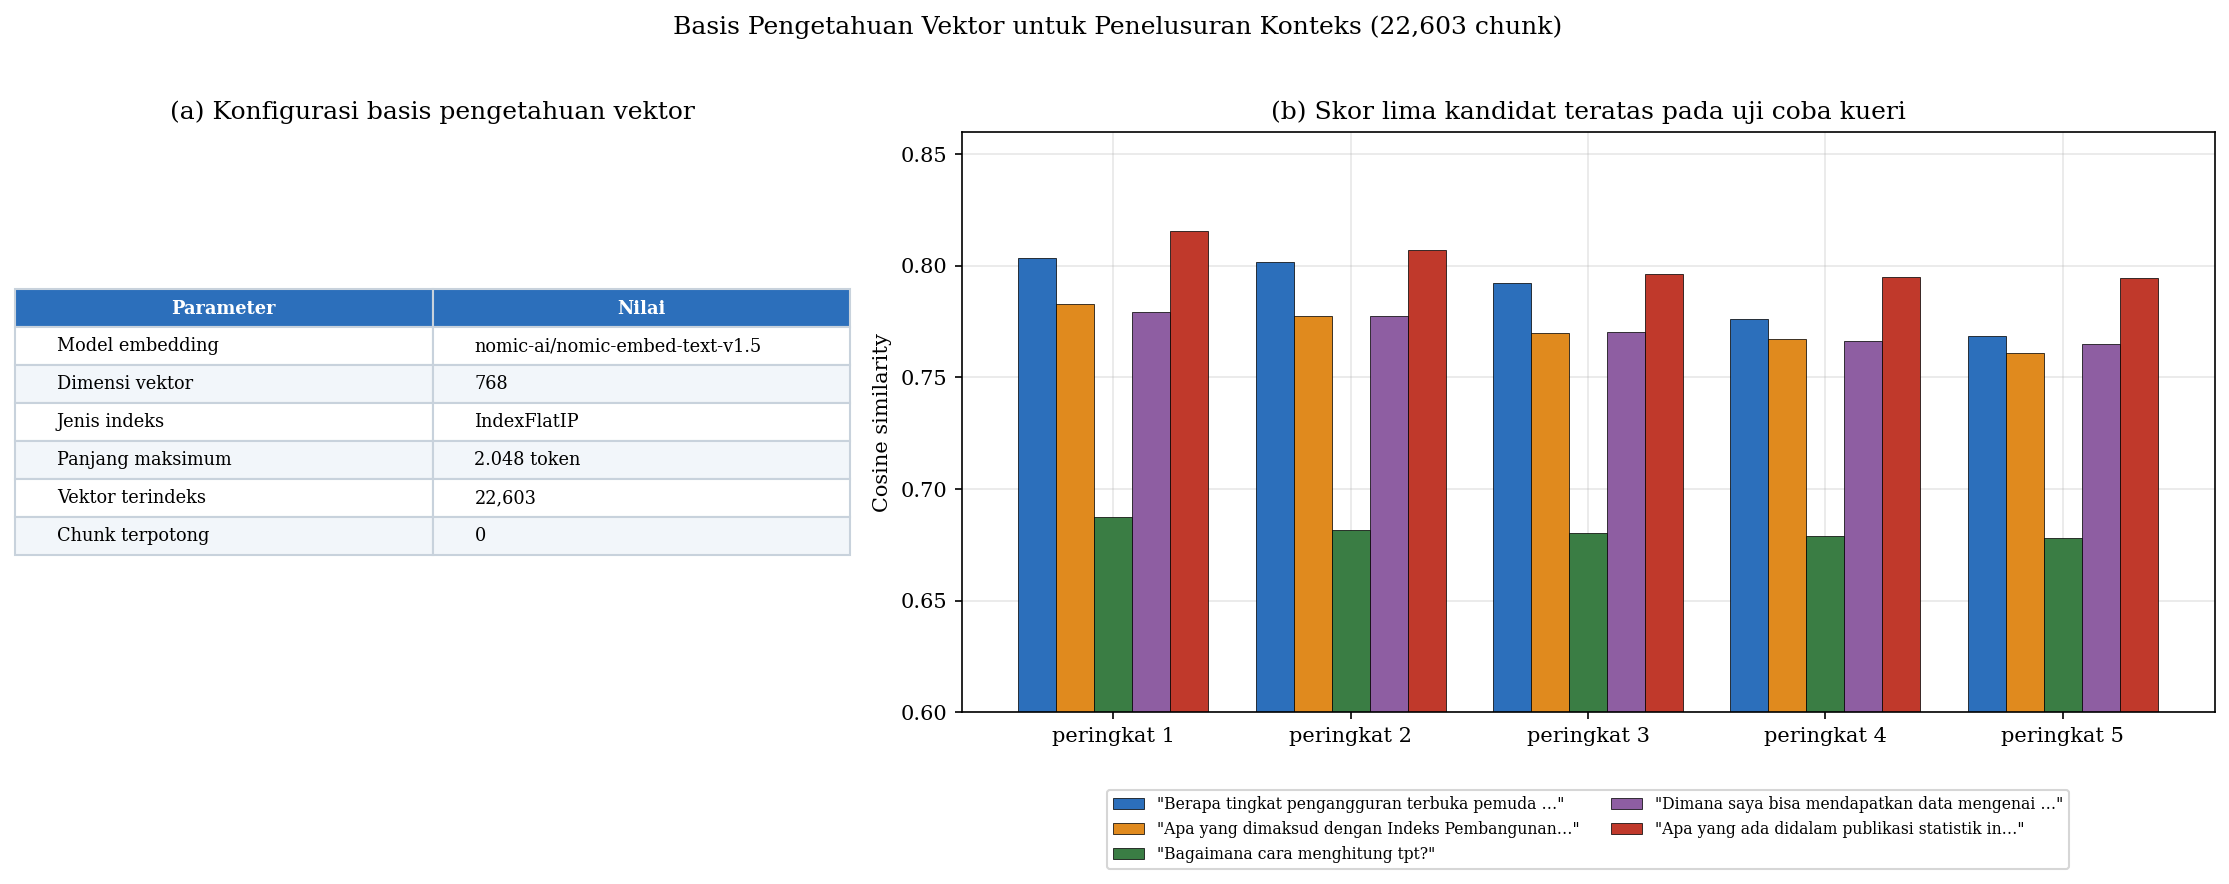

In [80]:
def fig25_basis_pengetahuan():
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.8), gridspec_kw={"width_ratios": [1, 1.5]})

    ax = axes[0]
    ax.axis("off"); ax.grid(False)
    isi = [["Model embedding", EMBED_MODEL], ["Dimensi vektor", f"{EMBED_DIM}"],
           ["Jenis indeks", FAISS_INDEX], ["Panjang maksimum", "2.048 token"],
           ["Vektor terindeks", f"{N_VEKTOR:,}"], ["Chunk terpotong", f"{N_TERPOTONG}"]]
    tabel = ax.table(cellText=isi, colLabels=["Parameter", "Nilai"], loc="center", cellLoc="left")
    tabel.auto_set_font_size(False); tabel.set_fontsize(8.5); tabel.scale(1, 1.75)
    for (baris, kolom), sel in tabel.get_celld().items():
        sel.set_edgecolor("#c8d2dc")
        if baris == 0:
            sel.set_facecolor(C_CLEAN); sel.set_text_props(color="white", fontweight="bold")
        elif baris % 2 == 0:
            sel.set_facecolor("#f2f6fa")
    ax.set_title("(a) Konfigurasi basis pengetahuan vektor")

    ax = axes[1]
    x = np.arange(5); w = .16
    warna_urut = ["#2c6fbb", "#e08a1e", "#3a7d44", "#8e5ea2", "#c0392b"]
    for i, (kueri, skor) in enumerate(SMOKE_TEST.items()):
        ax.bar(x + (i - 2) * w, skor, w, color=warna_urut[i], edgecolor="black",
               linewidth=.35, label=f'"{label_pendek(kueri, 44)}"')
    ax.set_xticks(x); ax.set_xticklabels([f"peringkat {i + 1}" for i in range(5)])
    ax.set_ylim(.6, .86); ax.set_ylabel("Cosine similarity")
    ax.set_title("(b) Skor lima kandidat teratas pada uji coba kueri")
    ax.legend(fontsize=7.5, loc="upper center", bbox_to_anchor=(.5, -.12), ncol=2)

    fig.suptitle(f"Basis Pengetahuan Vektor untuk Penelusuran Konteks ({N_VEKTOR:,} chunk)", y=1.02)
    plt.tight_layout(); plt.savefig("fig25_basis_pengetahuan.png", bbox_inches="tight"); plt.show()

fig25_basis_pengetahuan()

### Gambar 26 — Karakteristik dataset final dari berkas `train/val/test.csv` *(opsional)*
Grafik ini menghitung ulang distribusi langsung dari berkas dataset final, sehingga memberi resolusi penuh (bukan ringkasan) atas skor kualitas, panjang konteks, dan cakupan dokumen. Lewati jika berkas belum diunduh.

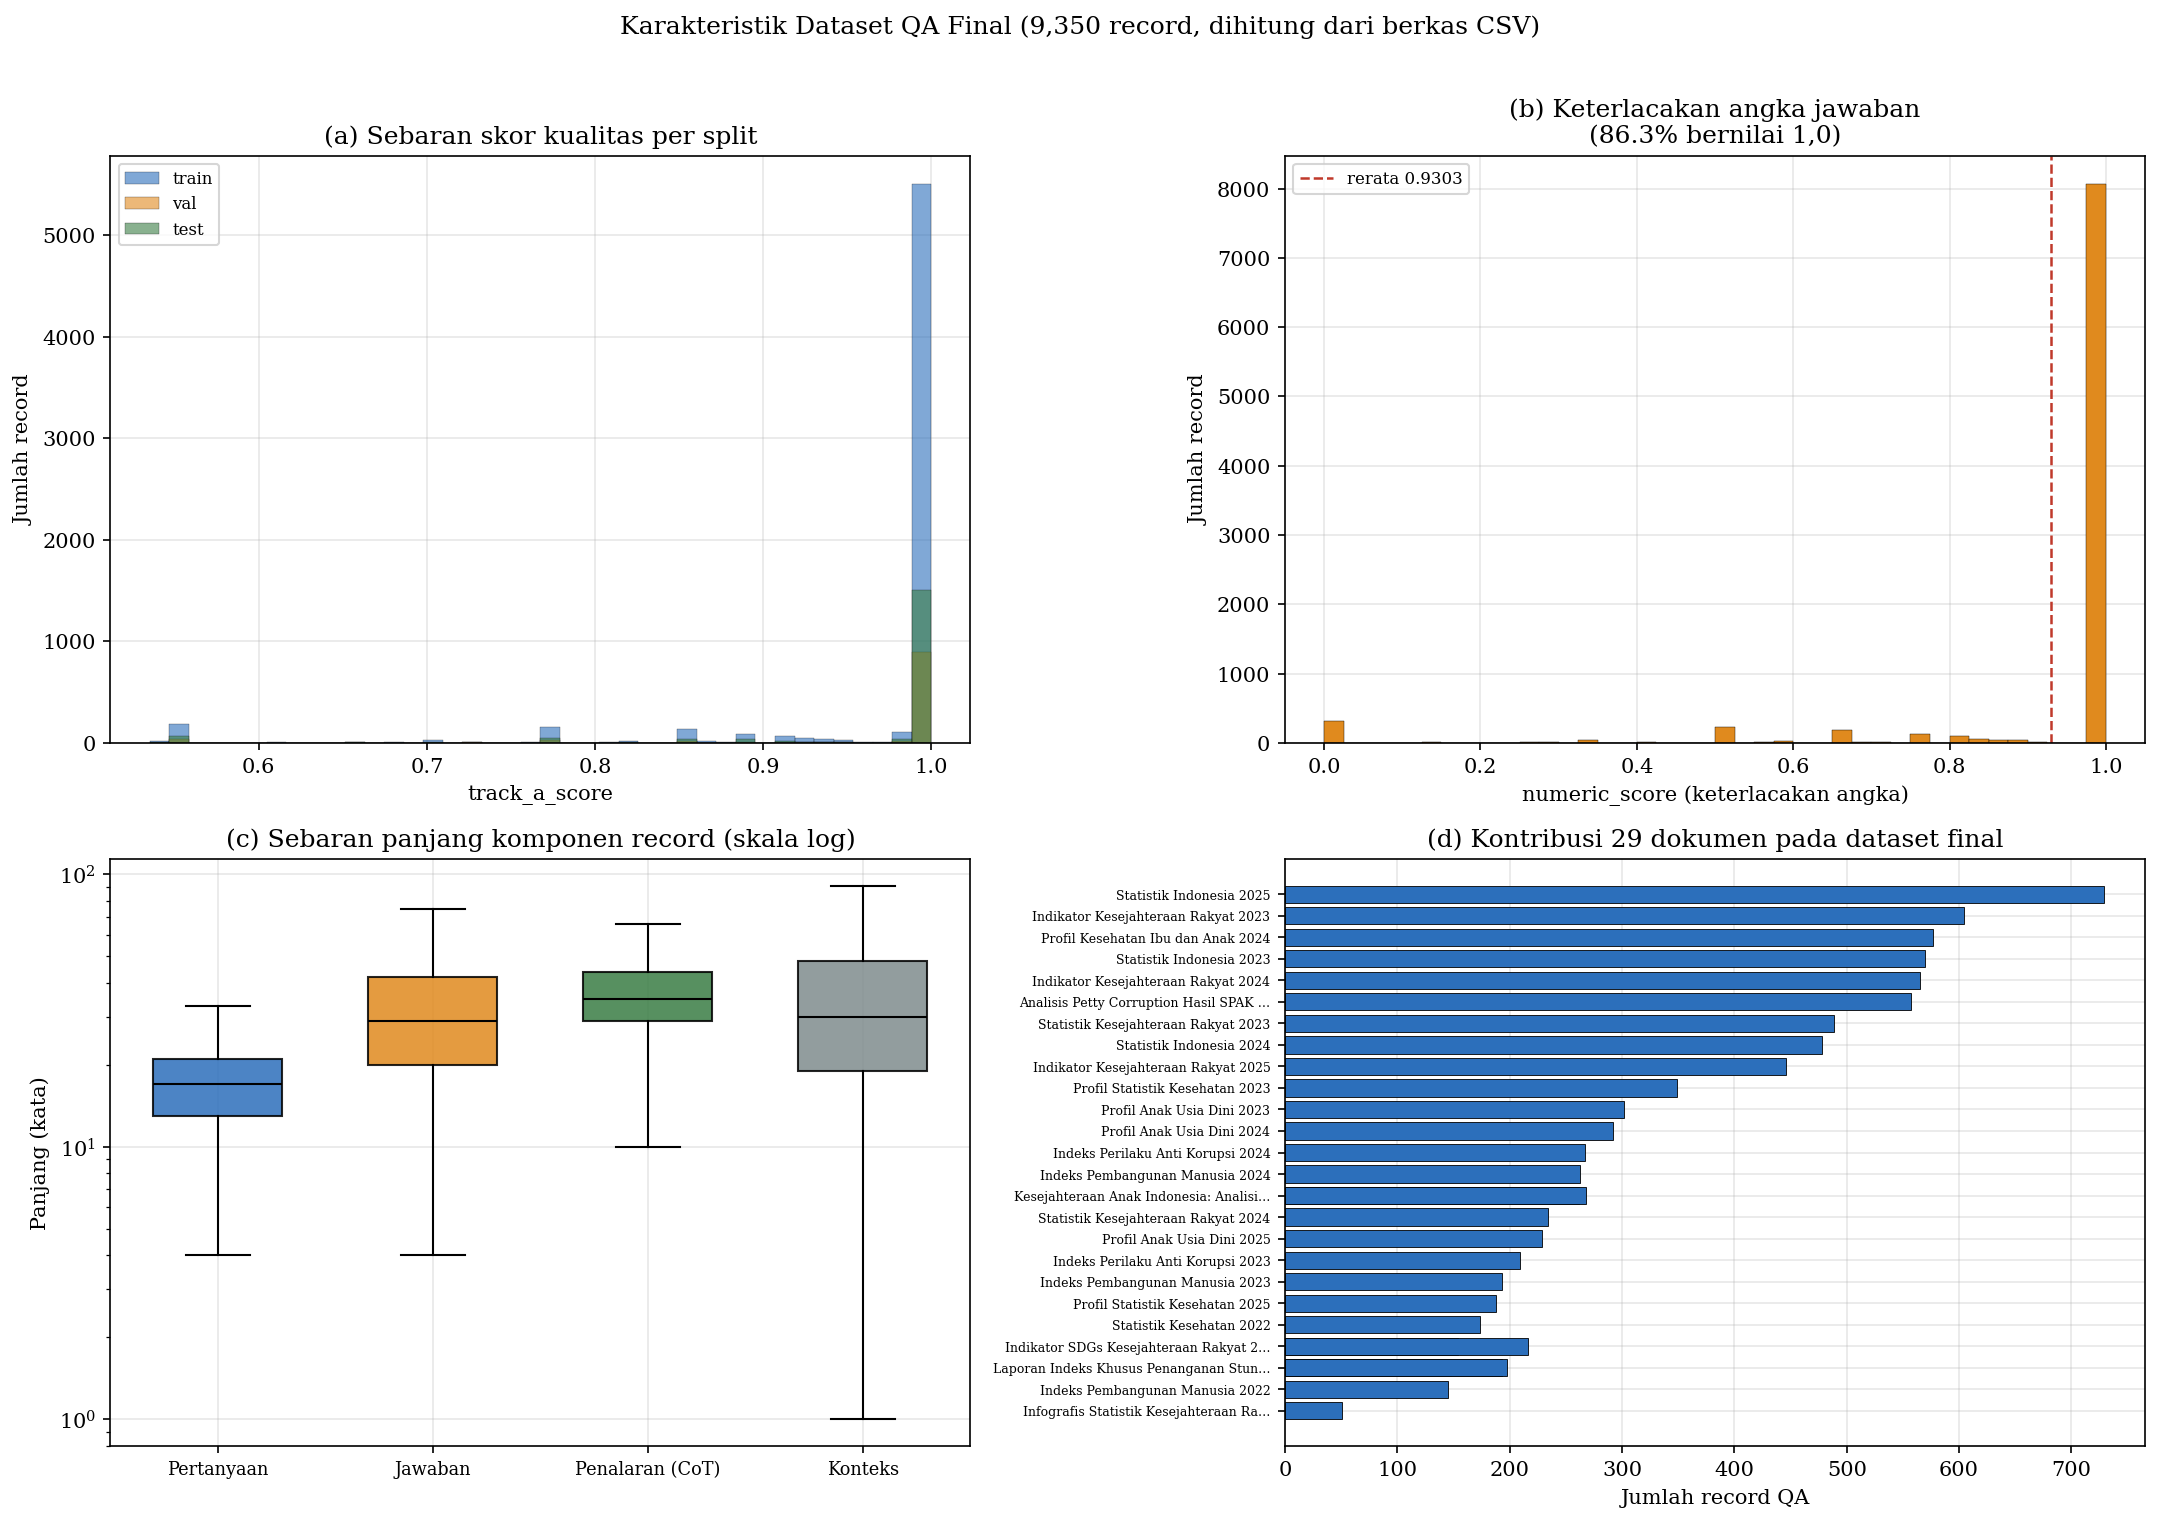

In [81]:
def fig26_karakteristik_dataset_csv():
    berkas = ["train.csv", "val.csv", "test.csv"]
    if not ada(*berkas):
        lewati("train.csv / val.csv / test.csv belum tersedia di direktori notebook.")
        return
    df = pd.concat([pd.read_csv(f).assign(split=f.replace(".csv", "")) for f in berkas], ignore_index=True)

    fig, axes = plt.subplots(2, 2, figsize=(14.5, 10))

    ax = axes[0, 0]
    for split, warna in [("train", C_CLEAN), ("val", C_ACCENT), ("test", C_KEEP)]:
        ax.hist(df[df["split"] == split]["track_a_score"], bins=40, alpha=.6,
                color=warna, edgecolor="black", linewidth=.2, label=split)
    ax.set_xlabel("track_a_score"); ax.set_ylabel("Jumlah record")
    ax.set_title("(a) Sebaran skor kualitas per split"); ax.legend(fontsize=8)

    ax = axes[0, 1]
    ax.hist(df["numeric_score"], bins=40, color=C_ACCENT, edgecolor="black", linewidth=.2)
    prop_sempurna = (df["numeric_score"] >= .999).mean()
    ax.axvline(df["numeric_score"].mean(), ls="--", color=C_DROP, lw=1.2,
               label=f"rerata {df['numeric_score'].mean():.4f}")
    ax.set_xlabel("numeric_score (keterlacakan angka)"); ax.set_ylabel("Jumlah record")
    ax.set_title(f"(b) Keterlacakan angka jawaban\n({100 * prop_sempurna:.1f}% bernilai 1,0)")
    ax.legend(fontsize=8)

    ax = axes[1, 0]
    panjang = pd.DataFrame({
        "Pertanyaan": df["instruction"].astype(str).str.split().str.len(),
        "Jawaban": df["response"].astype(str).str.split().str.len(),
        "Penalaran (CoT)": df["cot"].astype(str).str.split().str.len(),
        "Konteks": df["context_joined"].astype(str).str.split().str.len(),
    })
    bp = ax.boxplot([panjang[k].dropna() for k in panjang.columns], patch_artist=True,
                    widths=.6, showfliers=False)
    for patch, warna in zip(bp["boxes"], [C_CLEAN, C_ACCENT, C_KEEP, C_MUTED]):
        patch.set_facecolor(warna); patch.set_alpha(.85)
    for med in bp["medians"]: med.set_color("black")
    ax.set_xticklabels(panjang.columns, fontsize=8.5)
    ax.set_ylabel("Panjang (kata)"); ax.set_yscale("log")
    ax.set_title("(c) Sebaran panjang komponen record (skala log)")

    ax = axes[1, 1]
    per_dok = df["document_title"].value_counts().sort_values()
    ax.barh([label_pendek(str(k), 38) for k in per_dok.index], per_dok.values,
            color=C_CLEAN, edgecolor="black", linewidth=.4)
    ax.set_xlabel("Jumlah record QA"); ax.tick_params(axis="y", labelsize=6)
    ax.set_title(f"(d) Kontribusi {len(per_dok)} dokumen pada dataset final")

    fig.suptitle(f"Karakteristik Dataset QA Final ({len(df):,} record, dihitung dari berkas CSV)", y=1.01)
    plt.tight_layout(); plt.savefig("fig26_karakteristik_dataset_csv.png", bbox_inches="tight"); plt.show()

fig26_karakteristik_dataset_csv()

---
# Bagian 4 — Modelling: Persiapan, Instruction-Tuning, dan Generasi Prediksi
Sumber: `08-modelling-preparation.ipynb`, `09-instruction-tuning-gemma2.ipynb`, `09-instruction-tuning-llama3-2.ipynb`, serta kedua notebook `10-generate-prediction-*`.

Dua SLM terpilih dari Tujuan 1 (Gemma-2-2B dan Llama-3.2-3B) dilatih dengan QLoRA 4-bit menggunakan Unsloth pada dua GPU Tesla T4. Konfigurasi panjang token dan ukuran batch ditetapkan lewat pemindaian empiris, bukan asumsi — bagian ini melaporkan seluruh proses tersebut beserta dinamika loss-nya.

In [82]:
# ---- Statistik panjang token & pemindaian batch (sumber: 08-modelling-preparation.ipynb) ----
TOKEN_STATS = pd.DataFrame([
    ("gemma2", 98, 266.6, 475, 645, 915, 1024, 4),
    ("llama3.2", 152, 377.9, 648, 862, 1104, 1536, 2),
], columns=["model", "min", "mean", "p95", "p99", "max", "max_seq_length", "max_batch_size_ok"]).set_index("model")

# ---- Hiperparameter instruction-tuning (sumber: 09-instruction-tuning-*) ----
HPARAM = pd.DataFrame([
    ("Model dasar", "unsloth/gemma-2-2b-it-bnb-4bit", "unsloth/Llama-3.2-3B-Instruct-bnb-4bit"),
    ("Kuantisasi", "4-bit (QLoRA)", "4-bit (QLoRA)"),
    ("max_seq_length", "1024", "1536"),
    ("LoRA r / alpha / dropout", "16 / 32 / 0,1", "16 / 32 / 0,1"),
    ("Target modules", "7 proyeksi (q,k,v,o,gate,up,down)", "7 proyeksi (q,k,v,o,gate,up,down)"),
    ("Batch per device", "4", "2"),
    ("Gradient accumulation", "4", "8"),
    ("Effective batch size", "16", "16"),
    ("Learning rate", "2e-05 (konstan)", "2e-05 (konstan)"),
    ("Epoch / total step", "3 / 1.224", "3 / 1.224"),
    ("Optimizer", "paged_adamw_8bit", "paged_adamw_8bit"),
    ("Weight decay / max grad norm", "0,01 / 0,3", "0,01 / 0,3"),
    ("Presisi", "fp16", "fp16"),
    ("Seed", "42", "42"),
], columns=["Parameter", "Gemma-2-2B", "Llama-3.2-3B"]).set_index("Parameter")

TRAIN_META = pd.DataFrame([
    ("gemma2", 20_766_720, 2_635_108_608, 14399.5336, 1.358, 0.085, 9.066592861861478e16,
     0.43756067402222576, 0.44047707319259644, 26),
    ("llama3.2", 24_313_856, 3_237_063_680, 20697.9127, 0.944, 0.059, 1.486803216245883e17,
     0.36088670196096884, 0.3404146730899811, 28),
], columns=["model", "trainable_params", "total_params", "train_runtime_sec", "samples_per_sec",
            "steps_per_sec", "total_flos", "final_train_loss", "final_eval_loss", "n_layers"]).set_index("model")

# ---- Riwayat loss (tabel Trainer, dicatat tiap 50 step; sumber: 09-instruction-tuning-*) ----
LOSS_STEPS = list(range(50, 1250, 50))
LOSS_HISTORY = {
    "gemma2": {
        "train": [0.605959, 0.516120, 0.512292, 0.476727, 0.488645, 0.469185, 0.478380, 0.429391,
                  0.395961, 0.434724, 0.440193, 0.432446, 0.403764, 0.398001, 0.465335, 0.411750,
                  0.363339, 0.362270, 0.372324, 0.346749, 0.337416, 0.371545, 0.345916, 0.378617],
        "val": [0.586530, 0.532535, 0.510041, 0.494694, 0.483928, 0.476580, 0.468103, 0.461658,
                0.460074, 0.455453, 0.453379, 0.449636, 0.446809, 0.446038, 0.443131, 0.441423,
                0.444902, 0.444399, 0.443288, 0.447983, 0.445164, 0.443623, 0.441368, 0.440477],
    },
    "llama3.2": {
        "train": [0.513077, 0.434574, 0.420482, 0.380053, 0.389444, 0.372842, 0.387252, 0.344573,
                  0.328575, 0.357714, 0.361279, 0.356578, 0.340888, 0.330853, 0.382733, 0.336359,
                  0.306034, 0.294703, 0.306884, 0.296678, 0.284009, 0.312063, 0.294919, 0.316802],
        "val": [0.486786, 0.435048, 0.414014, 0.399552, 0.391047, 0.383110, 0.376190, 0.371407,
                0.367526, 0.364472, 0.360319, 0.359315, 0.355112, 0.353236, 0.350473, 0.348376,
                0.348847, 0.347630, 0.345929, 0.345246, 0.344719, 0.343840, 0.341568, 0.340415],
    },
}
STEP_PER_EPOCH = 408

# ---- Waktu inferensi pada 1.791 soal uji (sumber: 10-generate-prediction-*) ----
INFERENSI = pd.DataFrame([
    ("gemma2", "base", 5001.020771, 2), ("gemma2", "finetuned", 3766.706046, 2),
    ("llama3.2", "base", 11857.842389, 1), ("llama3.2", "finetuned", 11741.183301, 1),
], columns=["model", "condition", "durasi_detik", "n_gpu"])
N_TEST = 1791
GEN_CONFIG = {"max_new_tokens": 512, "do_sample": False, "strategi": "greedy decoding",
              "batch_size": 8, "temperature": None, "top_p": None, "top_k": None}

print(HPARAM.to_string())

                                                     Gemma-2-2B                            Llama-3.2-3B
Parameter                                                                                              
Model dasar                      unsloth/gemma-2-2b-it-bnb-4bit  unsloth/Llama-3.2-3B-Instruct-bnb-4bit
Kuantisasi                                        4-bit (QLoRA)                           4-bit (QLoRA)
max_seq_length                                             1024                                    1536
LoRA r / alpha / dropout                          16 / 32 / 0,1                           16 / 32 / 0,1
Target modules                7 proyeksi (q,k,v,o,gate,up,down)       7 proyeksi (q,k,v,o,gate,up,down)
Batch per device                                              4                                       2
Gradient accumulation                                         4                                       8
Effective batch size                                         16 

### Gambar 27 — Penetapan panjang urutan dan ukuran batch berdasarkan data
Panjang token dihitung dari teks latih yang sudah diformat dengan *chat template* masing-masing model. `max_seq_length` ditetapkan sebagai kandidat terkecil yang masih menampung token terpanjang, sementara ukuran batch ditentukan lewat pemindaian VRAM bertahap hingga kapasitas GPU terlampaui.

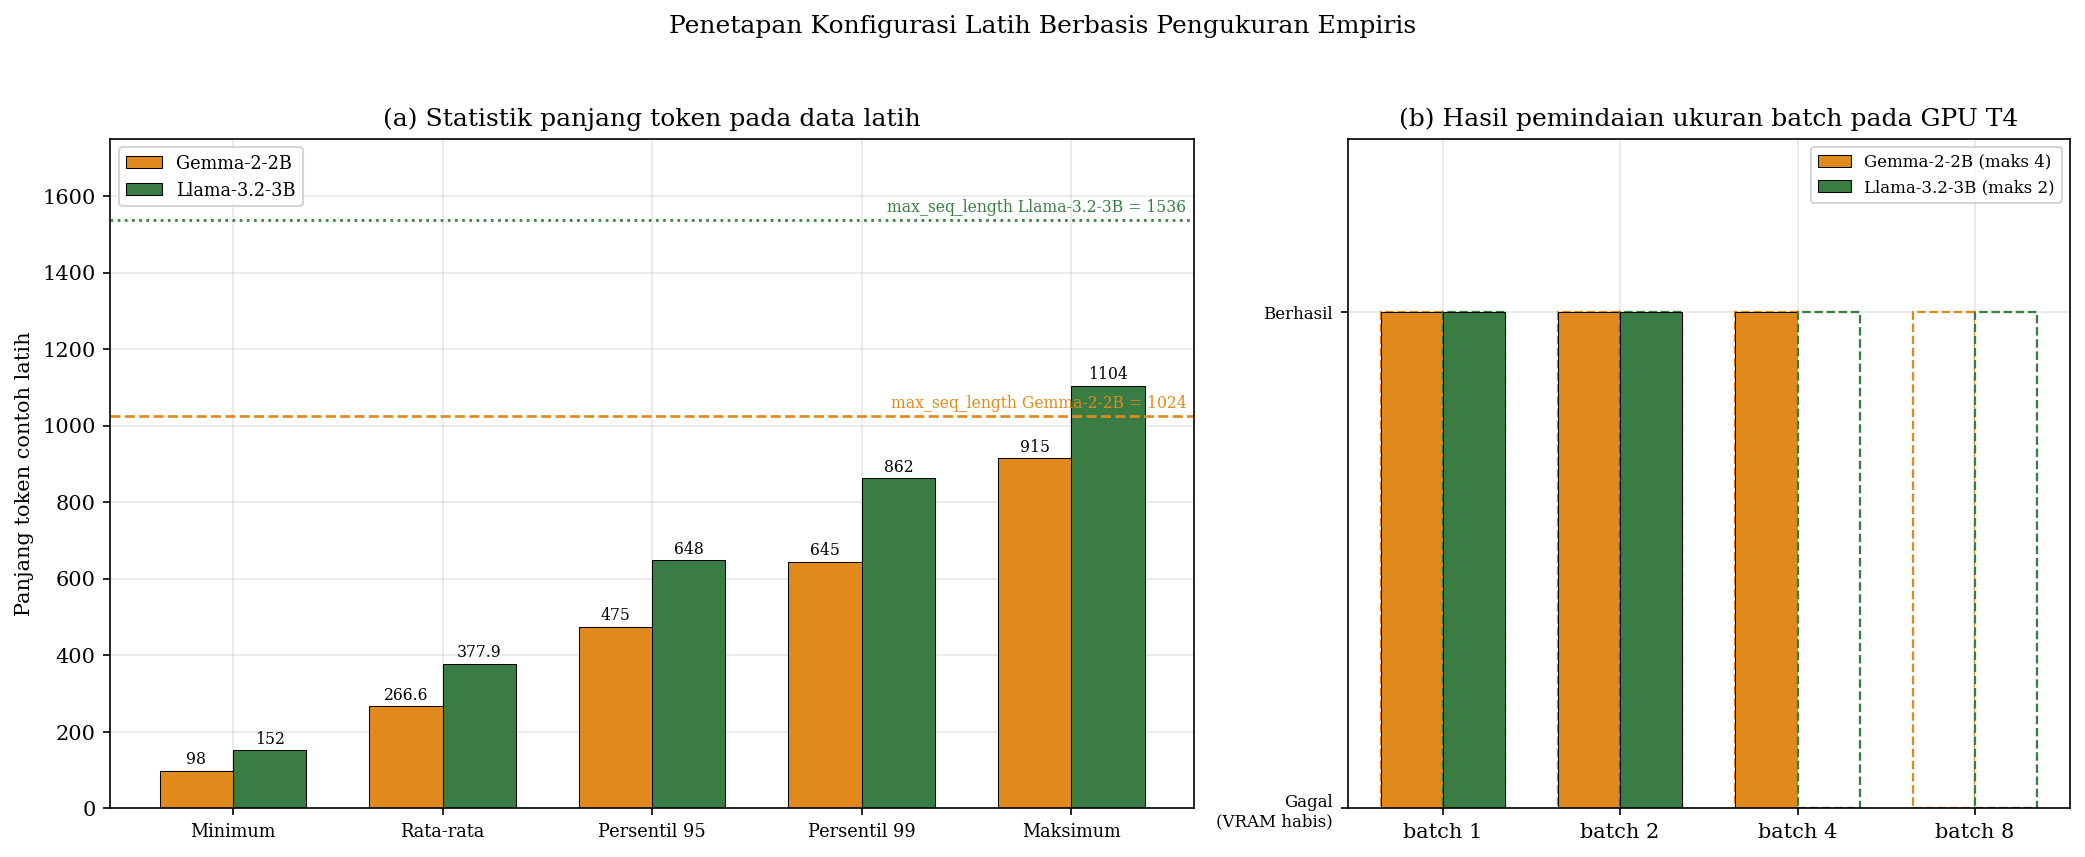

In [83]:
def fig27_panjang_token():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), gridspec_kw={"width_ratios": [1.5, 1]})

    ax = axes[0]
    stat = ["min", "mean", "p95", "p99", "max"]
    x = np.arange(len(stat)); w = .35
    for i, (mk, warna) in enumerate([("gemma2", C_GEMMA), ("llama3.2", C_LLAMA)]):
        nilai = [TOKEN_STATS.loc[mk, s] for s in stat]
        ax.bar(x + (i - .5) * w, nilai, w, color=warna, edgecolor="black",
               linewidth=.5, label=MODEL_LABELS[mk])
        for xi, v in zip(x + (i - .5) * w, nilai):
            ax.text(xi, v + 18, f"{v:g}", ha="center", fontsize=7.5)
    for mk, warna, ls in [("gemma2", C_GEMMA, "--"), ("llama3.2", C_LLAMA, ":")]:
        ax.axhline(TOKEN_STATS.loc[mk, "max_seq_length"], ls=ls, color=warna, lw=1.3)
        ax.text(len(stat) - .45, TOKEN_STATS.loc[mk, "max_seq_length"] + 22,
                f"max_seq_length {MODEL_LABELS[mk]} = {TOKEN_STATS.loc[mk, 'max_seq_length']}",
                fontsize=7.5, color=warna, ha="right")
    ax.set_xticks(x); ax.set_xticklabels(["Minimum", "Rata-rata", "Persentil 95",
                                          "Persentil 99", "Maksimum"], fontsize=8.5)
    ax.set_ylabel("Panjang token contoh latih"); ax.set_ylim(0, 1750)
    ax.set_title("(a) Statistik panjang token pada data latih"); ax.legend(fontsize=8.5, loc="upper left")

    ax = axes[1]
    kandidat = [1, 2, 4, 8]
    for i, (mk, warna) in enumerate([("gemma2", C_GEMMA), ("llama3.2", C_LLAMA)]):
        batas = TOKEN_STATS.loc[mk, "max_batch_size_ok"]
        status = [1 if b <= batas else 0 for b in kandidat]
        posisi = np.arange(len(kandidat)) + (i - .5) * .35
        ax.bar(posisi, [1] * len(kandidat), .35, color="white", edgecolor=warna,
               linewidth=1.1, linestyle="--")
        ax.bar(posisi, status, .35, color=warna, edgecolor="black", linewidth=.5,
               label=f"{MODEL_LABELS[mk]} (maks {batas})")
    ax.set_xticks(np.arange(len(kandidat))); ax.set_xticklabels([f"batch {b}" for b in kandidat])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Gagal\n(VRAM habis)", "Berhasil"], fontsize=8)
    ax.set_ylim(0, 1.35)
    ax.set_title("(b) Hasil pemindaian ukuran batch pada GPU T4")
    ax.legend(fontsize=8, loc="upper right")

    fig.suptitle("Penetapan Konfigurasi Latih Berbasis Pengukuran Empiris", y=1.03)
    plt.tight_layout(); plt.savefig("fig27_panjang_token.png", bbox_inches="tight"); plt.show()

fig27_panjang_token()

### Gambar 28 — Estimasi kebutuhan VRAM per ukuran batch *(opsional)*
Angka VRAM terekam pada `training_config.json` yang diunggah oleh notebook 08, namun tidak dicetak di notebook. Unduh berkas tersebut dari HF repo untuk menampilkan grafik ini.

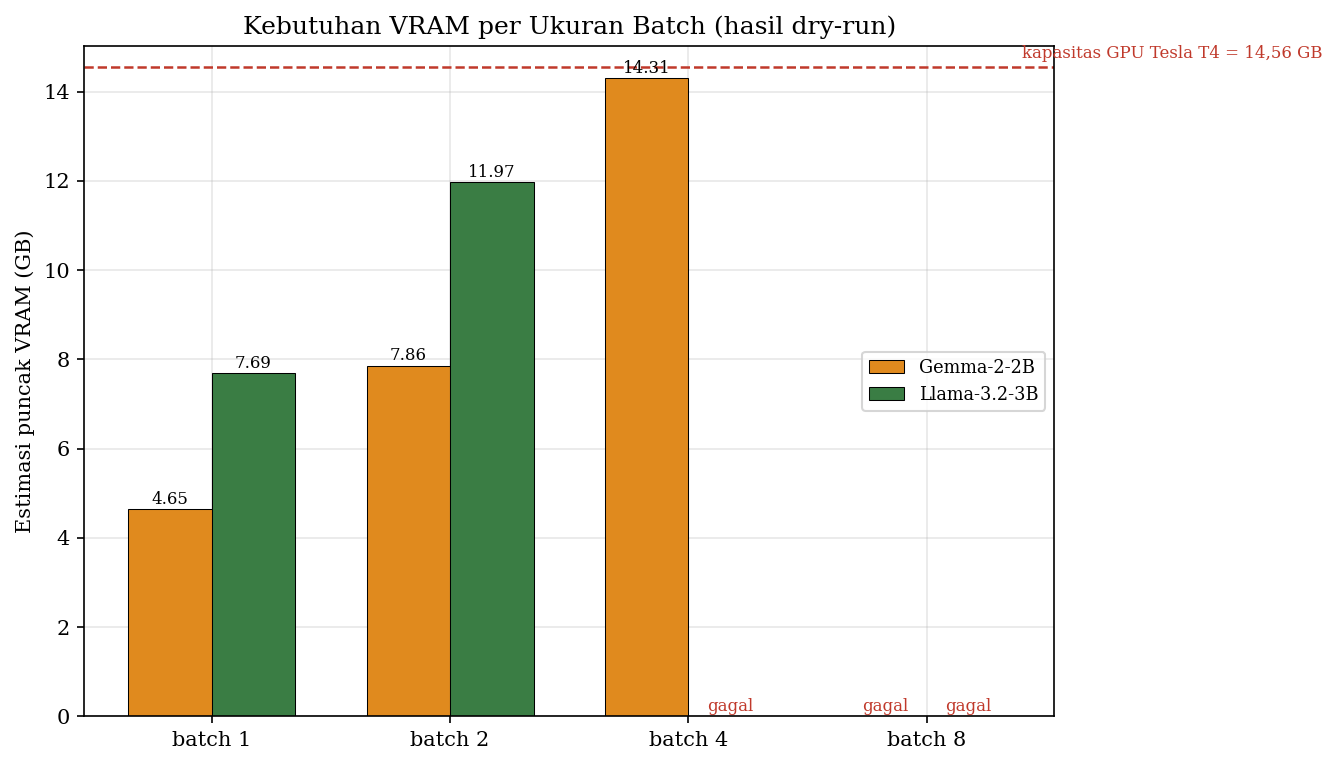

In [84]:
def fig28_vram():
    if not ada("training_config.json"):
        lewati("training_config.json belum tersedia — unduh dari HF repo untuk menampilkan estimasi VRAM.")
        return
    with open("training_config.json", encoding="utf-8") as f:
        cfg = json.load(f)

    baris = []
    for mk in MODEL_KEYS:
        est = (cfg.get(mk) or {}).get("vram_estimate_gb") or {}
        for bs, gb in est.items():
            baris.append({"model": mk, "batch_size": int(bs), "vram_gb": gb})
    if not baris:
        lewati("training_config.json tidak memuat kunci vram_estimate_gb.")
        return

    d = pd.DataFrame(baris)
    batch_list = sorted(d["batch_size"].unique())
    x = np.arange(len(batch_list)); w = .35
    fig, ax = plt.subplots(figsize=(9, 5.2))
    for i, (mk, warna) in enumerate([("gemma2", C_GEMMA), ("llama3.2", C_LLAMA)]):
        sub = d[d["model"] == mk].set_index("batch_size").reindex(batch_list)
        nilai = [v if pd.notna(v) else 0 for v in sub["vram_gb"]]
        ax.bar(x + (i - .5) * w, nilai, w, color=warna, edgecolor="black",
               linewidth=.5, label=MODEL_LABELS[mk])
        for xi, (v, asli) in zip(x + (i - .5) * w, zip(nilai, sub["vram_gb"])):
            teks = f"{v:.2f}" if pd.notna(asli) else "gagal"
            ax.text(xi, v + .12, teks, ha="center", fontsize=8,
                    color="black" if pd.notna(asli) else C_DROP)
    ax.axhline(14.562, ls="--", color=C_DROP, lw=1.2)
    ax.text(len(batch_list) - .6, 14.75, "kapasitas GPU Tesla T4 = 14,56 GB", fontsize=8, color=C_DROP)
    ax.set_xticks(x); ax.set_xticklabels([f"batch {b}" for b in batch_list])
    ax.set_ylabel("Estimasi puncak VRAM (GB)")
    ax.set_title("Kebutuhan VRAM per Ukuran Batch (hasil dry-run)"); ax.legend(fontsize=8.5)
    plt.tight_layout(); plt.savefig("fig28_vram.png", bbox_inches="tight"); plt.show()

fig28_vram()

### Gambar 29 — Kurva loss pelatihan dan validasi ★
Grafik utama dinamika pelatihan. Loss dicatat setiap 50 langkah (24 titik per model, 1.224 langkah total = 3 epoch). Kedua model menunjukkan penurunan yang mulus tanpa lonjakan divergensi; loss validasi mendatar setelah sekitar langkah 800, menandakan titik jenuh pembelajaran.

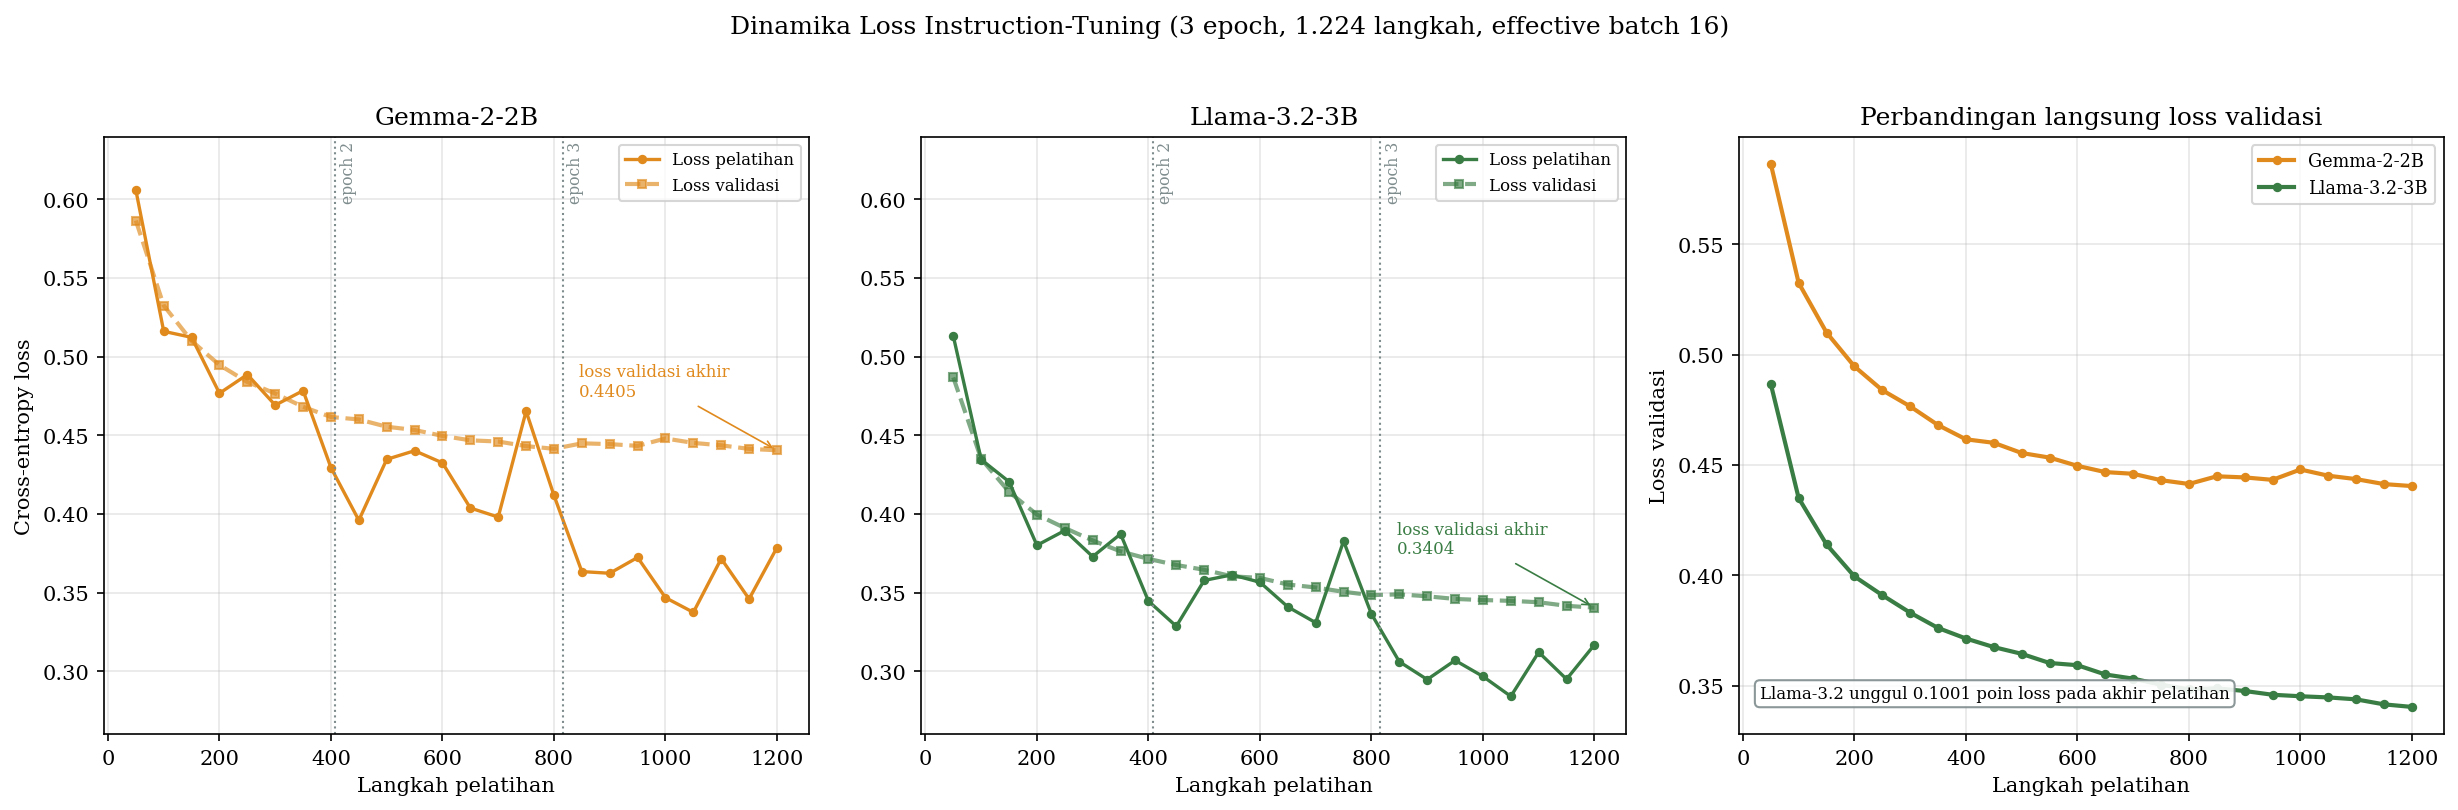

In [85]:
def fig29_kurva_loss():
    fig, axes = plt.subplots(1, 3, figsize=(16.5, 5.2), gridspec_kw={"width_ratios": [1, 1, 1]})

    for ax, mk, warna in [(axes[0], "gemma2", C_GEMMA), (axes[1], "llama3.2", C_LLAMA)]:
        ax.plot(LOSS_STEPS, LOSS_HISTORY[mk]["train"], color=warna, lw=1.6, marker="o", ms=3.5,
                label="Loss pelatihan")
        ax.plot(LOSS_STEPS, LOSS_HISTORY[mk]["val"], color=warna, lw=2, ls="--", marker="s", ms=3.5,
                alpha=.65, label="Loss validasi")
        for e in (1, 2):
            ax.axvline(e * STEP_PER_EPOCH, ls=":", color=C_MUTED, lw=1)
            ax.text(e * STEP_PER_EPOCH + 8, .60, f"epoch {e + 1}", fontsize=7.5, color=C_MUTED, rotation=90)
        akhir_val = LOSS_HISTORY[mk]["val"][-1]
        ax.annotate(f"loss validasi akhir\n{akhir_val:.4f}", xy=(LOSS_STEPS[-1], akhir_val),
                    xytext=(-95, 26), textcoords="offset points", fontsize=8, color=warna,
                    arrowprops=dict(arrowstyle="->", color=warna, lw=.8))
        ax.set_xlabel("Langkah pelatihan"); ax.set_ylim(.26, .64)
        ax.set_title(MODEL_LABELS[mk]); ax.legend(fontsize=8)
    axes[0].set_ylabel("Cross-entropy loss")

    ax = axes[2]
    for mk, warna in [("gemma2", C_GEMMA), ("llama3.2", C_LLAMA)]:
        ax.plot(LOSS_STEPS, LOSS_HISTORY[mk]["val"], color=warna, lw=2, marker="o", ms=3.5,
                label=f"{MODEL_LABELS[mk]}")
    ax.set_xlabel("Langkah pelatihan"); ax.set_ylabel("Loss validasi")
    ax.set_title("Perbandingan langsung loss validasi"); ax.legend(fontsize=8.5, loc="upper right")
    selisih = LOSS_HISTORY["gemma2"]["val"][-1] - LOSS_HISTORY["llama3.2"]["val"][-1]
    ax.text(.03, .06, f"Llama-3.2 unggul {selisih:.4f} poin loss pada akhir pelatihan",
            transform=ax.transAxes, ha="left", fontsize=8,
            bbox=dict(boxstyle="round,pad=.3", facecolor="white", edgecolor=C_MUTED, alpha=.9))

    fig.suptitle("Dinamika Loss Instruction-Tuning (3 epoch, 1.224 langkah, effective batch 16)", y=1.03)
    plt.tight_layout(); plt.savefig("fig29_kurva_loss.png", bbox_inches="tight"); plt.show()

fig29_kurva_loss()

### Gambar 30 — Konvergensi dan indikasi overfitting
Panel (a) menunjukkan penurunan loss validasi relatif terhadap titik ukur pertama. Panel (b) memantau selisih loss validasi dikurangi loss pelatihan: nilai yang berubah dari negatif menjadi positif menandakan model mulai menghafal data latih, sehingga menjadi dasar pertimbangan untuk tidak menambah epoch.

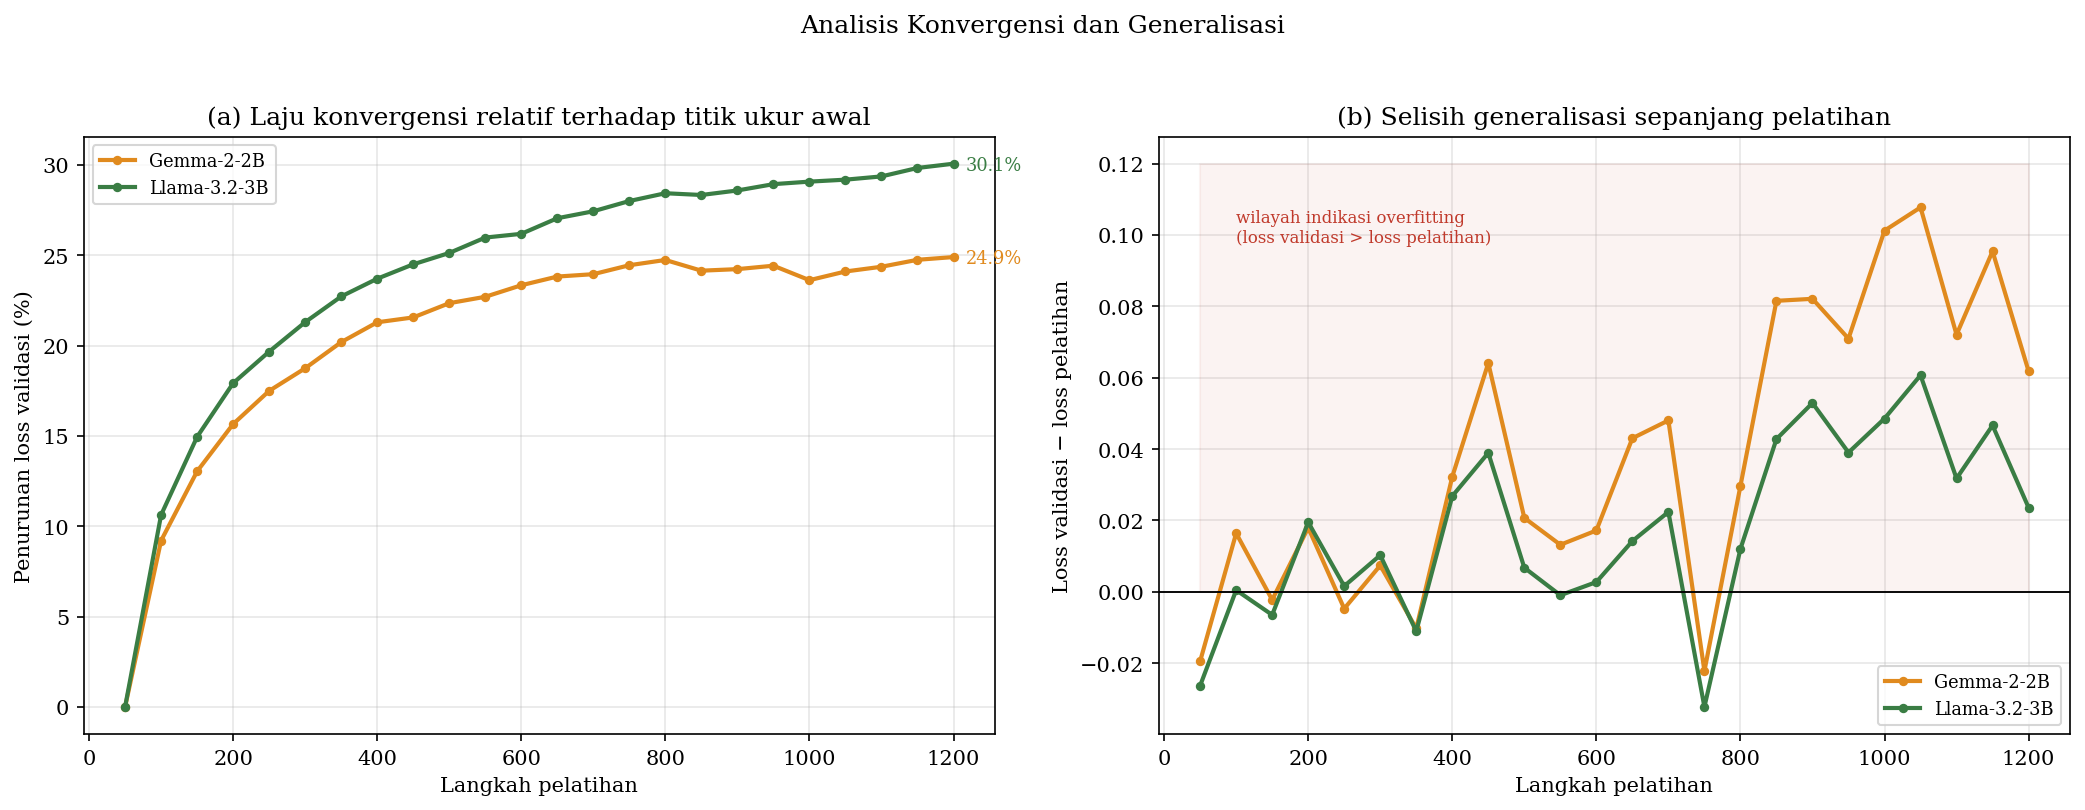

In [86]:
def fig30_konvergensi():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

    ax = axes[0]
    for mk, warna in [("gemma2", C_GEMMA), ("llama3.2", C_LLAMA)]:
        val = np.array(LOSS_HISTORY[mk]["val"])
        turun = 100 * (val[0] - val) / val[0]
        ax.plot(LOSS_STEPS, turun, color=warna, lw=2, marker="o", ms=3.5, label=MODEL_LABELS[mk])
        ax.annotate(f"{turun[-1]:.1f}%", xy=(LOSS_STEPS[-1], turun[-1]), xytext=(6, -3),
                    textcoords="offset points", fontsize=8.5, color=warna)
    ax.set_xlabel("Langkah pelatihan"); ax.set_ylabel("Penurunan loss validasi (%)")
    ax.set_title("(a) Laju konvergensi relatif terhadap titik ukur awal"); ax.legend(fontsize=8.5)

    ax = axes[1]
    for mk, warna in [("gemma2", C_GEMMA), ("llama3.2", C_LLAMA)]:
        gap = np.array(LOSS_HISTORY[mk]["val"]) - np.array(LOSS_HISTORY[mk]["train"])
        ax.plot(LOSS_STEPS, gap, color=warna, lw=2, marker="o", ms=3.5, label=MODEL_LABELS[mk])
    ax.axhline(0, color="black", lw=.9)
    ax.fill_between(LOSS_STEPS, 0, .12, color=C_DROP, alpha=.06)
    ax.text(LOSS_STEPS[1], .098, "wilayah indikasi overfitting\n(loss validasi > loss pelatihan)",
            fontsize=8, color=C_DROP)
    ax.set_xlabel("Langkah pelatihan"); ax.set_ylabel("Loss validasi − loss pelatihan")
    ax.set_title("(b) Selisih generalisasi sepanjang pelatihan"); ax.legend(fontsize=8.5, loc="lower right")

    fig.suptitle("Analisis Konvergensi dan Generalisasi", y=1.03)
    plt.tight_layout(); plt.savefig("fig30_konvergensi.png", bbox_inches="tight"); plt.show()

fig30_konvergensi()

### Gambar 31 — Efisiensi pelatihan: waktu, throughput, dan beban komputasi

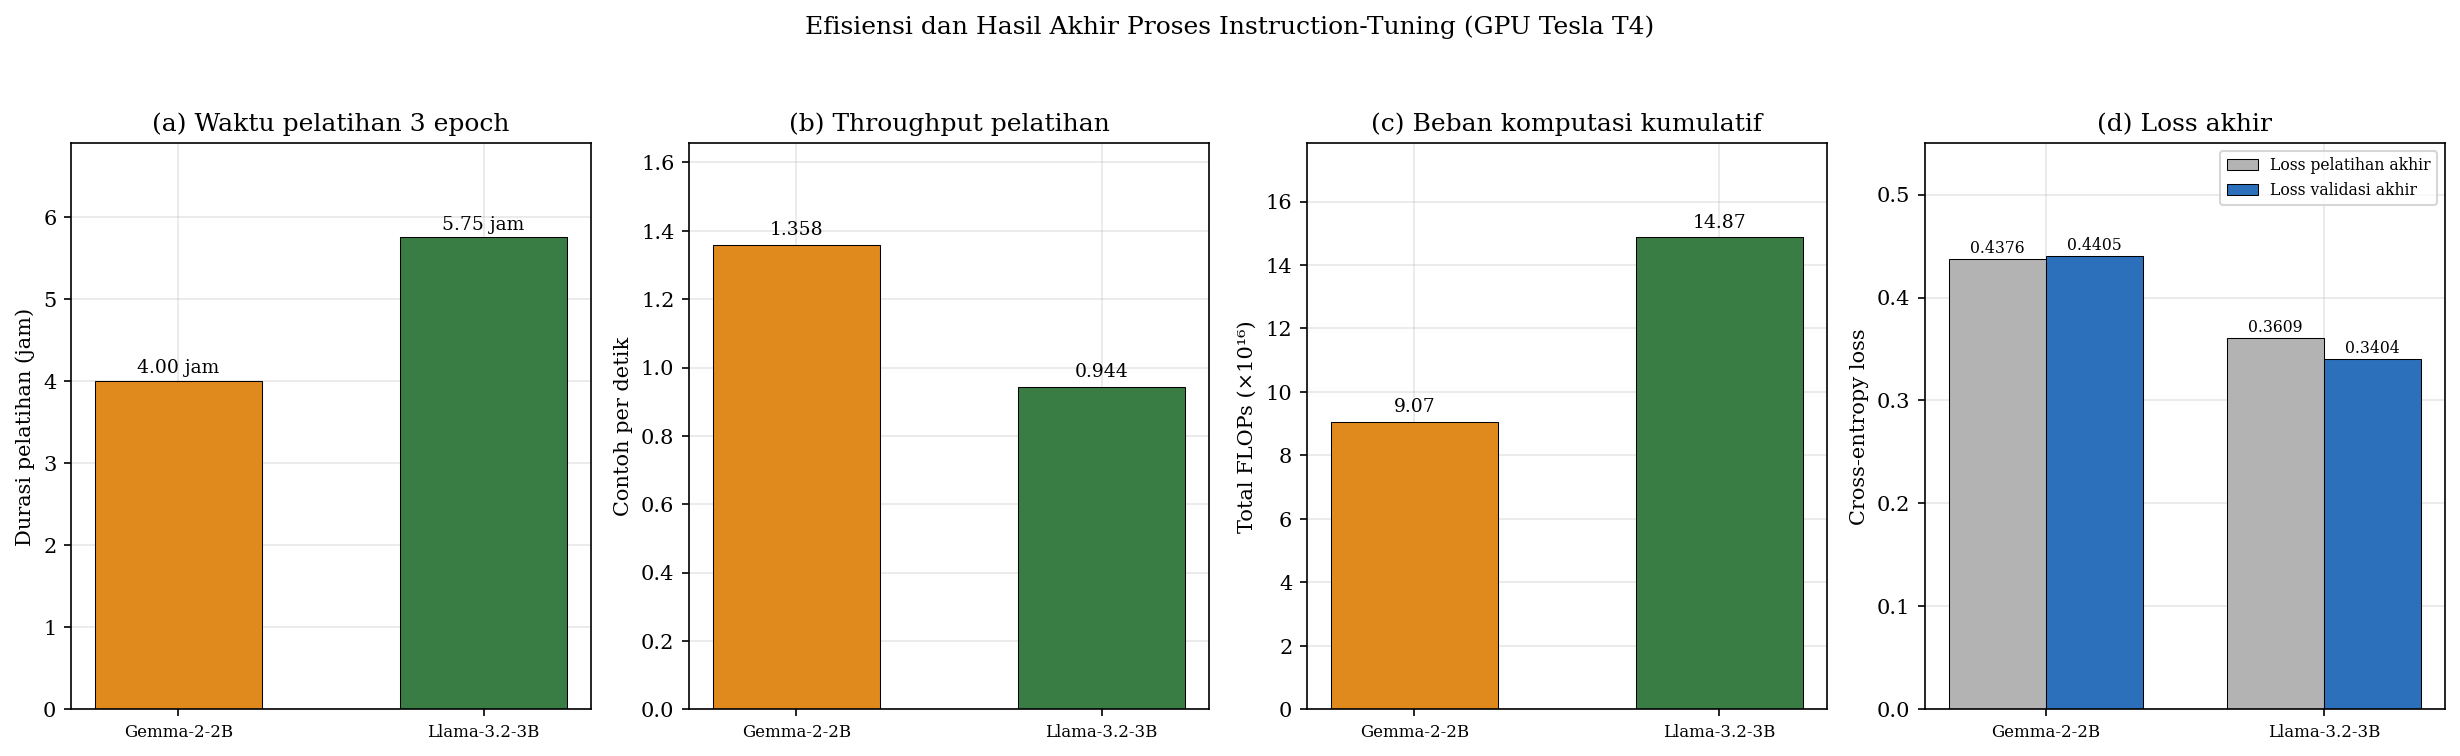

In [87]:
def fig31_efisiensi_training():
    fig, axes = plt.subplots(1, 4, figsize=(16.5, 4.8))
    warna = [C_GEMMA, C_LLAMA]
    label = [MODEL_LABELS[m] for m in TRAIN_META.index]

    ax = axes[0]
    jam = TRAIN_META["train_runtime_sec"] / 3600
    ax.bar(label, jam, color=warna, edgecolor="black", linewidth=.5, width=.55)
    for i, v in enumerate(jam):
        ax.text(i, v + .1, f"{v:.2f} jam", ha="center", fontsize=9)
    ax.set_ylabel("Durasi pelatihan (jam)"); ax.set_ylim(0, jam.max() * 1.2)
    ax.set_title("(a) Waktu pelatihan 3 epoch")
    ax.tick_params(axis="x", labelsize=8)

    ax = axes[1]
    ax.bar(label, TRAIN_META["samples_per_sec"], color=warna, edgecolor="black", linewidth=.5, width=.55)
    for i, v in enumerate(TRAIN_META["samples_per_sec"]):
        ax.text(i, v + .03, f"{v:.3f}", ha="center", fontsize=9)
    ax.set_ylabel("Contoh per detik"); ax.set_ylim(0, TRAIN_META["samples_per_sec"].max() * 1.22)
    ax.set_title("(b) Throughput pelatihan")
    ax.tick_params(axis="x", labelsize=8)

    ax = axes[2]
    flos = TRAIN_META["total_flos"] / 1e16
    ax.bar(label, flos, color=warna, edgecolor="black", linewidth=.5, width=.55)
    for i, v in enumerate(flos):
        ax.text(i, v + .3, f"{v:.2f}", ha="center", fontsize=9)
    ax.set_ylabel("Total FLOPs (×10¹⁶)"); ax.set_ylim(0, flos.max() * 1.2)
    ax.set_title("(c) Beban komputasi kumulatif")
    ax.tick_params(axis="x", labelsize=8)

    ax = axes[3]
    x = np.arange(len(TRAIN_META)); w = .35
    ax.bar(x - w / 2, TRAIN_META["final_train_loss"], w, color=C_BASE,
           edgecolor="black", linewidth=.5, label="Loss pelatihan akhir")
    ax.bar(x + w / 2, TRAIN_META["final_eval_loss"], w, color=C_FT,
           edgecolor="black", linewidth=.5, label="Loss validasi akhir")
    for xi, v in zip(x - w / 2, TRAIN_META["final_train_loss"]):
        ax.text(xi, v + .006, f"{v:.4f}", ha="center", fontsize=7.5)
    for xi, v in zip(x + w / 2, TRAIN_META["final_eval_loss"]):
        ax.text(xi, v + .006, f"{v:.4f}", ha="center", fontsize=7.5)
    ax.set_xticks(x); ax.set_xticklabels(label, fontsize=8)
    ax.set_ylabel("Cross-entropy loss"); ax.set_ylim(0, .55)
    ax.set_title("(d) Loss akhir"); ax.legend(fontsize=7.5)

    fig.suptitle("Efisiensi dan Hasil Akhir Proses Instruction-Tuning (GPU Tesla T4)", y=1.04)
    plt.tight_layout(); plt.savefig("fig31_efisiensi_training.png", bbox_inches="tight"); plt.show()

fig31_efisiensi_training()

### Gambar 32 — Efisiensi parameter: proporsi bobot yang benar-benar dilatih
Dengan QLoRA, kurang dari satu persen parameter model diperbarui. Ini menjadi argumen utama kelayakan pendekatan pada perangkat keras terbatas.

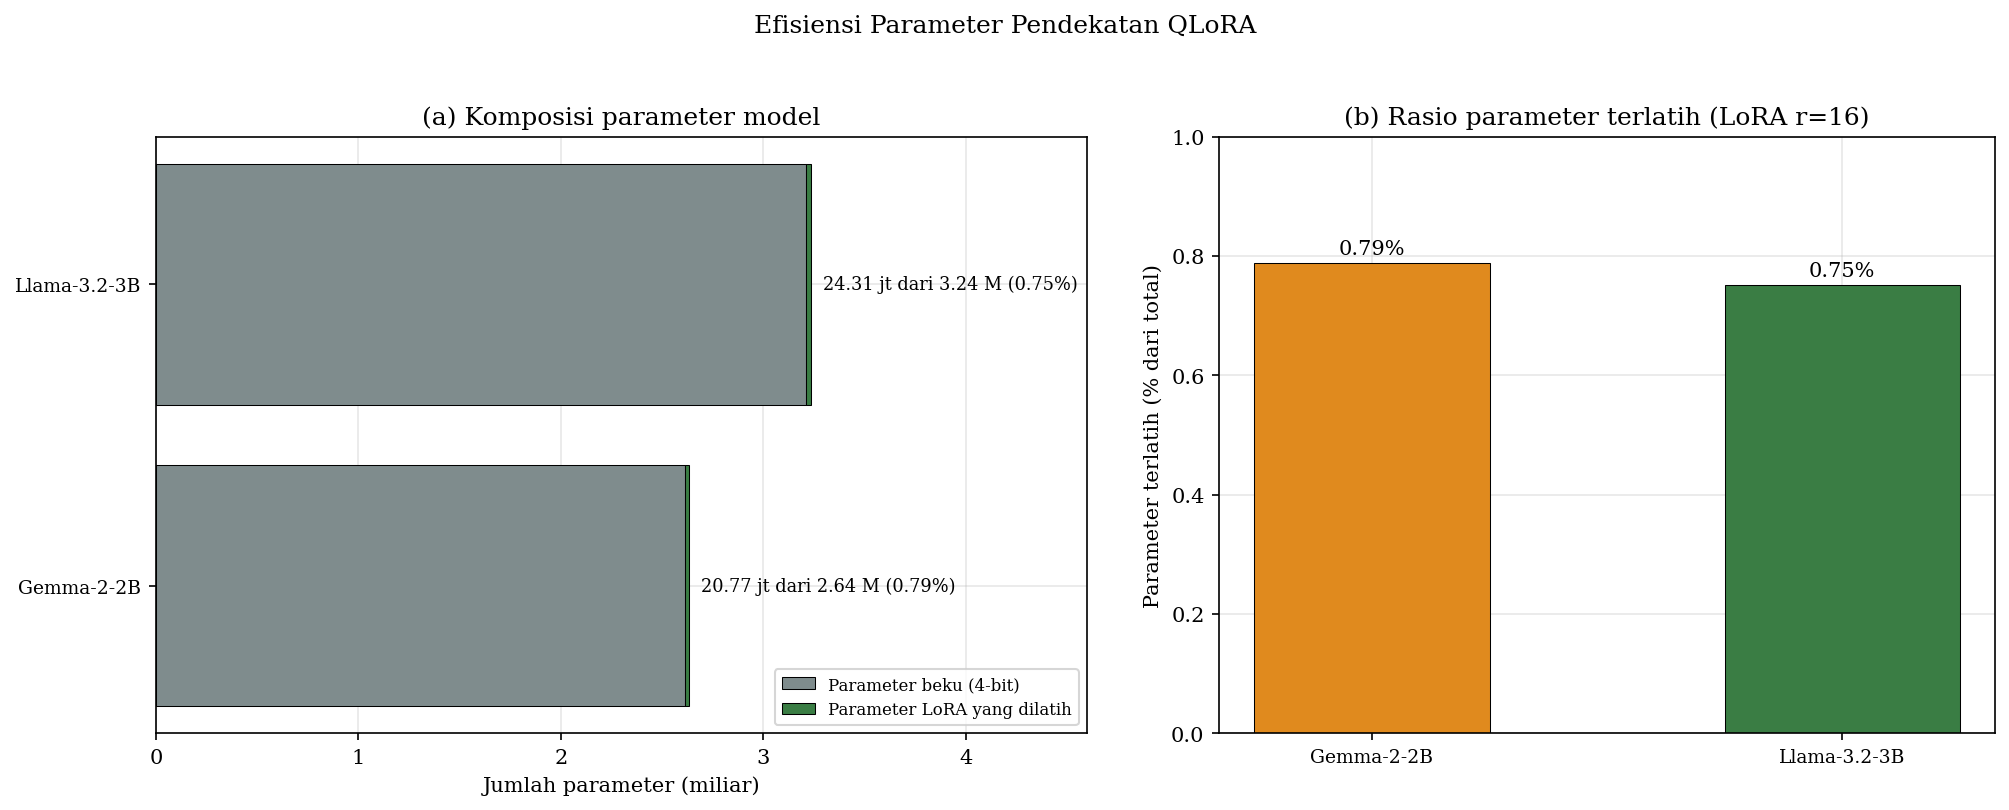

In [88]:
def fig32_efisiensi_parameter():
    fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2), gridspec_kw={"width_ratios": [1.2, 1]})

    ax = axes[0]
    y = np.arange(len(TRAIN_META))
    beku = (TRAIN_META["total_params"] - TRAIN_META["trainable_params"]) / 1e9
    latih = TRAIN_META["trainable_params"] / 1e9
    ax.barh(y, beku, color=C_MUTED, edgecolor="black", linewidth=.5, label="Parameter beku (4-bit)")
    ax.barh(y, latih, left=beku, color=C_KEEP, edgecolor="black", linewidth=.5,
            label="Parameter LoRA yang dilatih")
    for yi, mk in enumerate(TRAIN_META.index):
        total = TRAIN_META.loc[mk, "total_params"]
        trainable = TRAIN_META.loc[mk, "trainable_params"]
        ax.text(total / 1e9 + .06, yi, f"{trainable / 1e6:.2f} jt dari {total / 1e9:.2f} M "
                f"({100 * trainable / total:.2f}%)", va="center", fontsize=8.5)
    ax.set_yticks(y); ax.set_yticklabels([MODEL_LABELS[m] for m in TRAIN_META.index], fontsize=9)
    ax.set_xlabel("Jumlah parameter (miliar)"); ax.set_xlim(0, 4.6)
    ax.set_title("(a) Komposisi parameter model"); ax.legend(fontsize=8, loc="lower right")

    ax = axes[1]
    persen = 100 * TRAIN_META["trainable_params"] / TRAIN_META["total_params"]
    ax.bar([MODEL_LABELS[m] for m in TRAIN_META.index], persen,
           color=[C_GEMMA, C_LLAMA], edgecolor="black", linewidth=.5, width=.5)
    for i, v in enumerate(persen):
        ax.text(i, v + .015, f"{v:.2f}%", ha="center", fontsize=10)
    ax.set_ylabel("Parameter terlatih (% dari total)"); ax.set_ylim(0, 1)
    ax.set_title("(b) Rasio parameter terlatih (LoRA r=16)")
    ax.tick_params(axis="x", labelsize=9)

    fig.suptitle("Efisiensi Parameter Pendekatan QLoRA", y=1.03)
    plt.tight_layout(); plt.savefig("fig32_efisiensi_parameter.png", bbox_inches="tight"); plt.show()

fig32_efisiensi_parameter()

### Gambar 33 — Waktu inferensi pada data uji
Seluruh generasi memakai *greedy decoding* (`do_sample=False`, `max_new_tokens=512`, batch 8) sehingga hasilnya deterministik. **Catatan penting:** notebook Gemma-2 berjalan pada dua GPU sedangkan Llama-3.2 pada satu GPU, sehingga perbandingan waktu antar-model tidak setara; yang valid dibandingkan adalah base versus fine-tuned dalam model yang sama.

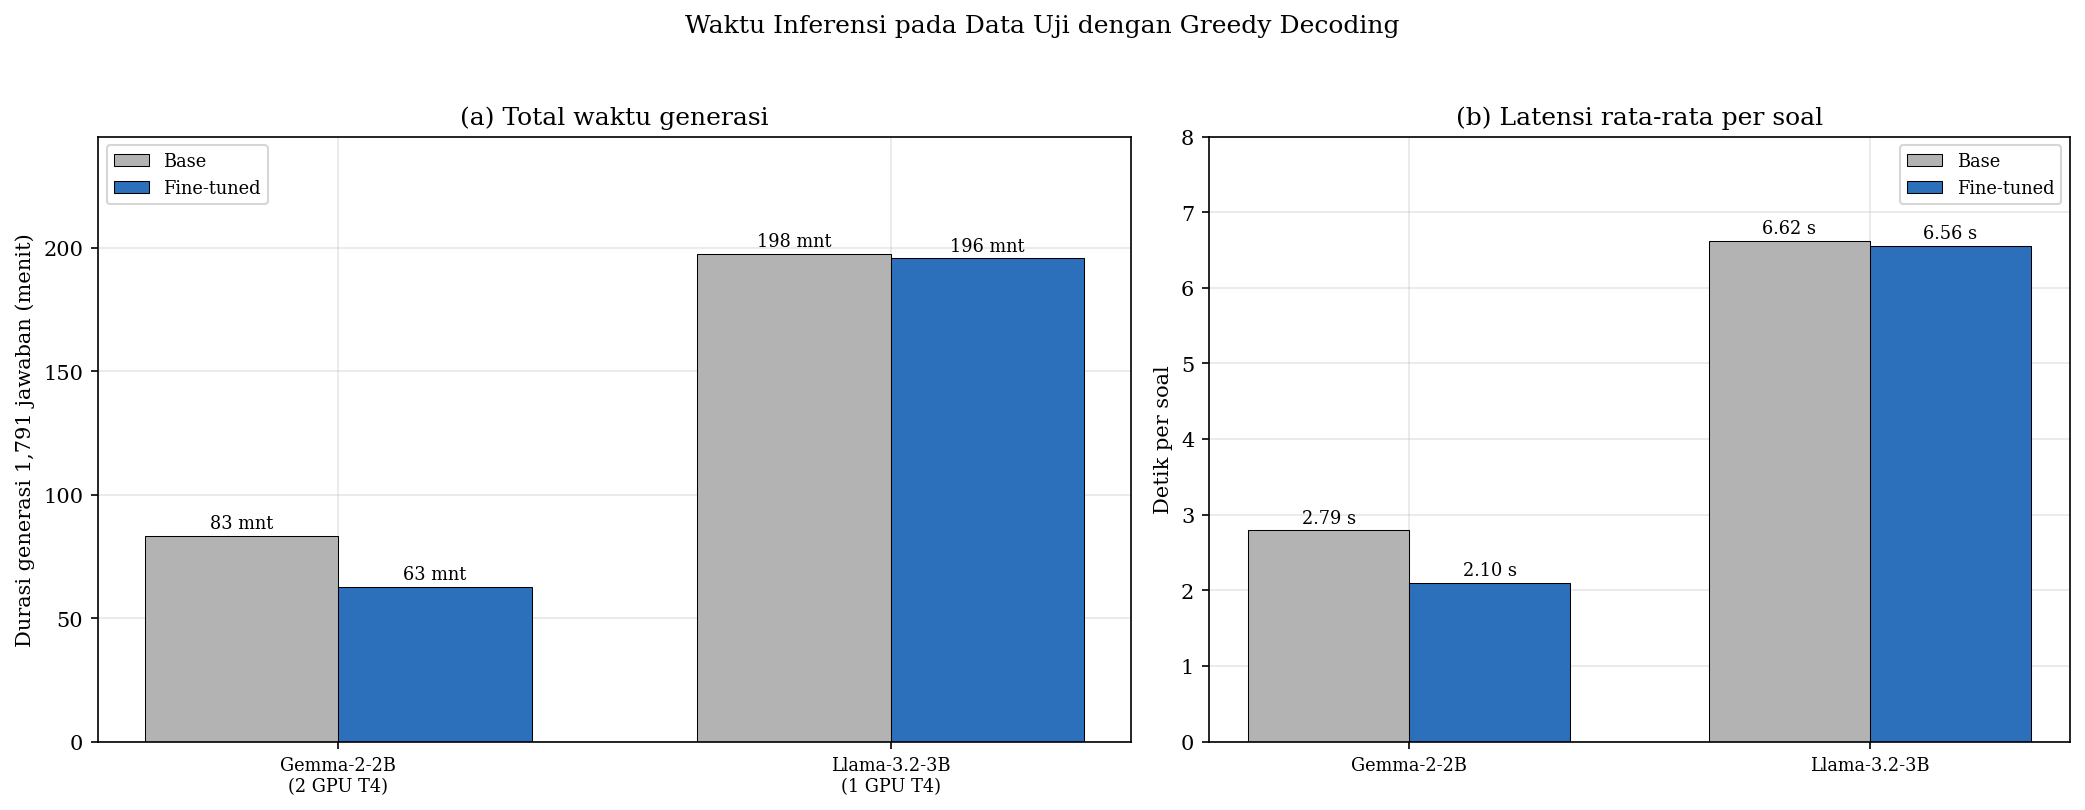

In [89]:
def fig33_waktu_inferensi():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), gridspec_kw={"width_ratios": [1.2, 1]})

    ax = axes[0]
    x = np.arange(len(MODEL_KEYS)); w = .35
    for i, (cond, warna) in enumerate([("base", C_BASE), ("finetuned", C_FT)]):
        nilai = [INFERENSI.query("model == @mk and condition == @cond")["durasi_detik"].iloc[0] / 60
                 for mk in MODEL_KEYS]
        ax.bar(x + (i - .5) * w, nilai, w, color=warna, edgecolor="black",
               linewidth=.5, label="Base" if cond == "base" else "Fine-tuned")
        for xi, v in zip(x + (i - .5) * w, nilai):
            ax.text(xi, v + 3, f"{v:.0f} mnt", ha="center", fontsize=8.5)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{MODEL_LABELS[mk]}\n({INFERENSI.query('model == @mk')['n_gpu'].iloc[0]} GPU T4)"
                        for mk in MODEL_KEYS], fontsize=8.5)
    ax.set_ylabel(f"Durasi generasi {N_TEST:,} jawaban (menit)")
    ax.set_ylim(0, 245); ax.set_title("(a) Total waktu generasi")
    ax.legend(fontsize=8.5, loc="upper left")

    ax = axes[1]
    d = INFERENSI.copy()
    d["detik_per_soal"] = d["durasi_detik"] / N_TEST
    for i, (cond, warna) in enumerate([("base", C_BASE), ("finetuned", C_FT)]):
        nilai = [d.query("model == @mk and condition == @cond")["detik_per_soal"].iloc[0] for mk in MODEL_KEYS]
        ax.bar(x + (i - .5) * w, nilai, w, color=warna, edgecolor="black",
               linewidth=.5, label="Base" if cond == "base" else "Fine-tuned")
        for xi, v in zip(x + (i - .5) * w, nilai):
            ax.text(xi, v + .1, f"{v:.2f} s", ha="center", fontsize=8.5)
    ax.set_xticks(x); ax.set_xticklabels([MODEL_LABELS[mk] for mk in MODEL_KEYS], fontsize=8.5)
    ax.set_ylabel("Detik per soal"); ax.set_ylim(0, 8)
    ax.set_title("(b) Latensi rata-rata per soal"); ax.legend(fontsize=8.5)

    fig.suptitle("Waktu Inferensi pada Data Uji dengan Greedy Decoding", y=1.03)
    plt.tight_layout(); plt.savefig("fig33_waktu_inferensi.png", bbox_inches="tight"); plt.show()

fig33_waktu_inferensi()

### Gambar 34 — Perubahan gaya menjawab setelah instruction-tuning *(opsional)*
Dihitung langsung dari berkas prediksi. Grafik ini memperlihatkan salah satu efek instruction-tuning yang paling kasat mata: panjang dan format jawaban menjadi jauh lebih dekat dengan gaya jawaban referensi dibandingkan model base yang cenderung bertele-tele dan memakai penanda markdown.

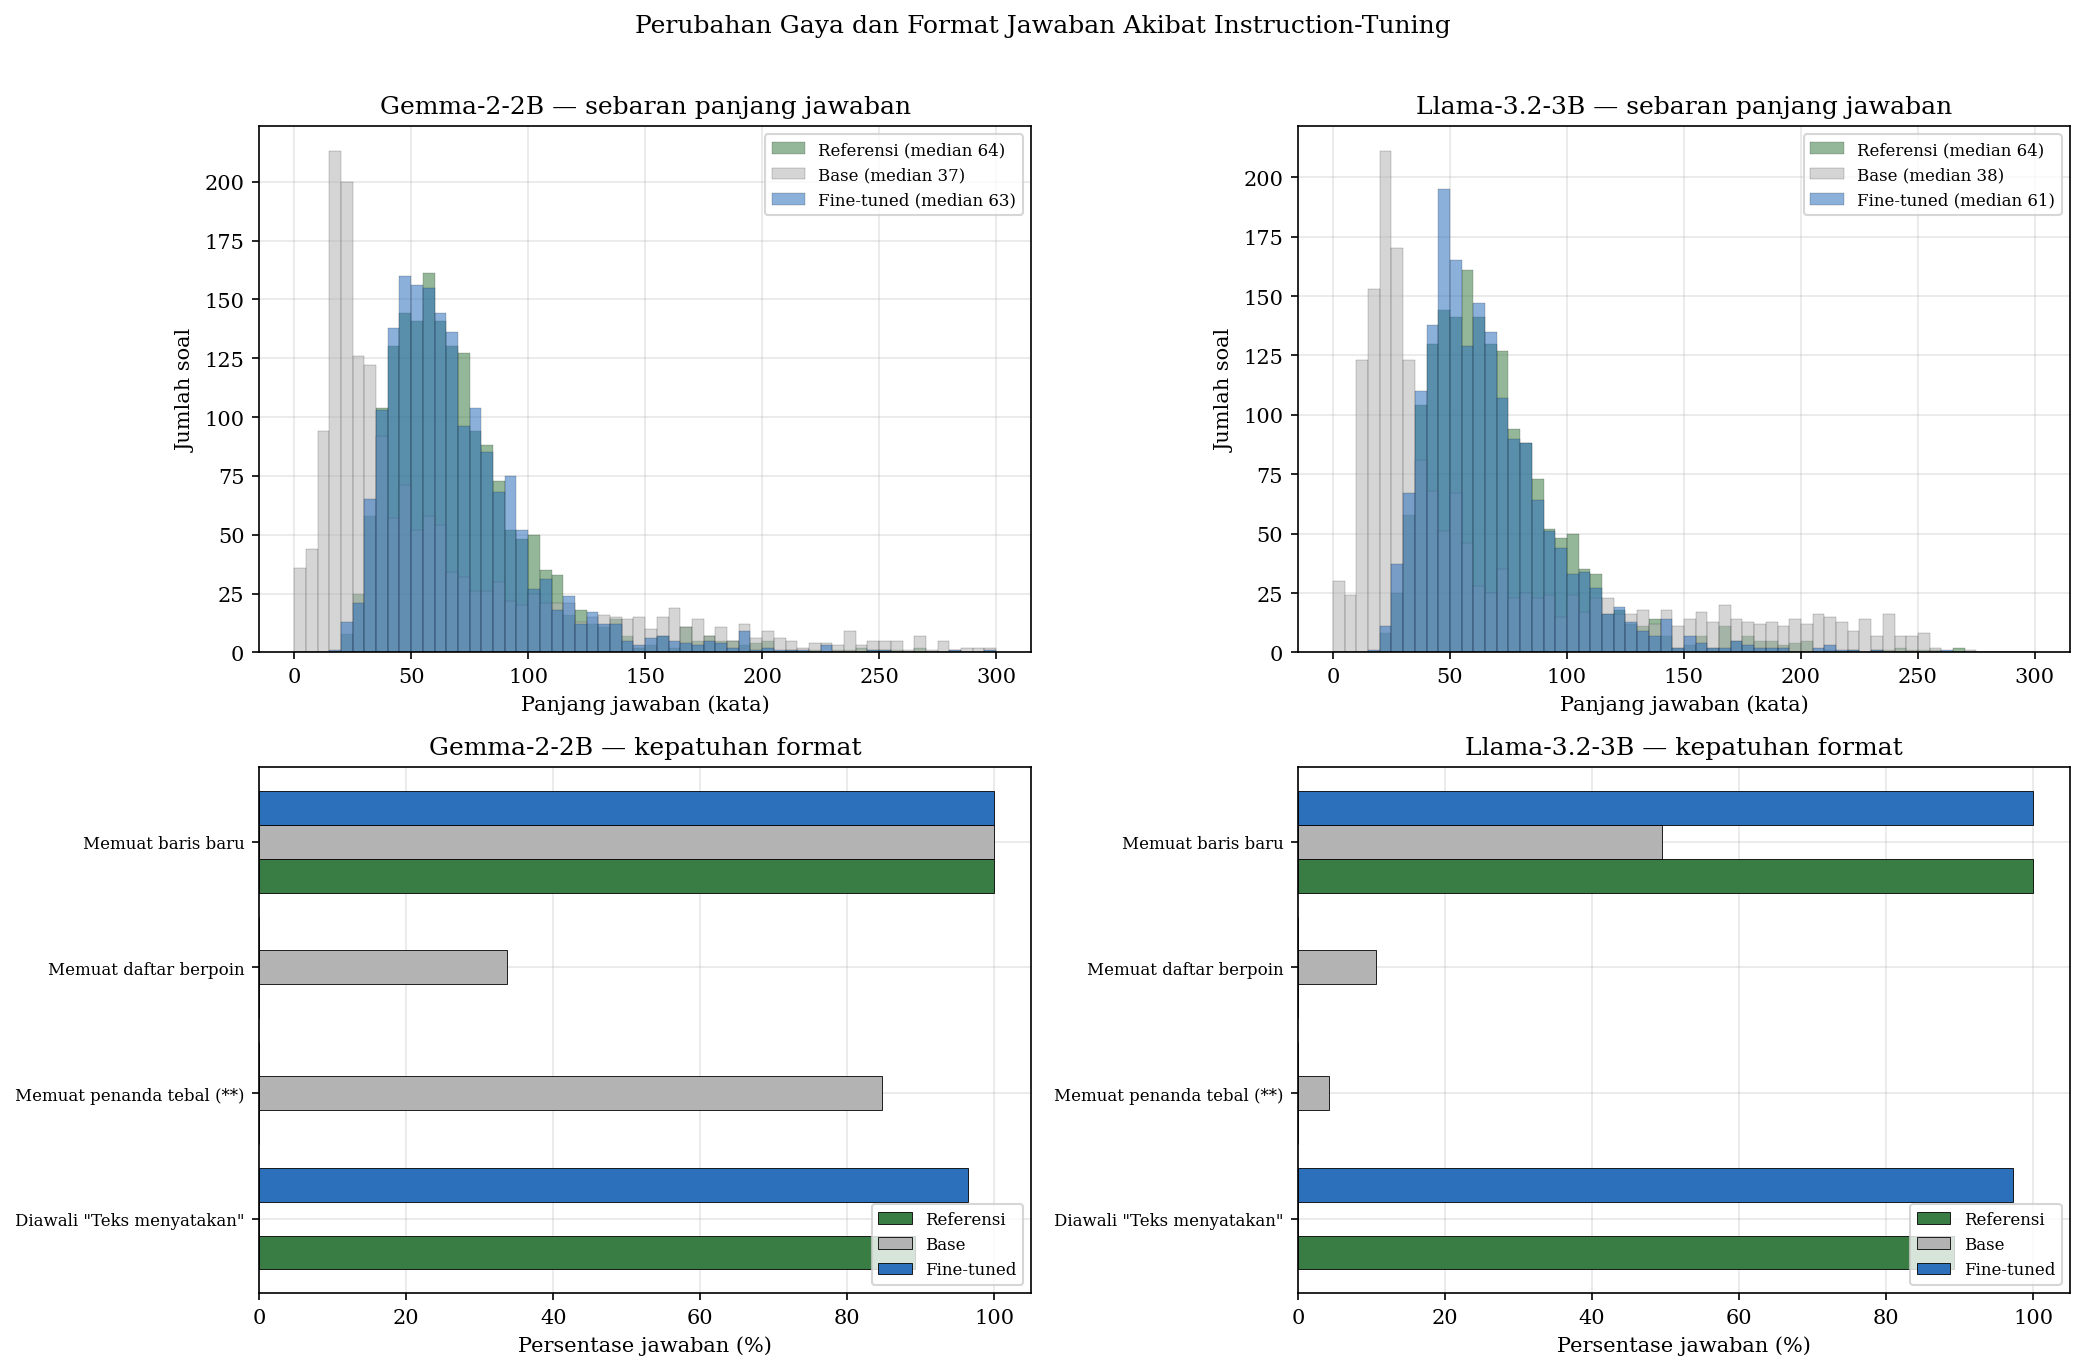

In [90]:
def fig34_gaya_jawaban():
    berkas = {mk: f"eval_{mk}_predictions.csv" for mk in MODEL_KEYS}
    tersedia = {mk: f for mk, f in berkas.items() if os.path.exists(f)}
    if not tersedia:
        lewati("eval_gemma2_predictions.csv / eval_llama3.2_predictions.csv belum tersedia.")
        return

    fig, axes = plt.subplots(2, len(tersedia), figsize=(7 * len(tersedia), 9), squeeze=False)
    for j, (mk, berkas_mk) in enumerate(tersedia.items()):
        df = pd.read_csv(berkas_mk)
        panjang = {
            "Referensi": df["ans_ref"].astype(str).str.split().str.len(),
            "Base": df["ans_pred_base"].astype(str).str.split().str.len(),
            "Fine-tuned": df["ans_pred_finetuned"].astype(str).str.split().str.len(),
        }

        ax = axes[0, j]
        for nama, warna in [("Referensi", C_KEEP), ("Base", C_BASE), ("Fine-tuned", C_FT)]:
            ax.hist(panjang[nama], bins=60, range=(0, 300), alpha=.55, color=warna,
                    edgecolor="black", linewidth=.15, label=f"{nama} (median {panjang[nama].median():.0f})")
        ax.set_xlabel("Panjang jawaban (kata)"); ax.set_ylabel("Jumlah soal")
        ax.set_title(f"{MODEL_LABELS[mk]} — sebaran panjang jawaban"); ax.legend(fontsize=8)

        ax = axes[1, j]
        pola = {
            "Diawali \"Teks menyatakan\"": lambda s: s.str.strip().str.lower().str.startswith("teks menyatakan"),
            "Memuat penanda tebal (**)": lambda s: s.str.contains(r"\*\*", regex=True, na=False),
            "Memuat daftar berpoin": lambda s: s.str.contains(r"(?:^|\n)\s*[-*•]\s", regex=True, na=False),
            "Memuat baris baru": lambda s: s.str.contains("\n", na=False),
        }
        nama_pola = list(pola.keys())
        y = np.arange(len(nama_pola)); w = .27
        for i, (kol, nama, warna) in enumerate([("ans_ref", "Referensi", C_KEEP),
                                                ("ans_pred_base", "Base", C_BASE),
                                                ("ans_pred_finetuned", "Fine-tuned", C_FT)]):
            s = df[kol].astype(str)
            nilai = [100 * pola[p](s).mean() for p in nama_pola]
            ax.barh(y + (i - 1) * w, nilai, w, color=warna, edgecolor="black", linewidth=.4, label=nama)
        ax.set_yticks(y); ax.set_yticklabels(nama_pola, fontsize=8)
        ax.set_xlabel("Persentase jawaban (%)"); ax.set_xlim(0, 105)
        ax.set_title(f"{MODEL_LABELS[mk]} — kepatuhan format"); ax.legend(fontsize=8, loc="lower right")

    fig.suptitle("Perubahan Gaya dan Format Jawaban Akibat Instruction-Tuning", y=1.01)
    plt.tight_layout(); plt.savefig("fig34_gaya_jawaban.png", bbox_inches="tight"); plt.show()

fig34_gaya_jawaban()

---
# Bagian 5 — Evaluasi Otomatis
Sumber: `tujuan2/[3] evaluation/11-compute-automatic-eval.ipynb`. Empat metrik dihitung pada 1.791 soal uji untuk empat kondisi (dua model × base/fine-tuned): Exact Match numerik (hanya soal yang referensinya mengandung bilangan — soal lain dikembalikan `None` dan tidak ikut rata-rata), Token F1, ROUGE-L, dan IndoBERTScore dengan encoder `firqaaa/indo-sentence-bert-base`.

In [91]:
# Pemuatan berkas hasil evaluasi otomatis
BERKAS_SUMMARY = "summary_metrics.csv"
summary = pd.read_csv(BERKAS_SUMMARY).set_index("model") if ada(BERKAS_SUMMARY) else None
if summary is None:
    lewati(f"{BERKAS_SUMMARY} belum tersedia — seluruh Bagian 5 akan dilewati.")

scored = {}
for mk in MODEL_KEYS:
    for cond in CONDITIONS:
        f = f"{mk}_{cond}_scored.csv"
        if os.path.exists(f):
            scored[(mk, cond)] = pd.read_csv(f)
ADA_SCORED = len(scored) == len(MODEL_KEYS) * len(CONDITIONS)
if not ADA_SCORED:
    lewati("Berkas *_scored.csv belum lengkap — grafik tingkat-soal akan dilewati.")

df_test = pd.read_csv("test.csv") if ada("test.csv") else None

def pasangan(model_key, metric):
    """Skor base dan fine-tuned yang dipasangkan berdasarkan record_id yang sama.
    Untuk EM (yang mengandung NaN pada soal non-numerik), baris NaN dibuang agar
    uji statistik berpasangan hanya mencakup soal yang terdefinisi."""
    a = scored[(model_key, "base")][["record_id", metric]].rename(columns={metric: "base"})
    b = scored[(model_key, "finetuned")][["record_id", metric]].rename(columns={metric: "finetuned"})
    merged = a.merge(b, on="record_id")
    return merged.dropna(subset=["base", "finetuned"]) if metric == "em" else merged

print(f"summary_metrics.csv: {'tersedia' if summary is not None else 'belum ada'} | "
      f"berkas skor tingkat-soal: {len(scored)}/4")

summary_metrics.csv: tersedia | berkas skor tingkat-soal: 4/4


### Gambar 35 — Ringkasan metrik otomatis: base versus fine-tuned

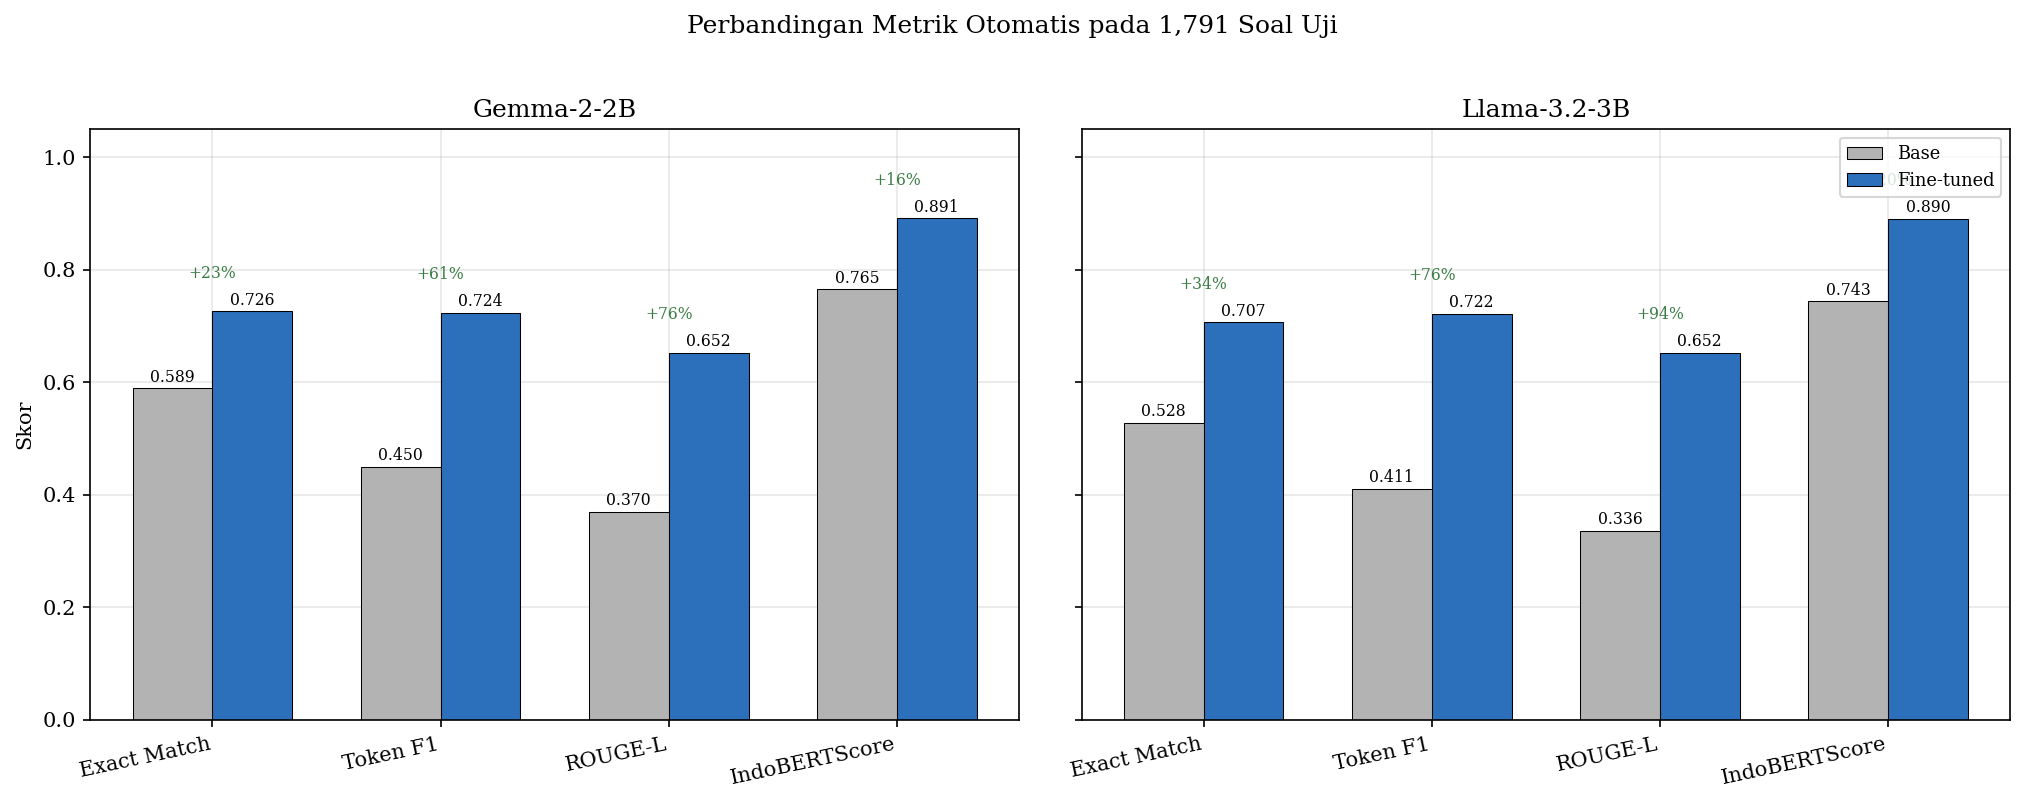

In [92]:
def fig35_ringkasan_metrik():
    if summary is None:
        lewati("summary_metrics.csv tidak tersedia."); return
    fig, axes = plt.subplots(1, len(MODEL_KEYS), figsize=(6.8 * len(MODEL_KEYS), 5.2), sharey=True)
    x = np.arange(len(METRICS)); w = .35
    for ax, mk in zip(axes, MODEL_KEYS):
        base = [summary.loc[f"{mk}_base", m] for m in METRICS]
        ft = [summary.loc[f"{mk}_finetuned", m] for m in METRICS]
        ax.bar(x - w / 2, base, w, color=C_BASE, edgecolor="black", linewidth=.5, label="Base")
        ax.bar(x + w / 2, ft, w, color=C_FT, edgecolor="black", linewidth=.5, label="Fine-tuned")
        for xi, v in zip(x - w / 2, base): ax.text(xi, v + .012, f"{v:.3f}", ha="center", fontsize=7.5)
        for xi, v in zip(x + w / 2, ft): ax.text(xi, v + .012, f"{v:.3f}", ha="center", fontsize=7.5)
        for xi, (b, f_) in enumerate(zip(base, ft)):
            if b > 0:
                ax.annotate(f"+{100 * (f_ - b) / b:.0f}%", xy=(xi, max(b, f_) + .06),
                            ha="center", fontsize=7.5, color=C_KEEP)
        ax.set_xticks(x); ax.set_xticklabels([METRIC_LABELS[m] for m in METRICS], rotation=12, ha="right")
        ax.set_title(MODEL_LABELS[mk]); ax.set_ylim(0, 1.05)
    axes[0].set_ylabel("Skor"); axes[-1].legend(fontsize=8.5, loc="upper right")
    fig.suptitle(f"Perbandingan Metrik Otomatis pada {N_TEST:,} Soal Uji", y=1.02)
    plt.tight_layout(); plt.savefig("fig35_ringkasan_metrik.png", bbox_inches="tight"); plt.show()

fig35_ringkasan_metrik()

### Gambar 36 — Besaran peningkatan akibat instruction-tuning

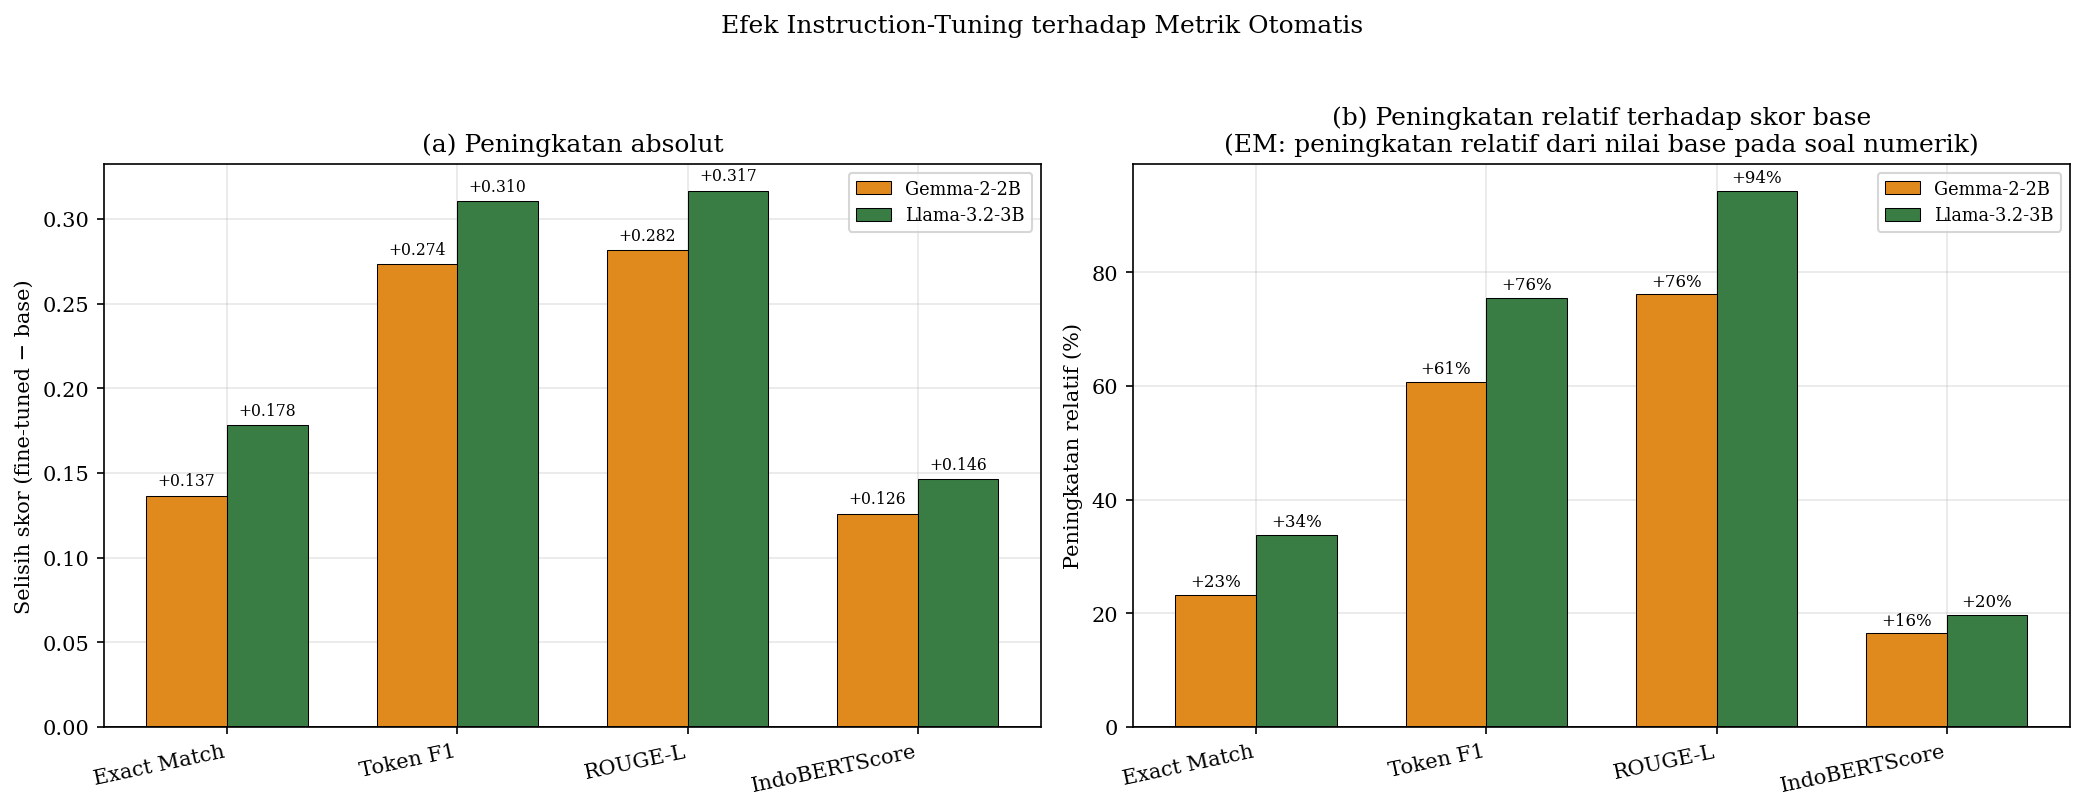

In [93]:
def fig36_delta_peningkatan():
    if summary is None:
        lewati("summary_metrics.csv tidak tersedia."); return
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

    ax = axes[0]
    x = np.arange(len(METRICS)); w = .35
    for i, (mk, warna) in enumerate([("gemma2", C_GEMMA), ("llama3.2", C_LLAMA)]):
        delta = [summary.loc[f"{mk}_finetuned", m] - summary.loc[f"{mk}_base", m] for m in METRICS]
        ax.bar(x + (i - .5) * w, delta, w, color=warna, edgecolor="black",
               linewidth=.5, label=MODEL_LABELS[mk])
        for xi, v in zip(x + (i - .5) * w, delta):
            ax.text(xi, v + (.006 if v >= 0 else -.018), f"{v:+.3f}", ha="center", fontsize=7.5)
    ax.axhline(0, color="black", lw=.8)
    ax.set_xticks(x); ax.set_xticklabels([METRIC_LABELS[m] for m in METRICS], rotation=12, ha="right")
    ax.set_ylabel("Selisih skor (fine-tuned − base)")
    ax.set_title("(a) Peningkatan absolut"); ax.legend(fontsize=8.5)

    ax = axes[1]
    for i, (mk, warna) in enumerate([("gemma2", C_GEMMA), ("llama3.2", C_LLAMA)]):
        rel = []
        for m in METRICS:
            b = summary.loc[f"{mk}_base", m]
            f_ = summary.loc[f"{mk}_finetuned", m]
            rel.append(100 * (f_ - b) / b if b > 0 else np.nan)
        ax.bar(x + (i - .5) * w, rel, w, color=warna, edgecolor="black",
               linewidth=.5, label=MODEL_LABELS[mk])
        for xi, v in zip(x + (i - .5) * w, rel):
            if pd.notna(v):
                ax.text(xi, v + 1.5, f"{v:+.0f}%", ha="center", fontsize=8)
    ax.axhline(0, color="black", lw=.8)
    ax.set_xticks(x); ax.set_xticklabels([METRIC_LABELS[m] for m in METRICS], rotation=12, ha="right")
    ax.set_ylabel("Peningkatan relatif (%)")
    ax.set_title("(b) Peningkatan relatif terhadap skor base\n(EM: peningkatan relatif dari nilai base pada soal numerik)")
    ax.legend(fontsize=8.5)

    fig.suptitle("Efek Instruction-Tuning terhadap Metrik Otomatis", y=1.03)
    plt.tight_layout(); plt.savefig("fig36_delta_peningkatan.png", bbox_inches="tight"); plt.show()

fig36_delta_peningkatan()

### Gambar 37 — Sebaran skor tingkat-soal
Nilai rata-rata dapat menyembunyikan keragaman antar soal. Boxplot berikut menampilkan seluruh distribusi 1.791 skor per kondisi, sehingga terlihat apakah peningkatan terjadi merata atau hanya pada sebagian soal.

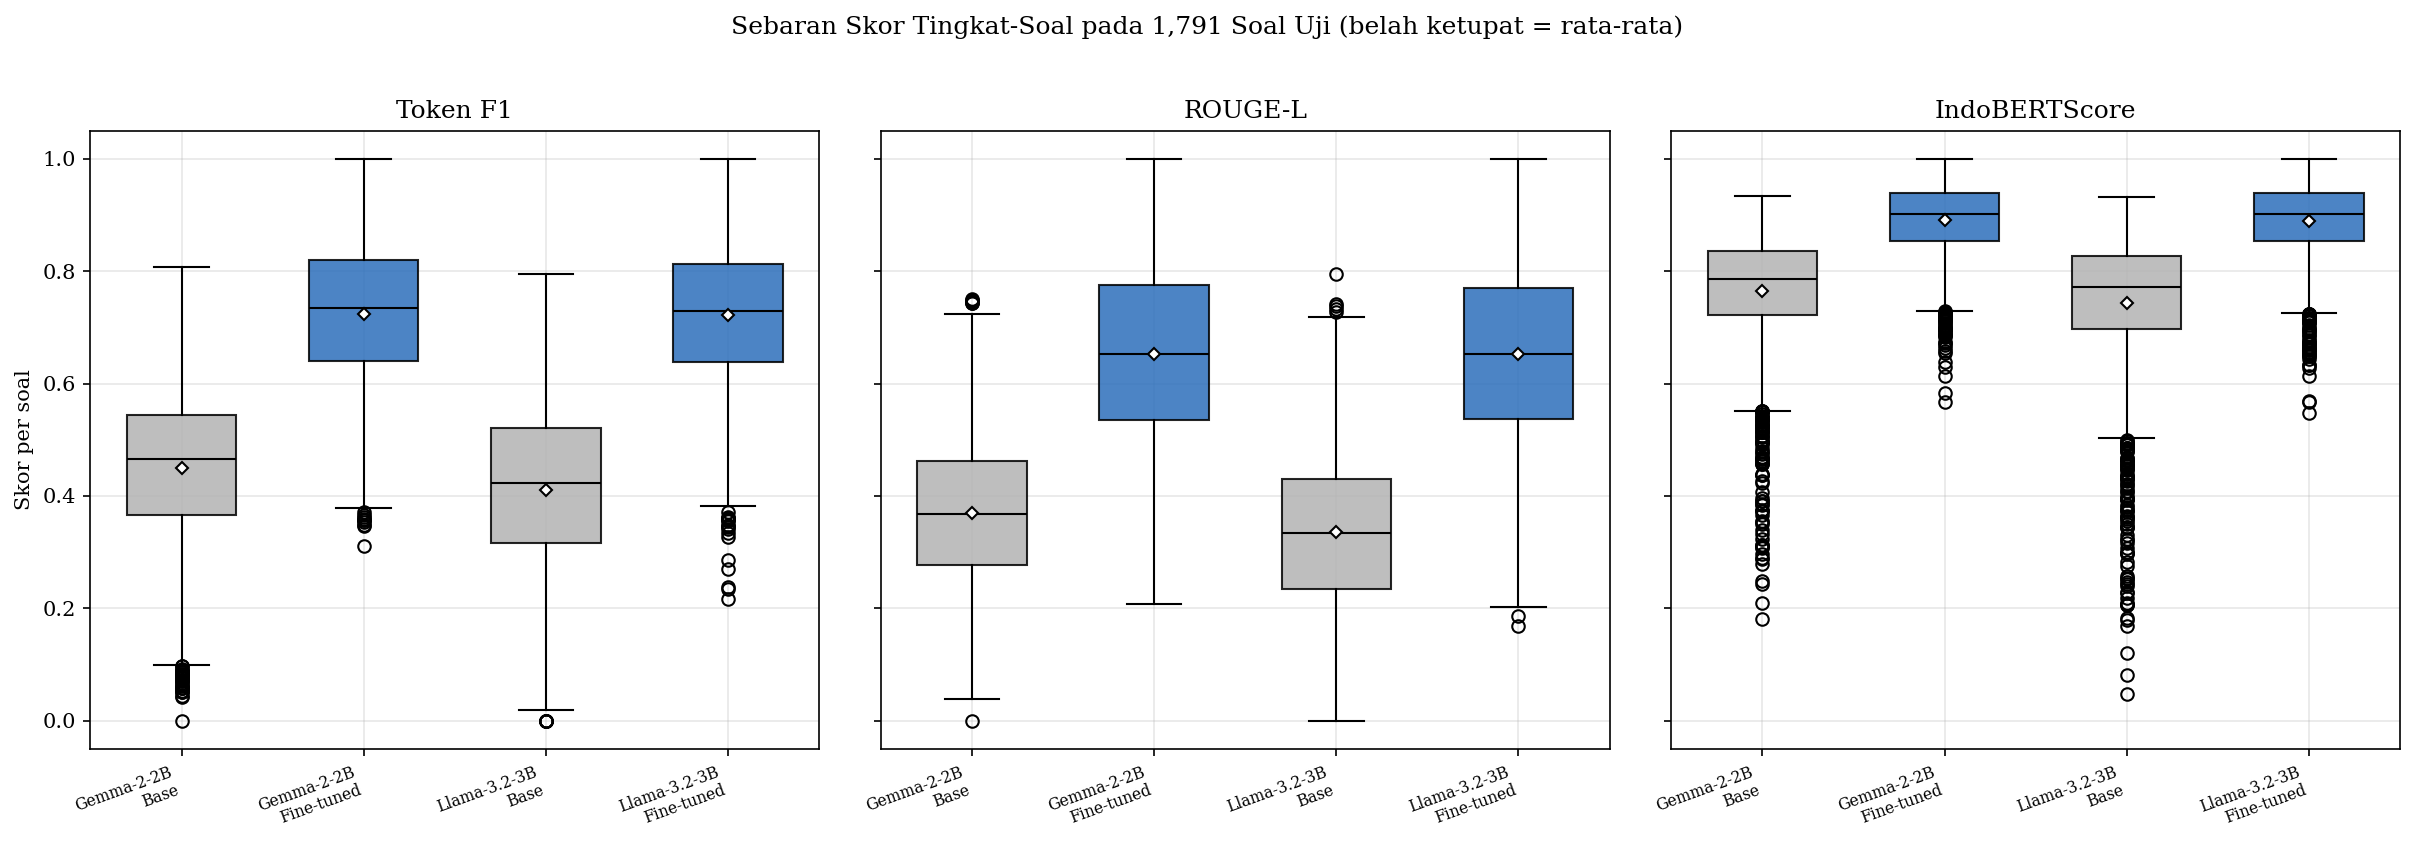

In [94]:
def fig37_sebaran_skor():
    if not ADA_SCORED:
        lewati("Berkas *_scored.csv belum lengkap."); return
    metrik_plot = ["f1", "rouge_l", "indobertscore"]
    fig, axes = plt.subplots(1, len(metrik_plot), figsize=(5.4 * len(metrik_plot), 5.5), sharey=True)
    label = [f"{MODEL_LABELS[mk]}\n{'Base' if c == 'base' else 'Fine-tuned'}"
             for mk in MODEL_KEYS for c in CONDITIONS]
    warna = [C_BASE, C_FT] * len(MODEL_KEYS)
    for ax, m in zip(axes, metrik_plot):
        data = [scored[(mk, c)][m].values for mk in MODEL_KEYS for c in CONDITIONS]
        bp = ax.boxplot(data, patch_artist=True, widths=.6, showmeans=True,
                        meanprops={"marker": "D", "markerfacecolor": "white",
                                   "markeredgecolor": "black", "markersize": 4})
        for patch, col in zip(bp["boxes"], warna):
            patch.set_facecolor(col); patch.set_alpha(.85)
        for med in bp["medians"]: med.set_color("black")
        ax.set_xticklabels(label, fontsize=7.5, rotation=20, ha="right")
        ax.set_title(METRIC_LABELS[m])
    axes[0].set_ylabel("Skor per soal")
    fig.suptitle(f"Sebaran Skor Tingkat-Soal pada {N_TEST:,} Soal Uji (belah ketupat = rata-rata)", y=1.02)
    plt.tight_layout(); plt.savefig("fig37_sebaran_skor.png", bbox_inches="tight"); plt.show()

fig37_sebaran_skor()

### Gambar 38 — Exact Match numerik: cakupan dan akurasi pada soal berbasis angka
Exact Match dihitung hanya pada soal yang referensinya mengandung bilangan (format Indonesia didukung: titik sebagai pemisah ribuan, koma sebagai desimal). Soal tanpa bilangan dikembalikan `None` dan tidak dihitung dalam rata-rata. Panel (a) menampilkan berapa soal yang termasuk numerik berikut tingkat EM-nya; panel (b) memperlihatkan distribusi Token F1 untuk seluruh 1.791 soal sebagai pelengkap.

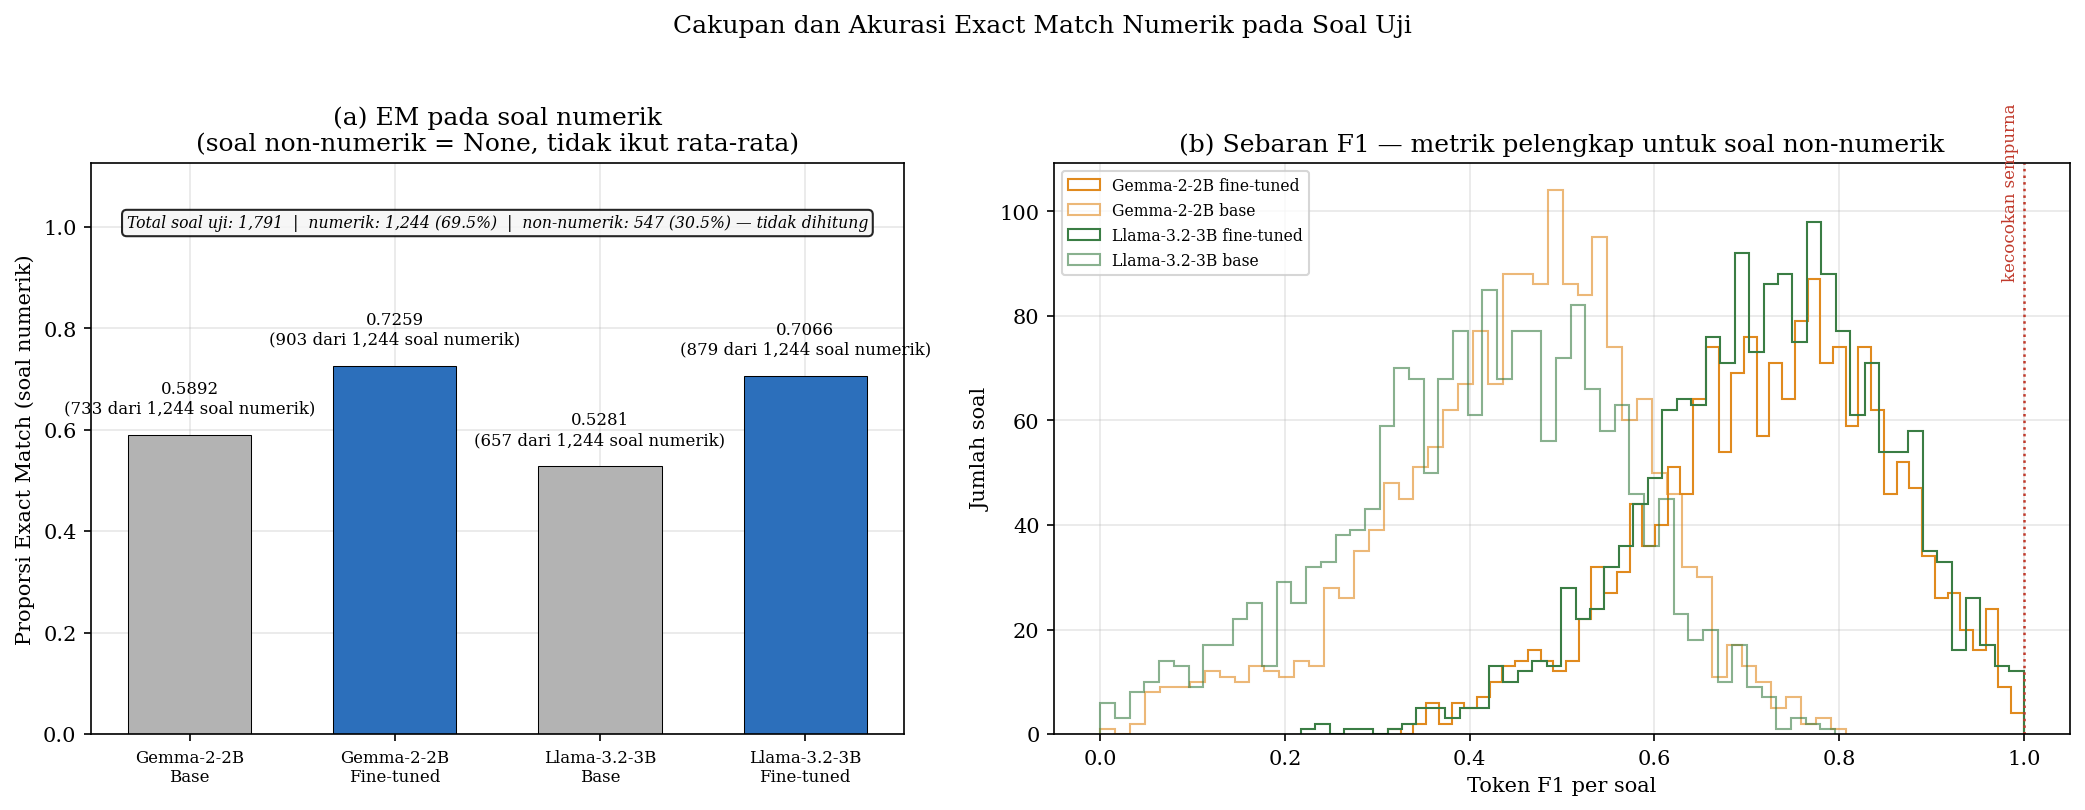

In [95]:
def fig38_keterbatasan_em():
    if not ADA_SCORED:
        lewati("Berkas *_scored.csv belum lengkap."); return
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), gridspec_kw={"width_ratios": [1, 1.25]})

    ax = axes[0]
    label = [f"{MODEL_LABELS[mk]}\n{'Base' if c == 'base' else 'Fine-tuned'}"
             for mk in MODEL_KEYS for c in CONDITIONS]
    # pandas .mean() mengabaikan NaN — hasilnya adalah EM di soal numerik saja
    nilai = [scored[(mk, c)]["em"].mean() for mk in MODEL_KEYS for c in CONDITIONS]
    n_numerik = [int(scored[(mk, c)]["em"].notna().sum()) for mk in MODEL_KEYS for c in CONDITIONS]
    n_benar = [int(scored[(mk, c)]["em"].sum()) for mk in MODEL_KEYS for c in CONDITIONS]
    ax.bar(label, nilai, color=[C_BASE, C_FT] * len(MODEL_KEYS), edgecolor="black", linewidth=.5, width=.6)
    ymax = max((v for v in nilai if pd.notna(v) and v > 0), default=.01)
    for i, (v, n_n, n_b) in enumerate(zip(nilai, n_numerik, n_benar)):
        ax.text(i, v + ymax * .06, f"{v:.4f}\n({n_b} dari {n_n:,} soal numerik)",
                ha="center", fontsize=8)
    ax.set_ylabel("Proporsi Exact Match (soal numerik)"); ax.tick_params(axis="x", labelsize=8)
    ax.set_ylim(0, ymax * 1.55)
    n_num0 = n_numerik[0]
    ax.text(0.5, 0.91,
            f"Total soal uji: {N_TEST:,}  |  numerik: {n_num0:,} ({100*n_num0/N_TEST:.1f}%)  |  "
            f"non-numerik: {N_TEST - n_num0:,} ({100*(N_TEST - n_num0)/N_TEST:.1f}%) — tidak dihitung",
            transform=ax.transAxes, ha="center", va="top", fontsize=7.5, style="italic",
            bbox=dict(boxstyle="round,pad=.3", facecolor="#f5f5f5", alpha=.85))
    ax.set_title("(a) EM pada soal numerik\n(soal non-numerik = None, tidak ikut rata-rata)")

    ax = axes[1]
    for mk, warna in [("gemma2", C_GEMMA), ("llama3.2", C_LLAMA)]:
        d = scored[(mk, "finetuned")]
        ax.hist(d["f1"], bins=50, histtype="step", lw=1.8, color=warna,
                label=f"{MODEL_LABELS[mk]} fine-tuned")
        d2 = scored[(mk, "base")]
        ax.hist(d2["f1"], bins=50, histtype="step", lw=1.3, ls="--", color=warna, alpha=.6,
                label=f"{MODEL_LABELS[mk]} base")
    ax.axvline(1.0, color=C_DROP, lw=1.2, ls=":")
    ax.text(.995, ax.get_ylim()[1] * .8, "kecocokan sempurna", rotation=90,
            ha="right", fontsize=8, color=C_DROP)
    ax.set_xlabel("Token F1 per soal"); ax.set_ylabel("Jumlah soal")
    ax.set_title("(b) Sebaran F1 — metrik pelengkap untuk soal non-numerik"); ax.legend(fontsize=7.5)

    fig.suptitle("Cakupan dan Akurasi Exact Match Numerik pada Soal Uji", y=1.03)
    plt.tight_layout(); plt.savefig("fig38_keterbatasan_em.png", bbox_inches="tight"); plt.show()

fig38_keterbatasan_em()

### Gambar 39 — Hubungan antar-metrik: kesamaan leksikal versus kesamaan semantik

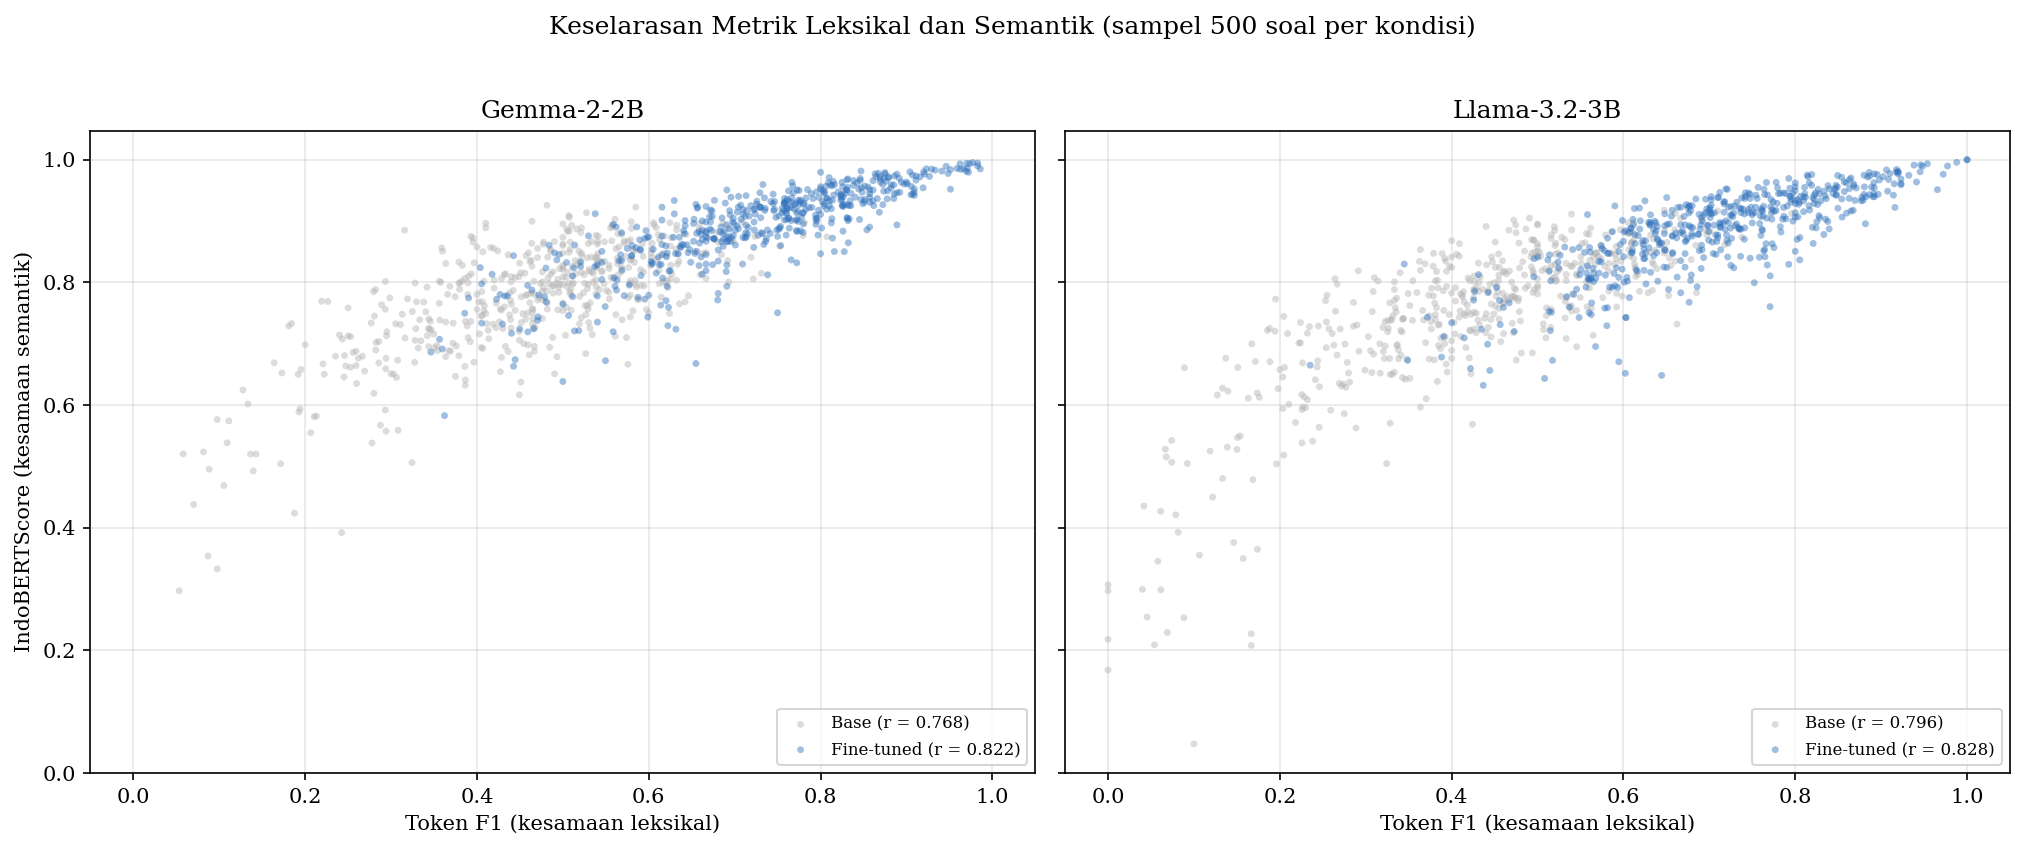

In [96]:
def fig39_hubungan_metrik():
    if not ADA_SCORED:
        lewati("Berkas *_scored.csv belum lengkap."); return
    fig, axes = plt.subplots(1, len(MODEL_KEYS), figsize=(6.8 * len(MODEL_KEYS), 5.5),
                             sharex=True, sharey=True)
    rng = np.random.default_rng(42)
    for ax, mk in zip(axes, MODEL_KEYS):
        for cond, warna in [("base", C_BASE), ("finetuned", C_FT)]:
            d = scored[(mk, cond)]
            idx = rng.choice(len(d), size=min(len(d), 500), replace=False)
            r = np.corrcoef(d["f1"], d["indobertscore"])[0, 1]
            ax.scatter(d["f1"].values[idx], d["indobertscore"].values[idx], s=11, alpha=.45,
                       color=warna, edgecolor="none",
                       label=f"{'Base' if cond == 'base' else 'Fine-tuned'} (r = {r:.3f})")
        ax.set_xlabel("Token F1 (kesamaan leksikal)")
        ax.set_title(MODEL_LABELS[mk]); ax.legend(fontsize=8, loc="lower right")
    axes[0].set_ylabel("IndoBERTScore (kesamaan semantik)")
    fig.suptitle("Keselarasan Metrik Leksikal dan Semantik (sampel 500 soal per kondisi)", y=1.02)
    plt.tight_layout(); plt.savefig("fig39_hubungan_metrik.png", bbox_inches="tight"); plt.show()

fig39_hubungan_metrik()

### Gambar 40 — Performa per tipe sub-tugas *(butuh `test.csv`)*
Analisis ini menunjukkan pada jenis pertanyaan mana instruction-tuning memberi manfaat terbesar dan terkecil — informasi yang hilang bila hanya melaporkan rata-rata keseluruhan.

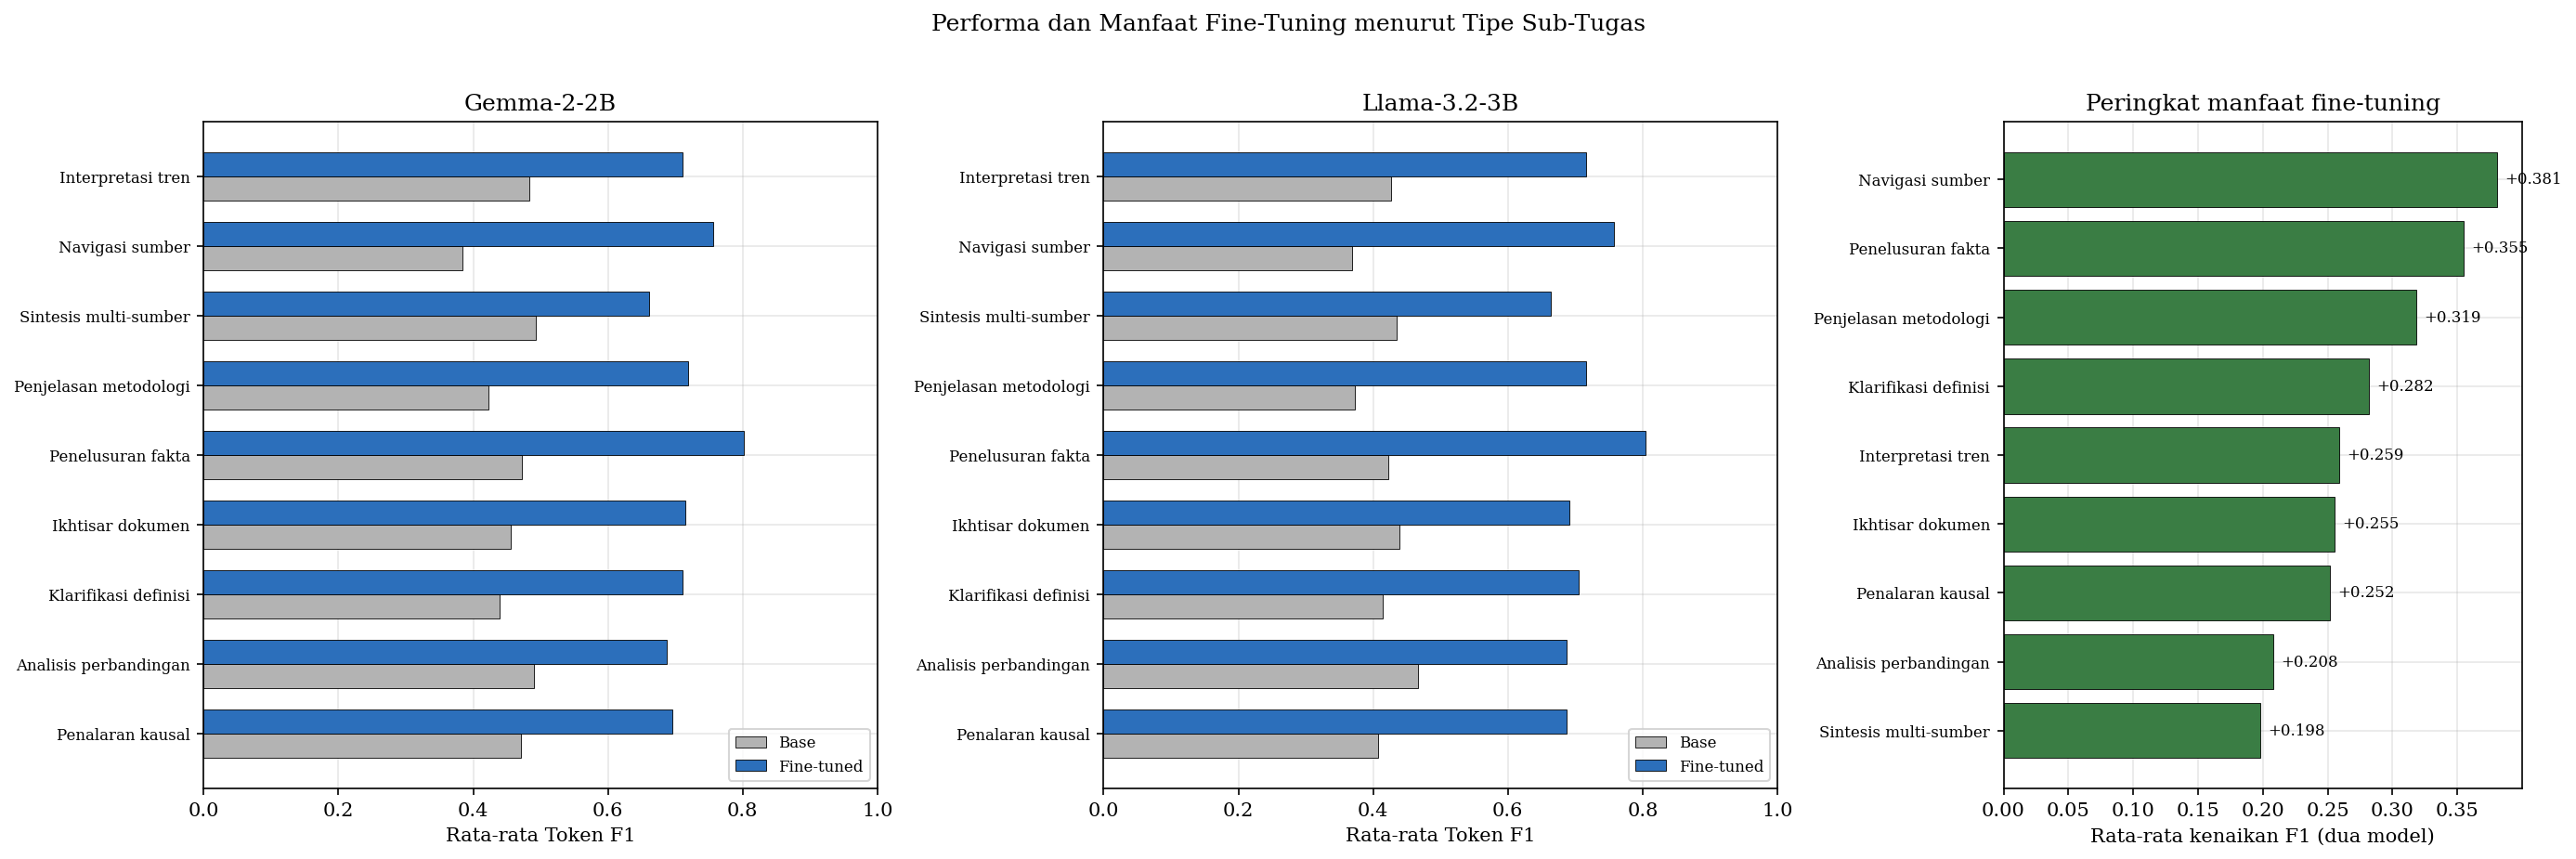

In [97]:
def fig40_performa_per_subtask():
    if not ADA_SCORED or df_test is None:
        lewati("Butuh test.csv dan berkas *_scored.csv lengkap."); return
    meta = df_test[["record_id", "subtask_type"]].drop_duplicates("record_id")
    subtask = sorted(meta["subtask_type"].dropna().unique())

    fig, axes = plt.subplots(1, len(MODEL_KEYS) + 1, figsize=(6.2 * (len(MODEL_KEYS) + 1), 6),
                             gridspec_kw={"width_ratios": [1.3] * len(MODEL_KEYS) + [1]})
    delta_semua = {}
    for ax, mk in zip(axes, MODEL_KEYS):
        base = scored[(mk, "base")].merge(meta, on="record_id").groupby("subtask_type")["f1"].mean().reindex(subtask)
        ft = scored[(mk, "finetuned")].merge(meta, on="record_id").groupby("subtask_type")["f1"].mean().reindex(subtask)
        delta_semua[mk] = ft - base
        y = np.arange(len(subtask)); w = .35
        ax.barh(y - w / 2, base, w, color=C_BASE, edgecolor="black", linewidth=.4, label="Base")
        ax.barh(y + w / 2, ft, w, color=C_FT, edgecolor="black", linewidth=.4, label="Fine-tuned")
        ax.set_yticks(y)
        ax.set_yticklabels([SUBTASK_LABEL.get(s, s) for s in subtask], fontsize=8)
        ax.set_xlabel("Rata-rata Token F1"); ax.set_xlim(0, 1)
        ax.set_title(MODEL_LABELS[mk]); ax.legend(fontsize=8, loc="lower right")

    ax = axes[-1]
    d = pd.DataFrame(delta_semua).reindex(subtask)
    d["rerata"] = d.mean(axis=1)
    d = d.sort_values("rerata")
    y = np.arange(len(d))
    ax.barh(y, d["rerata"], color=C_KEEP, edgecolor="black", linewidth=.4)
    for yi, v in zip(y, d["rerata"]):
        ax.text(v + .006, yi, f"{v:+.3f}", va="center", fontsize=8)
    ax.set_yticks(y); ax.set_yticklabels([SUBTASK_LABEL.get(s, s) for s in d.index], fontsize=8)
    ax.set_xlabel("Rata-rata kenaikan F1 (dua model)")
    ax.set_title("Peringkat manfaat fine-tuning")

    fig.suptitle("Performa dan Manfaat Fine-Tuning menurut Tipe Sub-Tugas", y=1.02)
    plt.tight_layout(); plt.savefig("fig40_performa_per_subtask.png", bbox_inches="tight"); plt.show()

fig40_performa_per_subtask()

### Gambar 41 — Perbandingan per soal: menang, seri, atau kalah

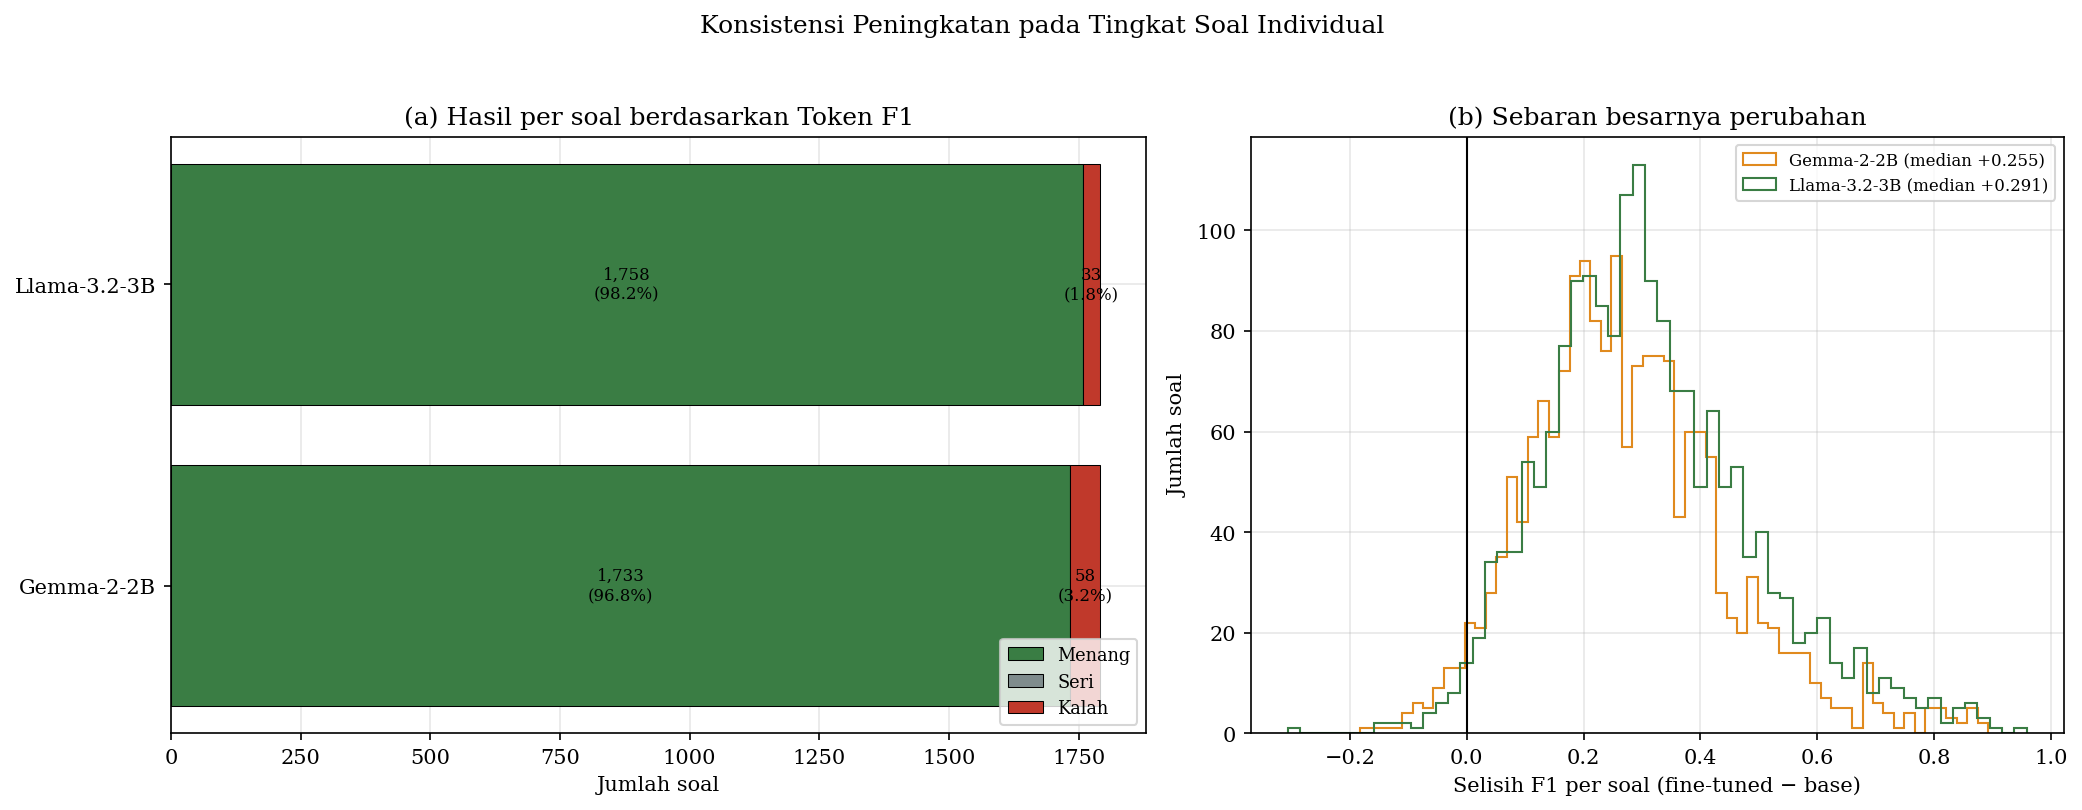

In [98]:
def fig41_menang_kalah():
    if not ADA_SCORED:
        lewati("Berkas *_scored.csv belum lengkap."); return
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), gridspec_kw={"width_ratios": [1.2, 1]})

    ax = axes[0]
    rekap = {}
    for mk in MODEL_KEYS:
        d = pasangan(mk, "f1")
        rekap[mk] = {"Menang": int((d["finetuned"] > d["base"]).sum()),
                     "Seri": int((d["finetuned"] == d["base"]).sum()),
                     "Kalah": int((d["finetuned"] < d["base"]).sum())}
    d = pd.DataFrame(rekap).T
    kiri = np.zeros(len(d))
    for kat, warna in [("Menang", C_KEEP), ("Seri", C_MUTED), ("Kalah", C_DROP)]:
        nilai = d[kat].values
        ax.barh([MODEL_LABELS[m] for m in d.index], nilai, left=kiri, color=warna,
                edgecolor="black", linewidth=.5, label=kat)
        for yi, (v, l) in enumerate(zip(nilai, kiri)):
            if v > 0:
                ax.text(l + v / 2, yi, f"{v:,}\n({100 * v / d.loc[d.index[yi]].sum():.1f}%)",
                        ha="center", va="center", fontsize=8)
        kiri += nilai
    ax.set_xlabel("Jumlah soal"); ax.set_title("(a) Hasil per soal berdasarkan Token F1")
    ax.legend(fontsize=8.5, loc="lower right")

    ax = axes[1]
    for mk, warna in [("gemma2", C_GEMMA), ("llama3.2", C_LLAMA)]:
        d = pasangan(mk, "f1")
        selisih = d["finetuned"] - d["base"]
        ax.hist(selisih, bins=60, histtype="step", lw=1.8, color=warna,
                label=f"{MODEL_LABELS[mk]} (median {selisih.median():+.3f})")
    ax.axvline(0, color="black", lw=1)
    ax.set_xlabel("Selisih F1 per soal (fine-tuned − base)"); ax.set_ylabel("Jumlah soal")
    ax.set_title("(b) Sebaran besarnya perubahan"); ax.legend(fontsize=8)

    fig.suptitle("Konsistensi Peningkatan pada Tingkat Soal Individual", y=1.03)
    plt.tight_layout(); plt.savefig("fig41_menang_kalah.png", bbox_inches="tight"); plt.show()

fig41_menang_kalah()

### Gambar 42 — Uji signifikansi statistik peningkatan
Karena skor base dan fine-tuned diukur pada soal yang sama, digunakan uji berpasangan. Normalitas selisih diperiksa dengan Shapiro-Wilk; bila tidak normal (umum terjadi pada metrik terbatas 0–1) dipakai Wilcoxon signed-rank. Ukuran efek dilaporkan dengan Cliff's delta sebagai pelengkap nilai-p yang sangat sensitif pada n besar.

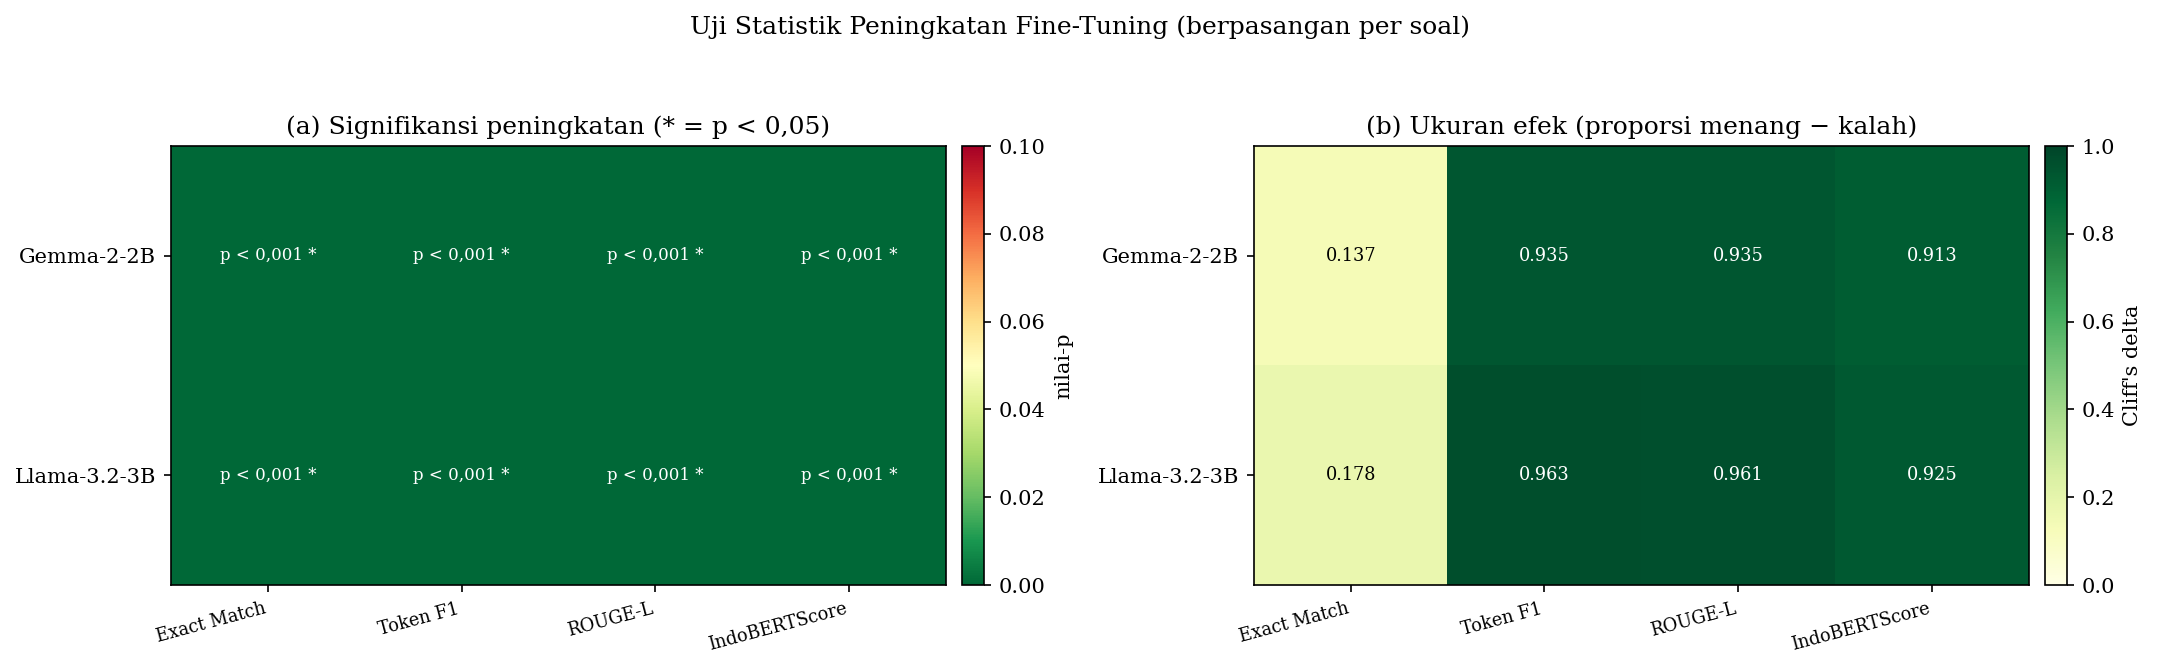

   model        metrik                  uji  rerata_base  rerata_ft  selisih  statistik       p_value  signifikan_5pct  cliffs_delta
  gemma2            em Wilcoxon signed-rank     0.589228   0.725884 0.136656    13240.0  8.111274e-21             True      0.136656
  gemma2            f1 Wilcoxon signed-rank     0.450033   0.723552 0.273519     6396.0 1.620000e-289             True      0.935232
  gemma2       rouge_l Wilcoxon signed-rank     0.370064   0.651866 0.281802     6482.0 1.868978e-289             True      0.935232
  gemma2 indobertscore Wilcoxon signed-rank     0.765094   0.891094 0.125999    16631.0 3.562932e-282             True      0.912898
llama3.2            em Wilcoxon signed-rank     0.528135   0.706592 0.178457    18427.5  2.319928e-28             True      0.178457
llama3.2            f1 Wilcoxon signed-rank     0.411047   0.721543 0.310496     3712.0 1.855193e-291             True      0.963149
llama3.2       rouge_l Wilcoxon signed-rank     0.335616   0.652464 0

In [99]:
def fig42_uji_signifikansi():
    if not ADA_SCORED:
        lewati("Berkas *_scored.csv belum lengkap."); return None

    baris = []
    for mk in MODEL_KEYS:
        for m in METRICS:
            d = pasangan(mk, m)
            selisih = (d["finetuned"] - d["base"]).to_numpy()
            if np.allclose(selisih, 0):
                uji, stat, p = "tidak dapat diuji", np.nan, np.nan
                normal = False
            else:
                sampel = selisih if len(selisih) <= 5000 else pd.Series(selisih).sample(5000, random_state=42).to_numpy()
                _, p_norm = stats.shapiro(sampel)
                normal = p_norm >= .05
                if normal:
                    stat, p = stats.ttest_rel(d["finetuned"], d["base"])
                    uji = "Paired t-test"
                else:
                    stat, p = stats.wilcoxon(selisih)
                    uji = "Wilcoxon signed-rank"
            menang = (selisih > 0).mean(); kalah = (selisih < 0).mean()
            baris.append({"model": mk, "metrik": m, "uji": uji,
                          "rerata_base": d["base"].mean(), "rerata_ft": d["finetuned"].mean(),
                          "selisih": selisih.mean(), "statistik": stat, "p_value": p,
                          "signifikan_5pct": bool(p < .05) if pd.notna(p) else False,
                          "cliffs_delta": menang - kalah})
    hasil = pd.DataFrame(baris)

    mat = hasil.pivot(index="model", columns="metrik", values="p_value").reindex(
        index=MODEL_KEYS, columns=METRICS)
    eff = hasil.pivot(index="model", columns="metrik", values="cliffs_delta").reindex(
        index=MODEL_KEYS, columns=METRICS)

    fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.2))

    ax = axes[0]
    im = ax.imshow(mat.values, cmap="RdYlGn_r", vmin=0, vmax=.1, aspect="auto")
    ax.set_xticks(range(len(METRICS))); ax.set_xticklabels([METRIC_LABELS[m] for m in METRICS],
                                                           rotation=15, ha="right", fontsize=8.5)
    ax.set_yticks(range(len(MODEL_KEYS))); ax.set_yticklabels([MODEL_LABELS[m] for m in MODEL_KEYS])
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            p = mat.values[i, j]
            if pd.isna(p):
                teks = "n/a"
            else:
                teks = ("p < 0,001" if p < .001 else f"p = {p:.3f}") + (" *" if p < .05 else "")
            gelap = pd.notna(p) and (p < .02 or p > .085)
            ax.text(j, i, teks, ha="center", va="center", fontsize=8,
                    color="white" if gelap else "black")
    fig.colorbar(im, ax=ax, fraction=.03, pad=.02).set_label("nilai-p")
    ax.set_title("(a) Signifikansi peningkatan (* = p < 0,05)")
    ax.grid(False)

    ax = axes[1]
    im = ax.imshow(eff.values, cmap="YlGn", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(METRICS))); ax.set_xticklabels([METRIC_LABELS[m] for m in METRICS],
                                                           rotation=15, ha="right", fontsize=8.5)
    ax.set_yticks(range(len(MODEL_KEYS))); ax.set_yticklabels([MODEL_LABELS[m] for m in MODEL_KEYS])
    for i in range(eff.shape[0]):
        for j in range(eff.shape[1]):
            v = eff.values[i, j]
            ax.text(j, i, f"{v:.3f}", ha="center", va="center", fontsize=8.5,
                    color="white" if v > .55 else "black")
    fig.colorbar(im, ax=ax, fraction=.03, pad=.02).set_label("Cliff's delta")
    ax.set_title("(b) Ukuran efek (proporsi menang − kalah)")
    ax.grid(False)

    fig.suptitle("Uji Statistik Peningkatan Fine-Tuning (berpasangan per soal)", y=1.05)
    plt.tight_layout(); plt.savefig("fig42_uji_signifikansi.png", bbox_inches="tight"); plt.show()

    print(hasil.to_string(index=False))
    return hasil

hasil_uji = fig42_uji_signifikansi()

---
# Bagian 6 — Evaluasi Manusia
Sumber: `tujuan2/[3] evaluation/12-prepare-human-evaluation.ipynb`. Lima evaluator menilai sampel jawaban secara buta (tanpa mengetahui model maupun kondisi) pada skala Likert 1–5 untuk tiga kriteria, ditambah penanda bila jawaban referensi sendiri dicurigai keliru. Bagian ini hanya dapat dijalankan setelah berkas isian evaluator tersedia.

In [100]:
HUMAN_CRITERIA = ["fluency", "factual_correctness", "completeness"]
HUMAN_LABELS = {"fluency": "Kelancaran bahasa", "factual_correctness": "Ketepatan faktual",
                "completeness": "Kelengkapan"}

def muat_evaluasi_manusia():
    berkas = [f"human_eval_evaluator{i}.csv" for i in range(1, 6)] + ["human_eval_key.csv"]
    if not ada(*berkas):
        return None
    frames = []
    for i in range(1, 6):
        d = pd.read_csv(f"human_eval_evaluator{i}.csv")
        d["evaluator_id"] = i
        frames.append(d)
    semua = pd.concat(frames, ignore_index=True)
    kurang = [c for c in HUMAN_CRITERIA if c not in semua.columns]
    if kurang:
        print(f"[PERINGATAN] kolom penilaian belum ada: {kurang}")
        return None
    belum = semua[HUMAN_CRITERIA].isna().any(axis=1).sum()
    if belum:
        print(f"[PERINGATAN] {belum} baris belum dinilai dan dikeluarkan dari analisis.")
        semua = semua.dropna(subset=HUMAN_CRITERIA)
    kunci = pd.read_csv("human_eval_key.csv")
    return semua.merge(kunci, on="eval_id", how="left")

df_human = muat_evaluasi_manusia()
if df_human is None:
    lewati("Berkas evaluasi manusia belum lengkap — Bagian 6 akan dilewati.")
else:
    print(f"Penilaian manusia termuat: {len(df_human):,} baris dari "
          f"{df_human['evaluator_id'].nunique()} evaluator")

[DILEWATI] Berkas evaluasi manusia belum lengkap — Bagian 6 akan dilewati.


### Gambar 43 — Skor evaluasi manusia per kriteria

In [101]:
def fig43_skor_manusia():
    if df_human is None:
        lewati("Data evaluasi manusia belum tersedia."); return
    fig, axes = plt.subplots(1, len(MODEL_KEYS), figsize=(6.8 * len(MODEL_KEYS), 5.2), sharey=True)
    x = np.arange(len(HUMAN_CRITERIA)); w = .35
    for ax, mk in zip(axes, MODEL_KEYS):
        sub = df_human[df_human["_model_key"] == mk]
        base = [sub[sub["_condition"] == "base"][c].mean() for c in HUMAN_CRITERIA]
        ft = [sub[sub["_condition"] == "finetuned"][c].mean() for c in HUMAN_CRITERIA]
        sd_base = [sub[sub["_condition"] == "base"][c].std() for c in HUMAN_CRITERIA]
        sd_ft = [sub[sub["_condition"] == "finetuned"][c].std() for c in HUMAN_CRITERIA]
        ax.bar(x - w / 2, base, w, yerr=sd_base, capsize=3, color=C_BASE,
               edgecolor="black", linewidth=.5, label="Base")
        ax.bar(x + w / 2, ft, w, yerr=sd_ft, capsize=3, color=C_FT,
               edgecolor="black", linewidth=.5, label="Fine-tuned")
        for xi, v in zip(x - w / 2, base): ax.text(xi, v + .12, f"{v:.2f}", ha="center", fontsize=8)
        for xi, v in zip(x + w / 2, ft): ax.text(xi, v + .12, f"{v:.2f}", ha="center", fontsize=8)
        ax.set_xticks(x); ax.set_xticklabels([HUMAN_LABELS[c] for c in HUMAN_CRITERIA],
                                             rotation=12, ha="right")
        ax.set_title(MODEL_LABELS[mk]); ax.set_ylim(0, 5.8)
    axes[0].set_ylabel("Skor Likert rata-rata (1–5)"); axes[-1].legend(fontsize=8.5)
    fig.suptitle("Penilaian Manusia terhadap Kualitas Jawaban (galat = simpangan baku)", y=1.02)
    plt.tight_layout(); plt.savefig("fig43_skor_manusia.png", bbox_inches="tight"); plt.show()

fig43_skor_manusia()

[DILEWATI] Data evaluasi manusia belum tersedia.


### Gambar 44 — Sebaran skor Likert dan uji beda evaluasi manusia

In [102]:
def fig44_sebaran_likert():
    if df_human is None:
        lewati("Data evaluasi manusia belum tersedia."); return
    fig, axes = plt.subplots(len(MODEL_KEYS), len(HUMAN_CRITERIA),
                             figsize=(4.6 * len(HUMAN_CRITERIA), 3.8 * len(MODEL_KEYS)),
                             sharey=True, squeeze=False)
    for i, mk in enumerate(MODEL_KEYS):
        sub = df_human[df_human["_model_key"] == mk]
        for j, crit in enumerate(HUMAN_CRITERIA):
            ax = axes[i][j]
            x = np.arange(1, 6); w = .38
            for k, (cond, warna) in enumerate([("base", C_BASE), ("finetuned", C_FT)]):
                prop = (sub[sub["_condition"] == cond][crit]
                        .value_counts(normalize=True).reindex(x, fill_value=0))
                ax.bar(x + (k - .5) * w, 100 * prop.values, w, color=warna,
                       edgecolor="black", linewidth=.4,
                       label="Base" if cond == "base" else "Fine-tuned")
            g1 = sub[sub["_condition"] == "finetuned"][crit]
            g2 = sub[sub["_condition"] == "base"][crit]
            if len(g1) > 0 and len(g2) > 0:
                _, p = stats.mannwhitneyu(g1, g2, alternative="two-sided")
                tanda = "signifikan" if p < .05 else "tidak signifikan"
                ax.text(.97, .93, f"Mann-Whitney p = {p:.4g}\n({tanda})", transform=ax.transAxes,
                        ha="right", va="top", fontsize=7.5,
                        bbox=dict(boxstyle="round,pad=.3", facecolor="white", alpha=.85))
            ax.set_xticks(x); ax.set_xlabel("Skor Likert")
            ax.set_title(f"{MODEL_LABELS[mk]} — {HUMAN_LABELS[crit]}", fontsize=9)
            if i == 0 and j == len(HUMAN_CRITERIA) - 1:
                ax.legend(fontsize=7.5)
    for i in range(len(MODEL_KEYS)):
        axes[i][0].set_ylabel("Persentase penilaian (%)")
    fig.suptitle("Sebaran Penilaian Manusia per Kriteria (uji dua kelompok independen)", y=1.01)
    plt.tight_layout(); plt.savefig("fig44_sebaran_likert.png", bbox_inches="tight"); plt.show()

fig44_sebaran_likert()

[DILEWATI] Data evaluasi manusia belum tersedia.


### Gambar 45 — Konsistensi antar-evaluator dan keraguan atas jawaban referensi
Panel (a) membandingkan kecenderungan penilaian tiap evaluator sebagai pemeriksaan kalibrasi. Panel (b) melaporkan seberapa sering evaluator justru meragukan jawaban referensi — umpan balik langsung atas kualitas dataset hasil generasi LLM.

In [103]:
def fig45_konsistensi_evaluator():
    if df_human is None:
        lewati("Data evaluasi manusia belum tersedia."); return
    fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.2), gridspec_kw={"width_ratios": [1.3, 1]})

    ax = axes[0]
    x = np.arange(df_human["evaluator_id"].nunique()); w = .26
    evaluator = sorted(df_human["evaluator_id"].unique())
    for i, (crit, warna) in enumerate(zip(HUMAN_CRITERIA, [C_CLEAN, C_ACCENT, C_KEEP])):
        rerata = [df_human[df_human["evaluator_id"] == e][crit].mean() for e in evaluator]
        ax.bar(x + (i - 1) * w, rerata, w, color=warna, edgecolor="black",
               linewidth=.4, label=HUMAN_LABELS[crit])
    ax.set_xticks(x); ax.set_xticklabels([f"Evaluator {e}" for e in evaluator], fontsize=8.5)
    ax.set_ylabel("Skor Likert rata-rata"); ax.set_ylim(0, 5.5)
    ax.set_title("(a) Kecenderungan penilaian tiap evaluator"); ax.legend(fontsize=8)

    ax = axes[1]
    if "ans_ref_meragukan" not in df_human.columns:
        ax.axis("off"); ax.set_title("(b) Kolom ans_ref_meragukan tidak tersedia")
    else:
        label = [f"{MODEL_LABELS[mk]}\n{'Base' if c == 'base' else 'Fine-tuned'}"
                 for mk in MODEL_KEYS for c in CONDITIONS]
        nilai = []
        for mk in MODEL_KEYS:
            for c in CONDITIONS:
                sub = df_human[(df_human["_model_key"] == mk) & (df_human["_condition"] == c)]
                nilai.append(100 * pd.to_numeric(sub["ans_ref_meragukan"], errors="coerce").mean())
        ax.bar(label, nilai, color=[C_BASE, C_FT] * len(MODEL_KEYS),
               edgecolor="black", linewidth=.5, width=.6)
        for i, v in enumerate(nilai):
            if pd.notna(v):
                ax.text(i, v + .4, f"{v:.1f}%", ha="center", fontsize=9)
        ax.set_ylabel("Persentase item (%)"); ax.tick_params(axis="x", labelsize=8)
        ax.set_title("(b) Jawaban referensi yang diragukan evaluator")

    fig.suptitle("Kalibrasi Evaluator dan Umpan Balik atas Kualitas Dataset", y=1.03)
    plt.tight_layout(); plt.savefig("fig45_konsistensi_evaluator.png", bbox_inches="tight"); plt.show()

fig45_konsistensi_evaluator()

[DILEWATI] Data evaluasi manusia belum tersedia.


---
# Bagian 7 — Sintesis Akhir Tujuan 2
Menggabungkan seluruh bukti: metrik otomatis, signifikansi statistik, dan penilaian manusia, ke dalam satu tabel dan satu grafik ringkas.

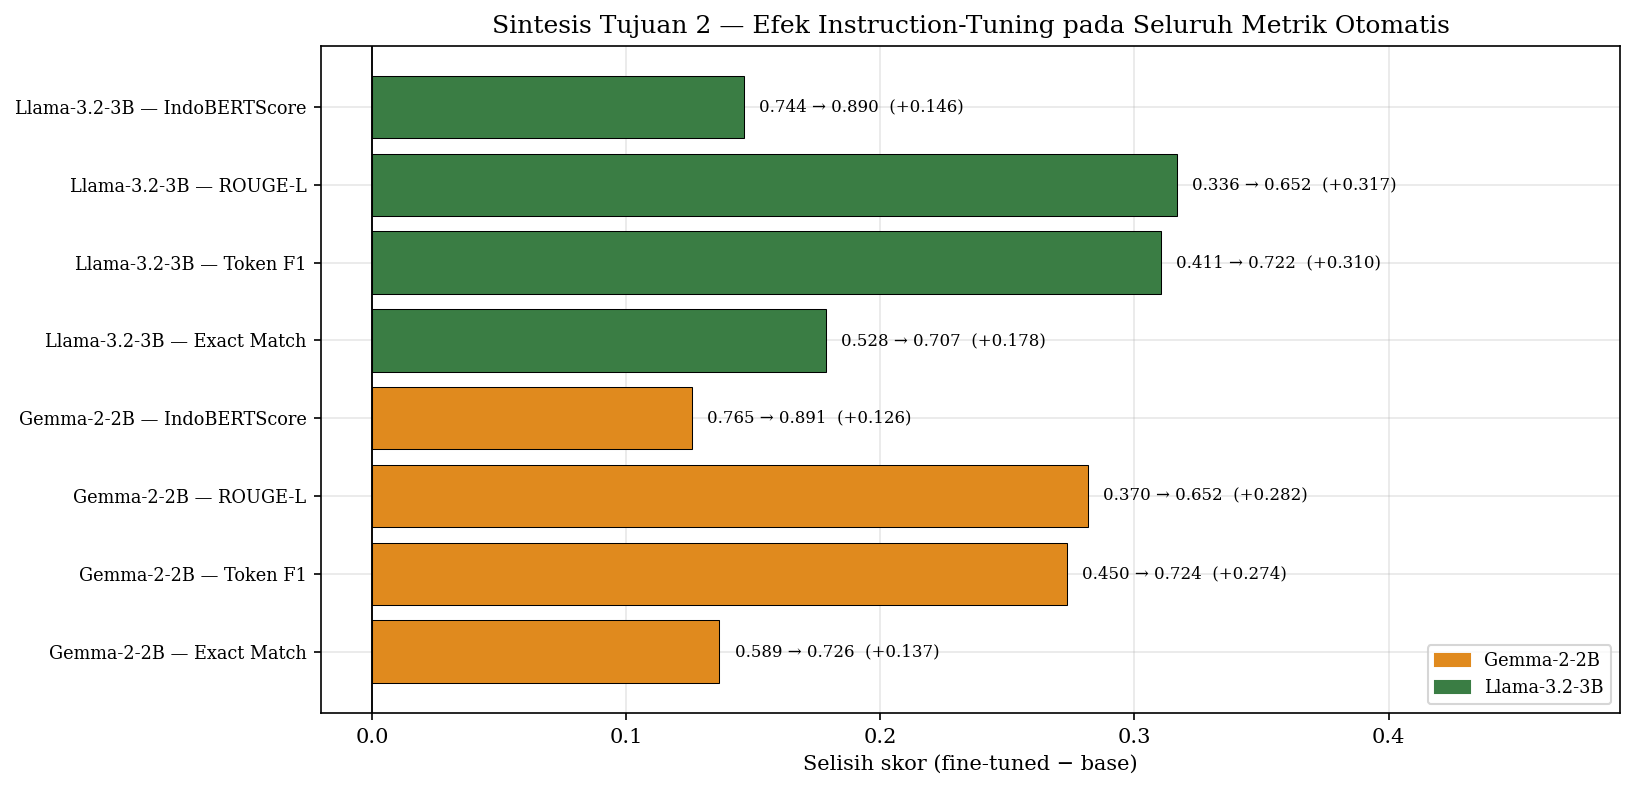

       Model         Aspek   Sumber   Base  Fine-tuned  Selisih Signifikansi
  Gemma-2-2B   Exact Match Otomatis 0.5892      0.7259   0.1367    p < 0,001
  Gemma-2-2B      Token F1 Otomatis 0.4500      0.7236   0.2735    p < 0,001
  Gemma-2-2B       ROUGE-L Otomatis 0.3701      0.6519   0.2818    p < 0,001
  Gemma-2-2B IndoBERTScore Otomatis 0.7651      0.8911   0.1260    p < 0,001
Llama-3.2-3B   Exact Match Otomatis 0.5281      0.7066   0.1785    p < 0,001
Llama-3.2-3B      Token F1 Otomatis 0.4110      0.7215   0.3105    p < 0,001
Llama-3.2-3B       ROUGE-L Otomatis 0.3356      0.6525   0.3168    p < 0,001
Llama-3.2-3B IndoBERTScore Otomatis 0.7435      0.8899   0.1464    p < 0,001

Tabel sintesis disimpan: tabel_sintesis_tujuan2.csv


In [104]:
def fig46_sintesis_akhir():
    if summary is None:
        lewati("summary_metrics.csv tidak tersedia."); return None

    baris = []
    for mk in MODEL_KEYS:
        for m in METRICS:
            b = summary.loc[f"{mk}_base", m]
            f_ = summary.loc[f"{mk}_finetuned", m]
            info = {"Model": MODEL_LABELS[mk], "Aspek": METRIC_LABELS[m], "Sumber": "Otomatis",
                    "Base": round(b, 4), "Fine-tuned": round(f_, 4), "Selisih": round(f_ - b, 4)}
            if hasil_uji is not None:
                r = hasil_uji.query("model == @mk and metrik == @m")
                if len(r):
                    p = r["p_value"].iloc[0]
                    info["Signifikansi"] = ("p < 0,001" if p < .001 else f"p = {p:.4f}") if pd.notna(p) else "n/a"
            baris.append(info)
    if df_human is not None:
        for mk in MODEL_KEYS:
            sub = df_human[df_human["_model_key"] == mk]
            for c in HUMAN_CRITERIA:
                g1 = sub[sub["_condition"] == "finetuned"][c]
                g2 = sub[sub["_condition"] == "base"][c]
                p = stats.mannwhitneyu(g1, g2, alternative="two-sided")[1] if len(g1) and len(g2) else np.nan
                baris.append({"Model": MODEL_LABELS[mk], "Aspek": HUMAN_LABELS[c], "Sumber": "Manusia",
                              "Base": round(g2.mean(), 3), "Fine-tuned": round(g1.mean(), 3),
                              "Selisih": round(g1.mean() - g2.mean(), 3),
                              "Signifikansi": ("p < 0,001" if p < .001 else f"p = {p:.4f}") if pd.notna(p) else "n/a"})
    tabel = pd.DataFrame(baris)

    otomatis = tabel[tabel["Sumber"] == "Otomatis"]
    fig, ax = plt.subplots(figsize=(11, .42 * len(otomatis) + 2))
    y = np.arange(len(otomatis))
    warna = [C_GEMMA if m == MODEL_LABELS["gemma2"] else C_LLAMA for m in otomatis["Model"]]
    ax.barh(y, otomatis["Selisih"], color=warna, edgecolor="black", linewidth=.5)
    for yi, (v, b, f_) in enumerate(zip(otomatis["Selisih"], otomatis["Base"], otomatis["Fine-tuned"])):
        ax.text(v + .006, yi, f"{b:.3f} → {f_:.3f}  ({v:+.3f})", va="center", fontsize=8)
    ax.set_yticks(y); ax.set_yticklabels([f"{m} — {a}" for m, a in zip(otomatis["Model"], otomatis["Aspek"])],
                                         fontsize=8.5)
    ax.axvline(0, color="black", lw=.9)
    ax.set_xlim(-.02, max(otomatis["Selisih"]) * 1.55)
    ax.set_xlabel("Selisih skor (fine-tuned − base)")
    ax.set_title("Sintesis Tujuan 2 — Efek Instruction-Tuning pada Seluruh Metrik Otomatis")
    ax.legend(handles=[Patch(color=C_GEMMA, label=MODEL_LABELS["gemma2"]),
                       Patch(color=C_LLAMA, label=MODEL_LABELS["llama3.2"])],
              fontsize=8.5, loc="lower right")
    plt.tight_layout(); plt.savefig("fig46_sintesis_akhir.png", bbox_inches="tight"); plt.show()

    print(tabel.to_string(index=False))
    tabel.to_csv("tabel_sintesis_tujuan2.csv", index=False)
    print("\nTabel sintesis disimpan: tabel_sintesis_tujuan2.csv")
    return tabel

tabel_sintesis = fig46_sintesis_akhir()

## Catatan keterbatasan yang perlu ditulis di naskah

1. **Cakupan korpus tidak penuh.** Generasi QA berhenti pada 29 dari 47 dokumen karena kuota API generator habis, sehingga dataset tidak merepresentasikan seluruh korpus.
2. **Ketimpangan kontribusi dokumen.** Lima dokumen menyumbang porsi record yang jauh lebih besar daripada sisanya, berpotensi membiaskan model ke gaya penulisan dokumen tersebut.
3. **Konteks bersifat oracle.** Seluruh record dilatih dengan konteks yang sudah pasti relevan, tanpa dokumen pengecoh, sehingga performa pada skenario penelusuran nyata belum teruji di Tujuan 2.
4. **Exact Match hanya berlaku pada soal numerik** — soal yang referensinya tidak mengandung bilangan dikembalikan `None`. EM yang dilaporkan adalah rata-rata pada subset numerik saja; kesimpulan utama tetap bertumpu pada F1, ROUGE-L, dan IndoBERTScore.
5. **Referensi jawaban buatan LLM.** Metrik otomatis mengukur kemiripan terhadap jawaban yang juga dihasilkan LLM, sehingga evaluasi manusia menjadi penyeimbang yang penting.
6. **Perbandingan waktu inferensi antar-model tidak setara** karena jumlah GPU yang dipakai berbeda (Gemma-2 dua GPU, Llama-3.2 satu GPU).
7. **Resolusi kurva loss** terbatas pada pencatatan tiap 50 langkah karena log per-10-langkah tidak tersimpan ke berkas yang diunggah.